<a href="https://colab.research.google.com/github/saharz1/Ship-Fault-Prediction/blob/main/Ship_Fault_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# איחוד בין כל העבודות לפי מסעות כולל LEG



In [ ]:
import pandas as pd

# Load the Excel file
file_path = '/content/JobHistory + Vessel Logs Report 2022-24 Data Clean.xlsx'  # החלף בשם הקובץ אם שונה
xls = pd.ExcelFile(file_path)

# Load the sheets into DataFrames
vessel_logs_df = pd.read_excel(xls, sheet_name="Vessel Logs")
job_history_df = pd.read_excel(xls, sheet_name="Job History")

# Convert dates to datetime format
vessel_logs_df['LOG DATE LOCAL'] = pd.to_datetime(vessel_logs_df['LOG DATE LOCAL'], errors='coerce')
job_history_df['Job Start Date'] = pd.to_datetime(job_history_df['Job Start Date'], errors='coerce')
job_history_df['Job End Date'] = pd.to_datetime(job_history_df['Job End Date'], errors='coerce')

# Group Vessel Logs by VOYAGE LEG NUMBER to calculate start and end dates
voyage_dates = vessel_logs_df.groupby('VOYAGE LEG NUMBER').agg({
    'LOG DATE LOCAL': ['min', 'max'],  # Start and end date for each LEG
    'Vessel Name': 'first'             # Vessel name for each LEG
}).reset_index()
voyage_dates.columns = ['VOYAGE LEG NUMBER', 'Voyage Start Date', 'Voyage End Date', 'Vessel Name']

# Merge voyage dates into the original Vessel Logs DataFrame
vessel_logs_df = vessel_logs_df.merge(voyage_dates, on=['VOYAGE LEG NUMBER', 'Vessel Name'], how='left')

# Create an empty list to store the combined data
combined_data = []

# Iterate over each row in Job History
for _, job_row in job_history_df.iterrows():
    # Filter Vessel Logs based on vessel name and date range
    matching_voyages = vessel_logs_df[
        (vessel_logs_df['Vessel Name'] == job_row['Vessel Name']) &
        (vessel_logs_df['Voyage Start Date'] <= job_row['Job End Date']) &
        (vessel_logs_df['Voyage End Date'] >= job_row['Job Start Date'])
    ]

    # For each matching voyage, combine the job and log data
    for _, voyage_row in matching_voyages.iterrows():
        combined_row = {**job_row.to_dict(), **voyage_row.to_dict()}
        combined_data.append(combined_row)

# Convert the combined data into a DataFrame
combined_df = pd.DataFrame(combined_data)

# Save the result to a new Excel file
output_path = 'Integrated_Vessel_Logs_and_Job_History.xlsx'
combined_df.to_excel(output_path, index=False)

print(f"The integrated file has been saved to {output_path}")


The integrated file has been saved to Integrated_Vessel_Logs_and_Job_History.xlsx


In [ ]:
import pandas as pd

# Load the Excel file
file_path = '/content/Small Data Test.xlsx'  # עדכן את הנתיב לקובץ שלך
xls = pd.ExcelFile(file_path)

# Load the sheets into DataFrames
vessel_logs_df = pd.read_excel(xls, sheet_name="Vessel Log Report")
job_history_df = pd.read_excel(xls, sheet_name="Job History")

# Convert dates to datetime format
vessel_logs_df['LOG DATE LOCAL'] = pd.to_datetime(vessel_logs_df['LOG DATE LOCAL'], errors='coerce')
job_history_df['Job Start Date'] = pd.to_datetime(job_history_df['Job Start Date'], errors='coerce')

# Create an empty list to store the combined data
combined_data = []

# Iterate over each LEG in Vessel Logs
for _, leg_row in vessel_logs_df.iterrows():
    # Filter Job History for jobs that match the LEG
    matching_jobs = job_history_df[
        (job_history_df['Vessel Name'].str.strip().str.upper() == leg_row['VESSEL NAME'].strip().upper()) &
        (job_history_df['Job Start Date'] == leg_row['LOG DATE LOCAL'])
    ]

    # If there are matching jobs, create a row for each job
    if not matching_jobs.empty:
        for _, job_row in matching_jobs.iterrows():
            combined_row = {**leg_row.to_dict(), **job_row.to_dict()}
            combined_data.append(combined_row)
    else:
        # If no jobs match, include the LEG with empty job fields
        empty_job = {col: None for col in job_history_df.columns}  # Create empty job columns
        combined_row = {**leg_row.to_dict(), **empty_job}
        combined_data.append(combined_row)

# Iterate over each job in Job History to ensure all jobs are included
for _, job_row in job_history_df.iterrows():
    # Check if the job is already included in combined_data
    if not any(d.get('Job Order No') == job_row['Job Order No'] for d in combined_data):
        empty_leg = {col: None for col in vessel_logs_df.columns}  # Create empty LEG columns
        combined_row = {**empty_leg, **job_row.to_dict()}
        combined_data.append(combined_row)

# Convert the combined data into a DataFrame
final_df = pd.DataFrame(combined_data)

# Sort the rows by VOYAGE LEG NUMBER and LOG DATE LOCAL
final_df = final_df.sort_values(by=['VOYAGE LEG NUMBER', 'LOG DATE LOCAL'], na_position='last').reset_index(drop=True)

# Save the result to a new Excel file
output_path = 'Complete_Integrated_Legs_With_Jobs.xlsx'
final_df.to_excel(output_path, index=False)

print(f"The processed file has been saved to {output_path}")


The processed file has been saved to Complete_Integrated_Legs_With_Jobs.xlsx


In [ ]:
import pandas as pd

# Load the Excel file
file_path = '/content/Small Test.xlsx'  # עדכן את הנתיב לקובץ שלך
xls = pd.ExcelFile(file_path)

# Load the sheets into DataFrames
vessel_logs_df = pd.read_excel(xls, sheet_name="Vessel Log Report")
job_history_df = pd.read_excel(xls, sheet_name="Job History")

# Convert dates to datetime format and normalize to date only (drop time component)
vessel_logs_df['LOG DATE LOCAL'] = pd.to_datetime(vessel_logs_df['LOG DATE LOCAL'], errors='coerce').dt.date
job_history_df['Job Start Date'] = pd.to_datetime(job_history_df['Job Start Date'], errors='coerce').dt.date

# Create an empty list to store the combined data
combined_data = []

# Iterate over each LEG in Vessel Logs
for _, leg_row in vessel_logs_df.iterrows():
    # Filter Job History for jobs that match the LEG
    matching_jobs = job_history_df[
        (job_history_df['Vessel Name'].str.strip().str.upper() == leg_row['VESSEL NAME'].strip().upper()) &
        (job_history_df['Job Start Date'] == leg_row['LOG DATE LOCAL'])
    ]

    # If there are matching jobs, create a row for each job
    if not matching_jobs.empty:
        for _, job_row in matching_jobs.iterrows():
            combined_row = {**leg_row.to_dict(), **job_row.to_dict()}
            combined_data.append(combined_row)
    else:
        # If no jobs match, include the LEG with empty job fields
        empty_job = {col: None for col in job_history_df.columns}  # Create empty job columns
        combined_row = {**leg_row.to_dict(), **empty_job}
        combined_data.append(combined_row)

# Iterate over each job in Job History to ensure all jobs are included
for _, job_row in job_history_df.iterrows():
    # Check if the job is already included in combined_data
    if not any(d.get('Job Order No') == job_row['Job Order No'] for d in combined_data):
        empty_leg = {col: None for col in vessel_logs_df.columns}  # Create empty LEG columns
        combined_row = {**empty_leg, **job_row.to_dict()}
        combined_data.append(combined_row)

# Convert the combined data into a DataFrame
final_df = pd.DataFrame(combined_data)

# Sort the rows by VOYAGE LEG NUMBER and LOG DATE LOCAL
final_df = final_df.sort_values(by=['VOYAGE LEG NUMBER', 'LOG DATE LOCAL'], na_position='last').reset_index(drop=True)

# Save the result to a new Excel file
output_path = 'DATA A FUCKING FINALLY.xlsx'
final_df.to_excel(output_path, index=False)

print(f"The processed file has been saved to {output_path}")


The processed file has been saved to DATA A FUCKING FINALLY.xlsx


In [ ]:
import pandas as pd

# Load the Excel file
file_path = '/content/JobHistory + Vessel Logs Report 2022-24 Data Clean.xlsx'  # Adjust the file path
xls = pd.ExcelFile(file_path)

# Load the sheets into DataFrames
vessel_logs_df = pd.read_excel(xls, sheet_name="Vessel Log Report")
job_history_df = pd.read_excel(xls, sheet_name="Job History")

# Convert dates to datetime format and normalize to date only (drop time component)
vessel_logs_df['LOG DATE LOCAL'] = pd.to_datetime(vessel_logs_df['LOG DATE LOCAL'], errors='coerce').dt.date
job_history_df['Job Start Date'] = pd.to_datetime(job_history_df['Job Start Date'], errors='coerce').dt.date

# Normalize vessel names for consistent comparison
vessel_logs_df['VESSEL NAME'] = vessel_logs_df['VESSEL NAME'].str.strip().str.upper()
job_history_df['Vessel Name'] = job_history_df['Vessel Name'].str.strip().str.upper()

# Perform the merge based on vessel name and date
merged_df = pd.merge(
    vessel_logs_df,
    job_history_df,
    left_on=['VESSEL NAME', 'LOG DATE LOCAL'],
    right_on=['Vessel Name', 'Job Start Date'],
    how='outer',  # Keep all records from both DataFrames
)

# Sort the rows by VOYAGE LEG NUMBER and LOG DATE LOCAL
merged_df = merged_df.sort_values(by=['VOYAGE LEG NUMBER', 'LOG DATE LOCAL'], na_position='last').reset_index(drop=True)

# Save the result to a new Excel file
output_path = 'DATA_A_FINALLY_MERGED.xlsx'
merged_df.to_excel(output_path, index=False)

print(f"The processed file has been saved to {output_path}")


KeyboardInterrupt: 

In [ ]:
import pandas as pd

# Load the Excel file
file_path = '/content/Job History + Vessel Logs Report 2022-2024 XTI ALB.xlsx'  # עדכן את הנתיב
xls = pd.ExcelFile(file_path)

# Load the sheets into DataFrames
vessel_logs_df = pd.read_excel(xls, sheet_name="Vessel Log Report")
job_history_df = pd.read_excel(xls, sheet_name="Job History")

# Convert dates to datetime format and normalize to date only (drop time component)
vessel_logs_df['LOG DATE LOCAL'] = pd.to_datetime(vessel_logs_df['LOG DATE LOCAL'], errors='coerce').dt.date
job_history_df['Job Start Date'] = pd.to_datetime(job_history_df['Job Start Date'], errors='coerce').dt.date

# Normalize vessel names for consistent comparison
vessel_logs_df['VESSEL NAME'] = vessel_logs_df['VESSEL NAME'].str.strip().str.upper()
job_history_df['Vessel Name'] = job_history_df['Vessel Name'].str.strip().str.upper()

# Perform an outer merge to include all rows from both dataframes
merged_df = pd.merge(
    vessel_logs_df,
    job_history_df,
    left_on=['VESSEL NAME', 'LOG DATE LOCAL'],
    right_on=['Vessel Name', 'Job Start Date'],
    how='outer',  # Include all rows from both DataFrames
    indicator=True  # Add a column to see which rows came from which DataFrame
)

# Sort the rows by VOYAGE LEG NUMBER and LOG DATE LOCAL
merged_df = merged_df.sort_values(by=['VOYAGE LEG NUMBER', 'LOG DATE LOCAL'], na_position='last').reset_index(drop=True)

# Save the merged DataFrame to a new Excel file
output_path = 'Merged_Data_With_All_Rows.xlsx'
merged_df.to_excel(output_path, index=False)

print(f"The processed file has been saved to {output_path}")

# Analyze row counts
print("Total Rows in Vessel Logs:", len(vessel_logs_df))
print("Total Rows in Job History:", len(job_history_df))
print("Total Rows in Merged Data:", len(merged_df))


The processed file has been saved to Merged_Data_With_All_Rows.xlsx
Total Rows in Vessel Logs: 238
Total Rows in Job History: 3555
Total Rows in Merged Data: 7087


In [ ]:
import pandas as pd

# Load the Excel file
file_path = '/content/Small Test.xlsx'  # Update with your file path
xls = pd.ExcelFile(file_path)

# Load the sheets into DataFrames
vessel_logs_df = pd.read_excel(xls, sheet_name="Vessel Log Report")
job_history_df = pd.read_excel(xls, sheet_name="Job History")

# Convert dates to datetime format and normalize to date only (drop time component)
vessel_logs_df['LOG DATE LOCAL'] = pd.to_datetime(vessel_logs_df['LOG DATE LOCAL'], errors='coerce').dt.date
job_history_df['Job Start Date'] = pd.to_datetime(job_history_df['Job Start Date'], errors='coerce').dt.date

# Normalize vessel names for consistent comparison
vessel_logs_df['VESSEL NAME'] = vessel_logs_df['VESSEL NAME'].str.strip().str.upper()
job_history_df['Vessel Name'] = job_history_df['Vessel Name'].str.strip().str.upper()

# Create an empty list to store the combined data
combined_data = []

# Create a set to keep track of jobs that have already been assigned
assigned_jobs = set()

# Iterate over each LEG in Vessel Logs
for _, leg_row in vessel_logs_df.iterrows():
    # Filter Job History for jobs that match the LEG and haven't been assigned yet
    matching_jobs = job_history_df[
        (job_history_df['Vessel Name'] == leg_row['VESSEL NAME']) &
        (job_history_df['Job Start Date'] == leg_row['LOG DATE LOCAL']) &
        (~job_history_df['Job Order No'].isin(assigned_jobs))  # Exclude already assigned jobs
    ]

    # If there are matching jobs, create a row for each job
    if not matching_jobs.empty:
        for _, job_row in matching_jobs.iterrows():
            combined_row = {**leg_row.to_dict(), **job_row.to_dict()}
            combined_data.append(combined_row)
            assigned_jobs.add(job_row['Job Order No'])  # Mark job as assigned
    else:
        # If no jobs match, include the LEG with empty job fields
        empty_job = {col: None for col in job_history_df.columns}  # Create empty job columns
        combined_row = {**leg_row.to_dict(), **empty_job}
        combined_data.append(combined_row)

# Iterate over each job in Job History to ensure all jobs are included
for _, job_row in job_history_df.iterrows():
    # Check if the job is already included in combined_data
    if job_row['Job Order No'] not in assigned_jobs:
        empty_leg = {col: None for col in vessel_logs_df.columns}  # Create empty LEG columns
        combined_row = {**empty_leg, **job_row.to_dict()}
        combined_data.append(combined_row)
        assigned_jobs.add(job_row['Job Order No'])  # Mark job as assigned

# Convert the combined data into a DataFrame
final_df = pd.DataFrame(combined_data)

# Sort the rows by VOYAGE LEG NUMBER and LOG DATE LOCAL
final_df = final_df.sort_values(by=['VOYAGE LEG NUMBER', 'LOG DATE LOCAL'], na_position='last').reset_index(drop=True)

# Save the result to a new Excel file
output_path = 'Corrected_Merged_Data_No_Duplicates.xlsx'
final_df.to_excel(output_path, index=False)

print(f"The processed file has been saved to {output_path}")

# Analyze row counts
print("Total Rows in Vessel Logs:", len(vessel_logs_df))
print("Total Rows in Job History:", len(job_history_df))
print("Total Rows in Merged Data:", len(final_df))


The processed file has been saved to Corrected_Merged_Data_No_Duplicates.xlsx
Total Rows in Vessel Logs: 238
Total Rows in Job History: 3555
Total Rows in Merged Data: 3703


In [ ]:
import pandas as pd

# Load the Excel file
file_path = '/content/Job History + Vessel Logs Report 2022-2024 XTI ALB.xlsx'  # Update with your file path
xls = pd.ExcelFile(file_path)

# Load the sheets into DataFrames
vessel_logs_df = pd.read_excel(xls, sheet_name="Vessel Log Report")
job_history_df = pd.read_excel(xls, sheet_name="Job History")

# Convert dates to datetime format and normalize to date only (drop time component)
vessel_logs_df['LOG DATE LOCAL'] = pd.to_datetime(vessel_logs_df['LOG DATE LOCAL'], errors='coerce').dt.date
job_history_df['Job Start Date'] = pd.to_datetime(job_history_df['Job Start Date'], errors='coerce').dt.date

# Normalize vessel names for consistent comparison
vessel_logs_df['VESSEL NAME'] = vessel_logs_df['VESSEL NAME'].str.strip().str.upper()
job_history_df['Vessel Name'] = job_history_df['Vessel Name'].str.strip().str.upper()

# Create an empty list to store the combined data
combined_data = []

# Create a set to keep track of jobs that have already been assigned
assigned_jobs = set()

# Iterate over each LEG in Vessel Logs
for _, leg_row in vessel_logs_df.iterrows():
    # Filter Job History for jobs that match the LEG and haven't been assigned yet
    matching_jobs = job_history_df[
        (job_history_df['Vessel Name'] == leg_row['VESSEL NAME']) &
        (job_history_df['Job Start Date'] == leg_row['LOG DATE LOCAL']) &
        (~job_history_df['Job Order No'].isin(assigned_jobs))  # Exclude already assigned jobs
    ]

    # If there are matching jobs, create a row for each job
    if not matching_jobs.empty:
        for _, job_row in matching_jobs.iterrows():
            combined_row = {**leg_row.to_dict(), **job_row.to_dict()}
            combined_data.append(combined_row)
            assigned_jobs.add(job_row['Job Order No'])  # Mark job as assigned
    else:
        # If no jobs match, include the LEG with empty job fields
        empty_job = {col: None for col in job_history_df.columns}  # Create empty job columns
        combined_row = {**leg_row.to_dict(), **empty_job}
        combined_data.append(combined_row)

# Iterate over each job in Job History to ensure all jobs are included
for _, job_row in job_history_df.iterrows():
    # Check if the job is already included in combined_data
    if job_row['Job Order No'] not in assigned_jobs:
        empty_leg = {col: None for col in vessel_logs_df.columns}  # Create empty LEG columns
        combined_row = {**empty_leg, **job_row.to_dict()}
        combined_data.append(combined_row)
        assigned_jobs.add(job_row['Job Order No'])  # Mark job as assigned

# Convert the combined data into a DataFrame
final_df = pd.DataFrame(combined_data)

# Remove duplicates based on all columns
final_df = final_df.drop_duplicates()

# Sort the rows by VOYAGE LEG NUMBER and LOG DATE LOCAL
final_df = final_df.sort_values(by=['VOYAGE LEG NUMBER', 'LOG DATE LOCAL'], na_position='last').reset_index(drop=True)

# Save the result to a new Excel file
output_path = 'XTI ALB.xlsx'
final_df.to_excel(output_path, index=False)

print(f"The processed file has been saved to {output_path}")

# Analyze row counts
print("Total Rows in Vessel Logs:", len(vessel_logs_df))
print("Total Rows in Job History:", len(job_history_df))
print("Total Rows in Merged Data (After Removing Duplicates):", len(final_df))


The processed file has been saved to XTI ALB.xlsx
Total Rows in Vessel Logs: 2002
Total Rows in Job History: 48746
Total Rows in Merged Data (After Removing Duplicates): 49695


In [ ]:
import pandas as pd

# Load the Excel file
file_path = '/content/Job History + Vessel Logs Report 2022-2024 XTI ALT.xlsx'  # Update with your file path
xls = pd.ExcelFile(file_path)

# Load the sheets into DataFrames
vessel_logs_df = pd.read_excel(xls, sheet_name="Vessel Log Report")
job_history_df = pd.read_excel(xls, sheet_name="Job History")

# Convert dates to datetime format and normalize to date only (drop time component)
vessel_logs_df['LOG DATE LOCAL'] = pd.to_datetime(vessel_logs_df['LOG DATE LOCAL'], errors='coerce').dt.date
job_history_df['Job Start Date'] = pd.to_datetime(job_history_df['Job Start Date'], errors='coerce').dt.date

# Normalize vessel names for consistent comparison
vessel_logs_df['VESSEL NAME'] = vessel_logs_df['VESSEL NAME'].str.strip().str.upper()
job_history_df['Vessel Name'] = job_history_df['Vessel Name'].str.strip().str.upper()

# Create an empty list to store the combined data
combined_data = []

# Create a set to keep track of jobs that have already been assigned
assigned_jobs = set()

# Iterate over each LEG in Vessel Logs
for _, leg_row in vessel_logs_df.iterrows():
    # Filter Job History for jobs that match the LEG and haven't been assigned yet
    matching_jobs = job_history_df[
        (job_history_df['Vessel Name'] == leg_row['VESSEL NAME']) &
        (job_history_df['Job Start Date'] == leg_row['LOG DATE LOCAL']) &
        (~job_history_df['Job Order No'].isin(assigned_jobs))  # Exclude already assigned jobs
    ]

    # If there are matching jobs, create a row for each job
    if not matching_jobs.empty:
        for _, job_row in matching_jobs.iterrows():
            combined_row = {**leg_row.to_dict(), **job_row.to_dict()}
            combined_data.append(combined_row)
            assigned_jobs.add(job_row['Job Order No'])  # Mark job as assigned
    else:
        # If no jobs match, include the LEG with empty job fields
        empty_job = {col: None for col in job_history_df.columns}  # Create empty job columns
        combined_row = {**leg_row.to_dict(), **empty_job}
        combined_data.append(combined_row)

# Iterate over each job in Job History to ensure all jobs are included
for _, job_row in job_history_df.iterrows():
    # Check if the job is already included in combined_data
    if job_row['Job Order No'] not in assigned_jobs:
        empty_leg = {col: None for col in vessel_logs_df.columns}  # Create empty LEG columns
        combined_row = {**empty_leg, **job_row.to_dict()}
        combined_data.append(combined_row)
        assigned_jobs.add(job_row['Job Order No'])  # Mark job as assigned

# Convert the combined data into a DataFrame
final_df = pd.DataFrame(combined_data)

# Remove duplicates based on all columns
final_df = final_df.drop_duplicates()

# Sort the rows by VOYAGE LEG NUMBER and LOG DATE LOCAL
final_df = final_df.sort_values(by=['VOYAGE LEG NUMBER', 'LOG DATE LOCAL'], na_position='last').reset_index(drop=True)

# Save the result to a new Excel file
output_path = 'XTI ALT.xlsx'
final_df.to_excel(output_path, index=False)

print(f"The processed file has been saved to {output_path}")

# Analyze row counts
print("Total Rows in Vessel Logs:", len(vessel_logs_df))
print("Total Rows in Job History:", len(job_history_df))
print("Total Rows in Merged Data (After Removing Duplicates):", len(final_df))


The processed file has been saved to XTI ALT.xlsx
Total Rows in Vessel Logs: 1859
Total Rows in Job History: 50032
Total Rows in Merged Data (After Removing Duplicates): 50837


In [ ]:
import pandas as pd

# Load the Excel file
file_path = '/content/Job History + Vessel Logs Report 2022-2024 XTI ANC.xlsx'  # Update with your file path
xls = pd.ExcelFile(file_path)

# Load the sheets into DataFrames
vessel_logs_df = pd.read_excel(xls, sheet_name="Vessel Log Report")
job_history_df = pd.read_excel(xls, sheet_name="Job History")

# Convert dates to datetime format and normalize to date only (drop time component)
vessel_logs_df['LOG DATE LOCAL'] = pd.to_datetime(vessel_logs_df['LOG DATE LOCAL'], errors='coerce').dt.date
job_history_df['Job Start Date'] = pd.to_datetime(job_history_df['Job Start Date'], errors='coerce').dt.date

# Normalize vessel names for consistent comparison
vessel_logs_df['VESSEL NAME'] = vessel_logs_df['VESSEL NAME'].str.strip().str.upper()
job_history_df['Vessel Name'] = job_history_df['Vessel Name'].str.strip().str.upper()

# Create an empty list to store the combined data
combined_data = []

# Create a set to keep track of jobs that have already been assigned
assigned_jobs = set()

# Iterate over each LEG in Vessel Logs
for _, leg_row in vessel_logs_df.iterrows():
    # Filter Job History for jobs that match the LEG and haven't been assigned yet
    matching_jobs = job_history_df[
        (job_history_df['Vessel Name'] == leg_row['VESSEL NAME']) &
        (job_history_df['Job Start Date'] == leg_row['LOG DATE LOCAL']) &
        (~job_history_df['Job Order No'].isin(assigned_jobs))  # Exclude already assigned jobs
    ]

    # If there are matching jobs, create a row for each job
    if not matching_jobs.empty:
        for _, job_row in matching_jobs.iterrows():
            combined_row = {**leg_row.to_dict(), **job_row.to_dict()}
            combined_data.append(combined_row)
            assigned_jobs.add(job_row['Job Order No'])  # Mark job as assigned
    else:
        # If no jobs match, include the LEG with empty job fields
        empty_job = {col: None for col in job_history_df.columns}  # Create empty job columns
        combined_row = {**leg_row.to_dict(), **empty_job}
        combined_data.append(combined_row)

# Iterate over each job in Job History to ensure all jobs are included
for _, job_row in job_history_df.iterrows():
    # Check if the job is already included in combined_data
    if job_row['Job Order No'] not in assigned_jobs:
        empty_leg = {col: None for col in vessel_logs_df.columns}  # Create empty LEG columns
        combined_row = {**empty_leg, **job_row.to_dict()}
        combined_data.append(combined_row)
        assigned_jobs.add(job_row['Job Order No'])  # Mark job as assigned

# Convert the combined data into a DataFrame
final_df = pd.DataFrame(combined_data)

# Remove duplicates based on all columns
final_df = final_df.drop_duplicates()

# Sort the rows by VOYAGE LEG NUMBER and LOG DATE LOCAL
final_df = final_df.sort_values(by=['VOYAGE LEG NUMBER', 'LOG DATE LOCAL'], na_position='last').reset_index(drop=True)

# Save the result to a new Excel file
output_path = 'XTI ANC.xlsx'
final_df.to_excel(output_path, index=False)

print(f"The processed file has been saved to {output_path}")

# Analyze row counts
print("Total Rows in Vessel Logs:", len(vessel_logs_df))
print("Total Rows in Job History:", len(job_history_df))
print("Total Rows in Merged Data (After Removing Duplicates):", len(final_df))


The processed file has been saved to XTI ANC.xlsx
Total Rows in Vessel Logs: 1678
Total Rows in Job History: 49919
Total Rows in Merged Data (After Removing Duplicates): 50543


In [ ]:
#### TEST DO NOT RUN

import pandas as pd

# Load the Excel file
file_path = '/content/Small Test.xlsx'  # Update with your file path
xls = pd.ExcelFile(file_path)

# Load the sheets into DataFrames
vessel_logs_df = pd.read_excel(xls, sheet_name="Vessel Log Report")
job_history_df = pd.read_excel(xls, sheet_name="Job History")

# Convert dates to datetime format and normalize to date only (drop time component)
vessel_logs_df['LOG DATE LOCAL'] = pd.to_datetime(vessel_logs_df['LOG DATE LOCAL'], errors='coerce').dt.date
job_history_df['Job Start Date'] = pd.to_datetime(job_history_df['Job Start Date'], errors='coerce').dt.date

# Normalize vessel names for consistent comparison
vessel_logs_df['VESSEL NAME'] = vessel_logs_df['VESSEL NAME'].str.strip().str.upper()
job_history_df['Vessel Name'] = job_history_df['Vessel Name'].str.strip().str.upper()

# Create an empty list to store the combined data
combined_data = []

# Create a set to keep track of jobs that have already been assigned
assigned_jobs = set()

# Log for unmatched jobs
unmatched_jobs = []

# Log for jobs with multiple matches
multiple_matches_log = []

# Iterate over each LEG in Vessel Logs
for _, leg_row in vessel_logs_df.iterrows():
    # Filter Job History for jobs that match the LEG and haven't been assigned yet
    matching_jobs = job_history_df[
        (job_history_df['Vessel Name'] == leg_row['VESSEL NAME']) &
        (job_history_df['Job Start Date'] == leg_row['LOG DATE LOCAL']) &
        (~job_history_df['Job Order No'].isin(assigned_jobs))  # Exclude already assigned jobs
    ]

    # If there are matching jobs, create a row for each job
    if not matching_jobs.empty:
        if len(matching_jobs) > 1:
            # Log multiple matches
            multiple_matches_log.append({
                "LEG": leg_row.to_dict(),
                "Matching Jobs": matching_jobs.to_dict(orient='records')
            })
        for _, job_row in matching_jobs.iterrows():
            combined_row = {**leg_row.to_dict(), **job_row.to_dict()}
            combined_data.append(combined_row)
            assigned_jobs.add(job_row['Job Order No'])  # Mark job as assigned
    else:
        # If no jobs match, include the LEG with empty job fields
        empty_job = {col: None for col in job_history_df.columns}  # Create empty job columns
        combined_row = {**leg_row.to_dict(), **empty_job}
        combined_data.append(combined_row)

# Iterate over each job in Job History to ensure all jobs are included
for _, job_row in job_history_df.iterrows():
    # Check if the job is already included in combined_data
    if job_row['Job Order No'] not in assigned_jobs:
        empty_leg = {col: None for col in vessel_logs_df.columns}  # Create empty LEG columns
        combined_row = {**empty_leg, **job_row.to_dict()}
        combined_data.append(combined_row)
        assigned_jobs.add(job_row['Job Order No'])  # Mark job as assigned
        # Log unmatched job
        unmatched_jobs.append(job_row.to_dict())

# Convert the combined data into a DataFrame
final_df = pd.DataFrame(combined_data)

# Remove duplicates based on all columns
final_df = final_df.drop_duplicates()

# Sort the rows by VOYAGE LEG NUMBER and LOG DATE LOCAL
final_df = final_df.sort_values(by=['VOYAGE LEG NUMBER', 'LOG DATE LOCAL'], na_position='last').reset_index(drop=True)

# Save the result to a new Excel file
output_path = 'Corrected_Merged_Data_No_Duplicates.xlsx'
final_df.to_excel(output_path, index=False)

# Save the logs to separate files for further analysis
if unmatched_jobs:
    pd.DataFrame(unmatched_jobs).to_excel('Unmatched_Jobs_Log.xlsx', index=False)

if multiple_matches_log:
    with pd.ExcelWriter('Multiple_Matches_Log.xlsx') as writer:
        for idx, log_entry in enumerate(multiple_matches_log):
            pd.DataFrame(log_entry['Matching Jobs']).to_excel(writer, sheet_name=f'LEG_{idx+1}', index=False)

# Analyze row counts
print("LOG:")
print(f"Total Rows in Vessel Logs: {len(vessel_logs_df)}")
print(f"Total Rows in Job History: {len(job_history_df)}")
print(f"Total Rows in Merged Data (After Removing Duplicates): {len(final_df)}")
print(f"Unmatched Jobs: {len(unmatched_jobs)} (saved to Unmatched_Jobs_Log.xlsx)")
print(f"LEGs with Multiple Matches: {len(multiple_matches_log)} (saved to Multiple_Matches_Log.xlsx)")
print(f"The processed file has been saved to {output_path}")


LOG:
Total Rows in Vessel Logs: 238
Total Rows in Job History: 3547
Total Rows in Merged Data (After Removing Duplicates): 3693
Unmatched Jobs: 43 (saved to Unmatched_Jobs_Log.xlsx)
LEGs with Multiple Matches: 92 (saved to Multiple_Matches_Log.xlsx)
The processed file has been saved to Corrected_Merged_Data_No_Duplicates.xlsx


In [ ]:
import pandas as pd

# קריאת הקובץ
file_path = '/content/Corrected_Merged_Data.xlsx'  # יש להחליף בשם הקובץ שלך
sheet_name = 'Sheet2'  # שם או מספר הגיליון, 0 זה הגיליון הראשון

# קריאה של הקובץ
df = pd.read_excel(file_path, sheet_name=sheet_name)

# בדיקת כפילויות בעמודה מסוימת
column_name = "Job Order No"  # יש להחליף בשם העמודה
duplicates = df[df[column_name].duplicated(keep=False)]  # שמירת כל הכפילויות

# הדפסה של תוצאות
if duplicates.empty:
    print("לא נמצאו כפילויות בעמודה.")
else:
    print("נמצאו כפילויות בעמודה:")
    print(duplicates)
# קריאה של הקובץ
df = pd.read_excel(file_path, sheet_name=sheet_name)

# בדיקת כפילויות בעמודה מסוימת
column_name = "Job Order No"  # יש להחליף בשם העמודה
duplicates = df[df[column_name].duplicated(keep=False)]  # שמירת כל הכפילויות

# הדפסה של תוצאות
if duplicates.empty:
    print("לא נמצאו כפילויות בעמודה.")
else:
    print("נמצאו כפילויות בעמודה:")
    print(duplicates)


לא נמצאו כפילויות בעמודה.
לא נמצאו כפילויות בעמודה.


# איחוד בין הטבלאות לפי רגל במסע ותקלות

In [ ]:
import pandas as pd

# Load the Excel file
file_path = '/content/Small Data Test.xlsx'  # החלף בשם הקובץ שלך אם שונה
xls = pd.ExcelFile(file_path)

# Load the sheets into DataFrames
vessel_logs_df = pd.read_excel(xls, sheet_name="Vessel Logs")
job_history_df = pd.read_excel(xls, sheet_name="Job History")

# Convert dates to datetime format
vessel_logs_df['LOG DATE LOCAL'] = pd.to_datetime(vessel_logs_df['LOG DATE LOCAL'], errors='coerce')
job_history_df['Job Start Date'] = pd.to_datetime(job_history_df['Job Start Date'], errors='coerce')
job_history_df['Job End Date'] = pd.to_datetime(job_history_df['Job End Date'], errors='coerce')

# Add voyage start and end dates to each LEG (by grouping by VOYAGE NUMBER)
voyage_dates = vessel_logs_df.groupby('VOYAGE NUMBER').agg({
    'LOG DATE LOCAL': ['min', 'max'],  # Start and end dates for each voyage
    'Vessel Name': 'first'             # Vessel name for each voyage
}).reset_index()

voyage_dates.columns = ['VOYAGE NUMBER', 'Voyage Start Date', 'Voyage End Date', 'Vessel Name']

# Merge voyage details into the original Vessel Logs DataFrame
vessel_logs_with_voyage = vessel_logs_df.merge(voyage_dates, on=['VOYAGE NUMBER', 'Vessel Name'], how='left')

# Create a list to store rows with faults included
leg_with_faults = []

# Iterate over each LEG in the Vessel Logs
for _, leg_row in vessel_logs_with_voyage.iterrows():
    # Filter Job History for matching jobs (faults)
    matching_jobs = job_history_df[
        (job_history_df['Vessel Name'] == leg_row['Vessel Name']) &
        (job_history_df['Job Start Date'] <= leg_row['LOG DATE LOCAL']) &
        (job_history_df['Job End Date'] >= leg_row['LOG DATE LOCAL'])
    ]

    # Add fault details to the LEG row
    if not matching_jobs.empty:
        for _, job_row in matching_jobs.iterrows():
            # Add a row for each fault
            combined_row = {**leg_row.to_dict(), **job_row.to_dict(), 'Is Fault': True}
            leg_with_faults.append(combined_row)
    else:
        # If no fault, add the LEG row without fault details
        combined_row = {**leg_row.to_dict(), 'Is Fault': False}
        leg_with_faults.append(combined_row)

# Convert the LEG data with faults into a DataFrame
final_leg_df = pd.DataFrame(leg_with_faults)

# Save the result to a new Excel file
output_path = 'Legs_with_Faults.xlsx'
final_leg_df.to_excel(output_path, index=False)

print(f"The final LEG file has been saved to {output_path}")


The final LEG file has been saved to Legs_with_Faults.xlsx


In [ ]:
import pandas as pd

file_path = '/content/JobHistory 2022-24 After Clean.xlsx'
data = pd.read_excel(file_path)

column_name = 'Overdue Reason'
column_values = data[column_name]
print("All values in the column:")
print(column_values)

unique_values = column_values.unique()
print("\nUnique values:")
print(unique_values)
value_counts = column_values.value_counts()
print("\nValue counts:")
print(value_counts)


All values in the column:
0         NaN
1           x
2           x
3           x
4           .
         ... 
148692    NaN
148693    NaN
148694    NaN
148695    NaN
148696    NaN
Name: Overdue Reason, Length: 148697, dtype: object

Unique values:
[nan 'x' '.' 'Spare parts were expected.' '.NO SPARE AVAILABLE' 'X'
 'EXCHANGED DUE TO OVERHAULING OF UNIT#8' 'NIL' ',' 'IWS planned'
 'IWS planned Genoa 11.08.2022' 'ANNUAL INSPECTION' 'IWS'
 'IWS done at Genoa 11.08.2022' 'Captain omitted to execute in time check'
 'IWS planned at Genoa 11.08.2022' 'Ship schedule' 'SHIP SCHEDULE'
 'Port Rotation' 'VESSEL SCHEDULE' 'Por rotation' 'Port rotation'
 'Port Rotaion' 'VESSEL NOT IN PORT' 'IN USE' 'WAITED FOR PORT'
 'WAITED FOR PROPER WEATHER FOR NOT ROLLING' 'VESSEL UNDER WAY'
 "STABILITY - VESSEL'S PORT ROTATION" "STABILITY / VESSEL'S PORT ROTATION"
 'IN USE FOR STABILITY' 'Planned accordingly.'
 'Inspection, Recharging and Hydrostatic test carried out by shore personnel at Valencia.'
 'Vessel po

In [ ]:
import pandas as pd

# קביעת תצוגה מלאה של כל הערכים
pd.set_option('display.max_rows', None)

# קרא את הקובץ (ציין את הנתיב שלך)
file_path = '/content/JobHistory 2022-24 After Clean.xlsx'
data = pd.read_excel(file_path)

# בחר את העמודה הרצויה
column_name = 'Overdue Reason'  # החלף בשם העמודה
column_values = data[column_name]

# הצגת כל הערכים בעמודה
print("All values in the column:")
print(column_values)

# הצגת ערכים ייחודיים
unique_values = column_values.unique()
print("\nUnique values:")
print(unique_values)

# הצגת תדירות כל ערך (טבלה)
value_counts = column_values.value_counts()
print("\nValue counts:")
print(value_counts)

# שמירת ערכים ייחודיים לקובץ טקסט
with open('unique_values.txt', 'w') as f:
    for value in unique_values:
        f.write(f"{value}\n")

print("\nUnique values saved to 'unique_values.txt'")


Streaming output truncated to the last 5000 lines.
144388                                                  NaN
144389                                                  NaN
144390                                                  NaN
144391                                                  NaN
144392                                                  NaN
144393                                                  NaN
144394                                                  NaN
144395                                                  NaN
144396                                                  NaN
144397                                                  NaN
144398                                                  NaN
144399                                                  NaN
144400                                                  NaN
144401                                                  NaN
144402                                                  NaN
144403                                           

In [ ]:
import pandas as pd

# קרא את הקובץ (ציין את הנתיב שלך)
file_path = '/content/JobHistory 2022-24 After Clean.xlsx'
data = pd.read_excel(file_path)

# בחר את העמודה הרצויה
column_name = 'Overdue Reason'  # החלף בשם העמודה
column_values = data[column_name]

# בדיקת תאים ריקים
empty_cells_count = column_values.isna().sum()
print(f"Number of empty cells in the column '{column_name}': {empty_cells_count}")


Number of empty cells in the column 'Overdue Reason': 115986


In [ ]:
import pandas as pd

file_path = '/content/JobHistory 2022-24 After Clean.xlsx'
data = pd.read_excel(file_path)

column_name = 'Job Code'
column_values = data[column_name]
print("All values in the column:")
print(column_values)

unique_values = column_values.unique()
print("\nUnique values:")
print(unique_values)
value_counts = column_values.value_counts()
print("\nValue counts:")
print(value_counts)


All values in the column:
0         NaN
1         NaN
2         NaN
3         NaN
4         NaN
         ... 
148692    NaN
148693    NaN
148694    NaN
148695    NaN
148696    NaN
Name: Job Code, Length: 148697, dtype: object

Unique values:
[nan 'JOB CODE' 'JOB CODE 1']

Value counts:
Job Code
JOB CODE      34
JOB CODE 1     6
Name: count, dtype: int64


In [ ]:
import pandas as pd

# נתיב לקובץ (עדכן את הנתיב הנכון)
file_path = "/content/JobHistory 2022-24 After Clean.xlsx"

# קריאת הקובץ
df = pd.read_excel(file_path)

# חישוב כמות הערכים החסרים
missing_values = df.isnull().sum()

# חישוב אחוז הערכים החסרים בכל עמודה
missing_percentage = (missing_values / len(df)) * 100

# יצירת DataFrame להצגת הנתונים בצורה מסודרת
missing_data = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage (%)': missing_percentage
})

# סינון רק עמודות עם ערכים חסרים
missing_data = missing_data[missing_data['Missing Values'] > 0]

# הצגת התוצאה
if missing_data.empty:
    print("✅ אין ערכים חסרים בקובץ!")
else:
    print("🔍 עמודות עם ערכים חסרים:")
    print(missing_data)


🔍 עמודות עם ערכים חסרים:
                       Missing Values  Missing Percentage (%)
Safety Level                       18                0.012105
Frequency                        4102                2.758630
Due Date                           53                0.035643
Original Due Date                  60                0.040351
Job Report                        149                0.100204
Condition After Job               118                0.079356
Overdue Reason                 115986               78.001574
Done By                           411                0.276401
Assigned To                      4102                2.758630
Approved By                        49                0.032953
Approved On                        49                0.032953
Job Code                       148657               99.973100
Unnamed: 23                    148697              100.000000
Mapped Name                    146202               98.322091
Equipment Code.1               146202        

In [ ]:
import pandas as pd

# נתיב לקובץ (עדכן את הנתיב הנכון)
file_path = "/content/Port Call Schedules 22-23-24.xlsx"

# קריאת הקובץ
df = pd.read_excel(file_path)

# חישוב כמות הערכים החסרים
missing_values = df.isnull().sum()

# חישוב אחוז הערכים החסרים בכל עמודה
missing_percentage = (missing_values / len(df)) * 100

# יצירת DataFrame להצגת הנתונים בצורה מסודרת
missing_data = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage (%)': missing_percentage
})

# סינון רק עמודות עם ערכים חסרים
missing_data = missing_data[missing_data['Missing Values'] > 0]

# הצגת התוצאה
if missing_data.empty:
    print("✅ אין ערכים חסרים בקובץ!")
else:
    print("🔍 עמודות עם ערכים חסרים:")
    print(missing_data)


🔍 עמודות עם ערכים חסרים:
                          Missing Values  Missing Percentage (%)
ATA                                  358               53.512706
ETB                                    1                0.149477
ATB                                  358               53.512706
ETS                                    2                0.298954
ATS                                  362               54.110613
DIS. SEA PASSAGE (nm)                287               42.899851
EOSP DIS. (nm)                       442               66.068759
EOSP HOURS                           667               99.701046
EOSP MINS.                           493               73.692078
DIS. PILOT TO BERTH (nm)             317               47.384155


In [ ]:
import pandas as pd

# נתיב לקובץ (עדכן את הנתיב הנכון)
file_path = "/content/Vessel Logs Report 22-23-24.xlsx"

# קריאת הקובץ
df = pd.read_excel(file_path)

# חישוב כמות הערכים החסרים
missing_values = df.isnull().sum()

# חישוב אחוז הערכים החסרים בכל עמודה
missing_percentage = (missing_values / len(df)) * 100

# יצירת DataFrame להצגת הנתונים בצורה מסודרת
missing_data = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage (%)': missing_percentage
})

# סינון רק עמודות עם ערכים חסרים
missing_data = missing_data[missing_data['Missing Values'] > 0]

# הצגת התוצאה
if missing_data.empty:
    print("✅ אין ערכים חסרים בקובץ!")
else:
    print("🔍 עמודות עם ערכים חסרים:")
    print(missing_data)


🔍 עמודות עם ערכים חסרים:
                              Missing Values  Missing Percentage (%)
DRAFT FORE                                 3                0.149850
DRAFT AFT                                  2                0.099900
TOTAL SLUDGE                               1                0.049950
TOTAL BILGE                                1                0.049950
GM                                         2                0.099900
SWELL HEIGHT                               2                0.099900
SWELL DIRECTION                           13                0.649351
SWELL DIRECTION NAME                      13                0.649351
WAVE DIRECTION                            16                0.799201
WAVE DIRECTION NAME                       16                0.799201
TRUE WIND SPEED                            3                0.149850
TRUE WIND FORCE                            3                0.149850
TRUE WIND DIRECTION                        3                0.149850
TRUE WIND

In [ ]:
import pandas as pd

# נתיב לקובץ (עדכן לפי הצורך)
file_path = "/content/Vessel Logs Report 22-23-24.xlsx"  # יש להעלות את הקובץ ולעדכן את הנתיב

# קריאת הקובץ
df = pd.read_excel(file_path)

# רשימת העמודות לטיפול (רק הן יושלמו)
columns_to_fill = [
    "DRAFT FORE", "DRAFT AFT", "TOTAL SLUDGE", "TOTAL BILGE", "GM",
    "SWELL HEIGHT", "TRUE WIND SPEED", "TRUE WIND FORCE", "OCEAN CURRENT SPEED",
    "SEA WATER TEMPERATURE", "AIR TEMPERATURE", "REAL SLIP", "SPEED THROUGH WATER",
    "ME1 SCAV PRESSURE", "SULPHUR CONTENT IN USE"
]

# יצירת שלושה עותקים של ה-DataFrame לכל שיטה
df_mean = df.copy()
df_median = df.copy()
df_mode = df.copy()

# טיפול מיוחד בעמודות ME1 INDEX ו-ME1 ACC: הסרת הערכים החריגים לפני חישוב השלמה
if 'ME1 INDEX' in df.columns:
    filtered_me1_index = df.loc[~df['ME1 INDEX'].isin([278, 606, 505]), 'ME1 INDEX']

if 'ME1 ACC' in df.columns:
    filtered_me1_acc = df.loc[~df['ME1 ACC'].isin([28, 84]), 'ME1 ACC']

# השלמת ערכים חסרים בשיטות שונות עבור העמודות שנבחרו
for col in columns_to_fill:
    if col in df.columns:
        df_mean[col] = df_mean[col].fillna(df_mean[col].mean())  # השלמה לפי ממוצע
        df_median[col] = df_median[col].fillna(df_median[col].median())  # השלמה לפי חציון
        df_mode[col] = df_mode[col].fillna(df_mode[col].mode()[0] if not df_mode[col].mode().empty else df_mode[col])  # השלמה לפי שכיח

# השלמה מיוחדת לעמודה ME1 INDEX (לפי ממוצע, חציון ושכיח ללא הערכים החריגים)
if 'ME1 INDEX' in df.columns:
    df_mean['ME1 INDEX'] = df_mean['ME1 INDEX'].fillna(filtered_me1_index.mean())  # ממוצע ללא הערכים החריגים
    df_median['ME1 INDEX'] = df_median['ME1 INDEX'].fillna(filtered_me1_index.median())  # חציון ללא הערכים החריגים
    df_mode['ME1 INDEX'] = df_mode['ME1 INDEX'].fillna(filtered_me1_index.mode()[0] if not filtered_me1_index.mode().empty else df_mode['ME1 INDEX'])  # שכיח

# השלמה מיוחדת לעמודה ME1 ACC (לפי ממוצע, חציון ושכיח ללא הערכים החריגים)
if 'ME1 ACC' in df.columns:
    df_mean['ME1 ACC'] = df_mean['ME1 ACC'].fillna(filtered_me1_acc.mean())  # ממוצע ללא הערכים החריגים
    df_median['ME1 ACC'] = df_median['ME1 ACC'].fillna(filtered_me1_acc.median())  # חציון ללא הערכים החריגים
    df_mode['ME1 ACC'] = df_mode['ME1 ACC'].fillna(filtered_me1_acc.mode()[0] if not filtered_me1_acc.mode().empty else df_mode['ME1 ACC'])  # שכיח

# השלמה מיוחדת לעמודה DISTANCE THROUGH WATER (רק לפי חציון)
if 'DISTANCE THROUGH WATER' in df.columns:
    df_mean['DISTANCE THROUGH WATER'] = df['DISTANCE THROUGH WATER']  # לא לשנות
    df_mode['DISTANCE THROUGH WATER'] = df['DISTANCE THROUGH WATER']  # לא לשנות
    df_median['DISTANCE THROUGH WATER'] = df_median['DISTANCE THROUGH WATER'].fillna(df_median['DISTANCE THROUGH WATER'].median())  # חציון בלבד

# שמירת הקבצים החדשים
df_mean.to_excel("Filled_Mean.xlsx", index=False)
df_median.to_excel("Filled_Median.xlsx", index=False)
df_mode.to_excel("Filled_Mode.xlsx", index=False)

print("✅ הקבצים נשמרו בהצלחה:")
print("📄 Filled_Mean.xlsx - השלמה לפי ממוצע")
print("📄 Filled_Median.xlsx - השלמה לפי חציון")
print("📄 Filled_Mode.xlsx - השלמה לפי השכיח")


✅ הקבצים נשמרו בהצלחה:
📄 Filled_Mean.xlsx - השלמה לפי ממוצע
📄 Filled_Median.xlsx - השלמה לפי חציון
📄 Filled_Mode.xlsx - השלמה לפי השכיח


# TEST

In [ ]:
import pandas as pd

# נתיב לקובץ (עדכן את הנתיב הנכון)
file_path = "/content/Filled_Mean.xlsx"

# קריאת הקובץ
df = pd.read_excel(file_path)

# חישוב כמות הערכים החסרים
missing_values = df.isnull().sum()

# חישוב אחוז הערכים החסרים בכל עמודה
missing_percentage = (missing_values / len(df)) * 100

# יצירת DataFrame להצגת הנתונים בצורה מסודרת
missing_data = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage (%)': missing_percentage
})

# סינון רק עמודות עם ערכים חסרים
missing_data = missing_data[missing_data['Missing Values'] > 0]

# הצגת התוצאה
if missing_data.empty:
    print("✅ אין ערכים חסרים בקובץ!")
else:
    print("🔍 עמודות עם ערכים חסרים:")
    print(missing_data)


🔍 עמודות עם ערכים חסרים:
                              Missing Values  Missing Percentage (%)
SWELL DIRECTION                           13                0.649351
SWELL DIRECTION NAME                      13                0.649351
WAVE DIRECTION                            16                0.799201
WAVE DIRECTION NAME                       16                0.799201
TRUE WIND DIRECTION                        3                0.149850
TRUE WIND DIRECTION NAME                   3                0.149850
VESSEL COURSE                            903               45.104895
VESSEL COURSE DIRECTION NAME             903               45.104895
OCEAN CURRENT DIRECTION                   17                0.849151
OCEAN CURRENT DIRECTION NAME              17                0.849151
ROUGH WEATHER STEAMING HRS                14                0.699301
DISTANCE THROUGH WATER                    51                2.547453
TOTAL CONTAINERS TEU                     292               14.585415
TOTAL CON

### WORKING CODE PART 1

### FASTER RUNTIME

## ANC

In [ ]:
import pandas as pd

# 🔹 שלב 1: טעינת הנתונים
file_path = "/content/Job History ANC.xlsx"  # עדכן את הנתיב בהתאם
df_jobs = pd.read_excel(file_path, sheet_name='Sheet1', engine='openpyxl')

# 🔹 שלב 2: המרת התאריכים לפורמט datetime ולשמירה על תאריך בלבד (ללא שעה)
df_jobs['Job Start Date'] = pd.to_datetime(df_jobs['Job Start Date'], format='%d-%b-%Y', errors='coerce').dt.date
df_jobs['Job End Date'] = pd.to_datetime(df_jobs['Job End Date'], format='%d-%b-%Y', errors='coerce').dt.date

# 🔹 שלב 3: בדיקה חוזרת של סוג הנתונים
print(df_jobs[['Job Start Date', 'Job End Date']].dtypes)

# 🔹 שלב 4: בדיקה אילו תאריכים לא הומרו כראוי
invalid_dates = df_jobs[df_jobs['Job Start Date'].isna()]
if not invalid_dates.empty:
    print("⚠️ נמצאו ערכים שלא הומרו כהלכה בעמודת 'Job Start Date':")
    print(invalid_dates[['Job Start Date']])

# 🔹 שלב 5: שמירת הנתונים לקובץ חדש לאחר ההמרה
output_file = "/content/Job_History_ANC_Converted.xlsx"
df_jobs.to_excel(output_file, index=False, engine='openpyxl')

print(f"✅ קובץ הנתונים נשמר בהצלחה: {output_file}")


Job Start Date    object
Job End Date      object
dtype: object
✅ קובץ הנתונים נשמר בהצלחה: /content/Job_History_ANC_Converted.xlsx


### WORKING FOR ALT & ALB

In [ ]:
import pandas as pd

# 🔹 שלב 1: טעינת הנתונים
file_jobs = "/content/Job History ALB.xlsx"
file_logs = "/content/Vessel Logs Report ALB.xlsx"

df_jobs = pd.read_excel(file_jobs, sheet_name='Sheet1', engine='openpyxl')
df_logs = pd.read_excel(file_logs, sheet_name='Sheet1', engine='openpyxl')

# 🔹 שלב 2: המרת עמודות תאריכים לפורמט אחיד (תאריך + שעה)
df_jobs['Job Start Date'] = pd.to_datetime(df_jobs['Job Start Date'], errors='coerce').dt.date
df_logs['LOG DATE LOCAL'] = pd.to_datetime(df_logs['LOG DATE LOCAL'], errors='coerce')

# הוספת שעה 12:00 ל-Job Start Date
df_jobs['Job Start Date'] = pd.to_datetime(df_jobs['Job Start Date'].astype(str) + ' 12:00')

# מיון דיווחים לפי תאריך ושעה
df_logs = df_logs.sort_values(by=['VESSEL NAME', 'LOG DATE LOCAL']).reset_index(drop=True)

# 🔹 שלב 3: יצירת LOG END TIME כדי לדעת את גבול כל דיווח (הדיווח הבא)
df_logs['LOG END TIME'] = df_logs.groupby('VESSEL NAME')['LOG DATE LOCAL'].shift(-1)
df_logs = df_logs.copy()  # כדי לוודא שאנחנו עובדים על העותק המקורי ולא על View
df_logs['LOG END TIME'] = df_logs['LOG END TIME'].fillna(pd.to_datetime('2100-01-01 00:00'))


# 🔹 שלב 4: שמירת עמודות רלוונטיות בלבד מ-Job History
job_columns = ['Equipment Code', 'Interval', 'Frequency', 'Job End Date', 'Job Category', 'Done By']
df_jobs = df_jobs[['Vessel Name', 'Job Start Date'] + job_columns].copy()

# 🔹 שלב 5: הוספת אינדקס לכל עבודה כדי למנוע שיוך כפול
df_jobs['Assigned'] = False  # עוקב אחרי העבודות ששובצו

# 🔹 שלב 6: שיוך כל עבודה לדיווח היחיד שבו היא נופלת מבחינת זמן
job_assignments = []

for idx, log_row in df_logs.iterrows():
    vessel = log_row['VESSEL NAME']
    log_start = log_row['LOG DATE LOCAL']
    log_end = log_row['LOG END TIME']

    # חיפוש עבודות שלא שובצו ושמתאימות לטווח הזמן
    matching_jobs = df_jobs[
        (df_jobs['Vessel Name'] == vessel) &
        (df_jobs['Job Start Date'] >= log_start) &
        (df_jobs['Job Start Date'] < log_end) &
        (~df_jobs['Assigned'])
    ]

    # סימון העבודות ששובצו
    df_jobs.loc[matching_jobs.index, 'Assigned'] = True

    # שמירה של התאמות
    for _, job in matching_jobs.iterrows():
        job_assignments.append({
            'VESSEL NAME': vessel,
            'LOG DATE LOCAL': log_start,
            **{col: job[col] for col in job_columns}
        })

# 🔹 שלב 7: יצירת DataFrame חדש עם העבודות ששובצו ללא כפילויות
df_assigned_jobs = pd.DataFrame(job_assignments)

# 🔹 שלב 8: מיזוג הנתונים עם הלוגים
merged_df = df_logs.merge(df_assigned_jobs, how='left', on=['VESSEL NAME', 'LOG DATE LOCAL'])

# 🔹 שלב 9: שמירת כל העבודות במבנה מתאים (כל עבודה תהיה באותו LOG)
grouped = merged_df.groupby(['VESSEL NAME', 'LOG DATE LOCAL'])[job_columns] \
                   .agg(lambda x: list(x)).reset_index()

# 🔹 שלב 10: הרחבת כל העבודות לעמודות נפרדות בתוך השורה המתאימה
job_expanded = pd.DataFrame(
    grouped[job_columns].apply(lambda x: pd.Series(sum(zip(*x), ())), axis=1)
)

# יצירת שמות עמודות דינמיים לכל עבודה
job_expanded.columns = [f"{col}_{(i//len(job_columns))+1}" for i, col in enumerate(job_columns * (job_expanded.shape[1] // len(job_columns)))]

# 🔹 שלב 11: חיבור מחדש עם כל הנתונים המקוריים
final_df = df_logs.merge(grouped[['VESSEL NAME', 'LOG DATE LOCAL']], on=['VESSEL NAME', 'LOG DATE LOCAL'], how='left')
final_df = pd.concat([final_df, job_expanded], axis=1)

# 🔹 שלב 12: שמירת הנתונים לקובץ Excel
output_file = "/content/Merged_Job_Vessel_Log_ALB.xlsx"
final_df.to_excel(output_file, index=False, engine='openpyxl')

print(f"✅ קובץ הנתונים נשמר בהצלחה: {output_file}")


✅ קובץ הנתונים נשמר בהצלחה: /content/Merged_Job_Vessel_Log_ALB.xlsx


# NEW FEATURES

## DONE BY

In [ ]:
import pandas as pd

# 🔹 שלב 1: טעינת הנתונים
file_path = "/content/Merged_Job_Vessel_Log_ALT.xlsx"  # עדכן את הנתיב בהתאם
df = pd.read_excel(file_path, sheet_name='Sheet1', dtype=str)

# 🔹 שלב 2: רשימת כל התפקידים האפשריים
roles = [
    "ELECTRICAL ENGINEER", "1ST ASSISTANT ENGINEER", "2ND ASSISTANT ENGINEER", "CHIEF OFFICER",
    "CHIEF ENGINEER", "FITTER 3", "3RD ASSISTANT ENGINEER", "2ND OFFICER", "MASTER", "3RD OFFICER",
    "ENGINE CADET", "FITTER", "CHIEF OFFICER SENIOR", "CHIEF OFFICER SUPERIOR CERTIFICATE", "BOSUN",
    "FITTER 2", "ELECTRICAL ENGINEER SENIOR", "ELECTRICIAN", "ABLE SEAMAN", "ORDINARY SEAMAN",
    "2ND OFFICER SUPERIOR CERTIFICATE", "1ST ENGINEER SENIOR", "CHIEF ENGINEER SENIOR",
    "2ND ENGINEER SUPERIOR CERTIFICATE", "MASTER-SENIOR", "SUPERINTENDENT", "1ST ENGINEER SUPERIOR CERTIFICATE",
    "MOTORMAN", "WIPER", "FITTER 1"
]

# 🔹 שלב 3: יצירת עמודות חדשות לכל תפקיד עם ערך התחלתי 0
for role in roles:
    df[role] = 0

# 🔹 שלב 4: חיפוש עמודות "Done By_x" וספירת ההופעות של כל תפקיד
done_by_columns = [col for col in df.columns if col.startswith("Done By_")]

for col in done_by_columns:
    for role in roles:
        df[role] += (df[col] == role).astype(int)  # ספירת מספר הפעמים שכל תפקיד מופיע

# 🔹 שלב 5: מחיקת עמודות Done By_x
df.drop(columns=done_by_columns, inplace=True)

# 🔹 שלב 6: שמירת הנתונים לקובץ חדש
output_file = "/content/Merged_Job_Vessel_Log_ALT_with_roles.xlsx"
df.to_excel(output_file, index=False)

print(f"✅ קובץ הנתונים נשמר בהצלחה: {output_file}")


✅ קובץ הנתונים נשמר בהצלחה: /content/Merged_Job_Vessel_Log_ALT_with_roles.xlsx


In [ ]:
import pandas as pd

# 🔹 שלב 1: טעינת הנתונים
file_path = "/content/Merged_Job_Vessel_Log_ALB.xlsx"  # עדכן את הנתיב בהתאם
df = pd.read_excel(file_path, sheet_name='Sheet1', dtype=str)

# 🔹 שלב 2: רשימת כל התפקידים האפשריים
roles = [
    "ELECTRICAL ENGINEER", "1ST ASSISTANT ENGINEER", "2ND ASSISTANT ENGINEER", "CHIEF OFFICER",
    "CHIEF ENGINEER", "FITTER 3", "3RD ASSISTANT ENGINEER", "2ND OFFICER", "MASTER", "3RD OFFICER",
    "ENGINE CADET", "FITTER", "CHIEF OFFICER SENIOR", "CHIEF OFFICER SUPERIOR CERTIFICATE", "BOSUN",
    "FITTER 2", "ELECTRICAL ENGINEER SENIOR", "ELECTRICIAN", "ABLE SEAMAN", "ORDINARY SEAMAN",
    "2ND OFFICER SUPERIOR CERTIFICATE", "1ST ENGINEER SENIOR", "CHIEF ENGINEER SENIOR",
    "2ND ENGINEER SUPERIOR CERTIFICATE", "MASTER-SENIOR", "SUPERINTENDENT", "1ST ENGINEER SUPERIOR CERTIFICATE",
    "MOTORMAN", "WIPER", "FITTER 1"
]

# 🔹 שלב 3: יצירת עמודות חדשות לכל תפקיד עם ערך התחלתי 0
for role in roles:
    df[role] = 0

# 🔹 שלב 4: חיפוש עמודות "Done By_x" וספירת ההופעות של כל תפקיד
done_by_columns = [col for col in df.columns if col.startswith("Done By_")]

for col in done_by_columns:
    for role in roles:
        df[role] += (df[col] == role).astype(int)  # ספירת מספר הפעמים שכל תפקיד מופיע

# 🔹 שלב 5: מחיקת עמודות Done By_x
df.drop(columns=done_by_columns, inplace=True)

# 🔹 שלב 6: שמירת הנתונים לקובץ חדש
output_file = "/content/Merged_Job_Vessel_Log_ALB_with_roles.xlsx"
df.to_excel(output_file, index=False)

print(f"✅ קובץ הנתונים נשמר בהצלחה: {output_file}")


✅ קובץ הנתונים נשמר בהצלחה: /content/Merged_Job_Vessel_Log_ALB_with_roles.xlsx


In [ ]:
import pandas as pd

# 🔹 שלב 1: טעינת הנתונים
file_path = "/content/Merged_Job_Vessel_Log_ANC.xlsx"  # עדכן את הנתיב בהתאם
df = pd.read_excel(file_path, sheet_name='Sheet1', dtype=str)

# 🔹 שלב 2: רשימת כל התפקידים האפשריים
roles = [
    "ELECTRICAL ENGINEER", "1ST ASSISTANT ENGINEER", "2ND ASSISTANT ENGINEER", "CHIEF OFFICER",
    "CHIEF ENGINEER", "FITTER 3", "3RD ASSISTANT ENGINEER", "2ND OFFICER", "MASTER", "3RD OFFICER",
    "ENGINE CADET", "FITTER", "CHIEF OFFICER SENIOR", "CHIEF OFFICER SUPERIOR CERTIFICATE", "BOSUN",
    "FITTER 2", "ELECTRICAL ENGINEER SENIOR", "ELECTRICIAN", "ABLE SEAMAN", "ORDINARY SEAMAN",
    "2ND OFFICER SUPERIOR CERTIFICATE", "1ST ENGINEER SENIOR", "CHIEF ENGINEER SENIOR",
    "2ND ENGINEER SUPERIOR CERTIFICATE", "MASTER-SENIOR", "SUPERINTENDENT", "1ST ENGINEER SUPERIOR CERTIFICATE",
    "MOTORMAN", "WIPER", "FITTER 1"
]

# 🔹 שלב 3: יצירת עמודות חדשות לכל תפקיד עם ערך התחלתי 0
for role in roles:
    df[role] = 0

# 🔹 שלב 4: חיפוש עמודות "Done By_x" וספירת ההופעות של כל תפקיד
done_by_columns = [col for col in df.columns if col.startswith("Done By_")]

for col in done_by_columns:
    for role in roles:
        df[role] += (df[col] == role).astype(int)  # ספירת מספר הפעמים שכל תפקיד מופיע

# 🔹 שלב 5: מחיקת עמודות Done By_x
df.drop(columns=done_by_columns, inplace=True)

# 🔹 שלב 6: שמירת הנתונים לקובץ חדש
output_file = "/content/Merged_Job_Vessel_Log_ANC_with_roles.xlsx"
df.to_excel(output_file, index=False)

print(f"✅ קובץ הנתונים נשמר בהצלחה: {output_file}")


✅ קובץ הנתונים נשמר בהצלחה: /content/Merged_Job_Vessel_Log_ANC_with_roles.xlsx


## Job Category

In [ ]:
import pandas as pd

# 🔹 שלב 1: טעינת הנתונים
file_path = "/content/Merged_Job_Vessel_Log_ALT_with_roles.xlsx"  # עדכן את הנתיב לפי הצורך
df = pd.read_excel(file_path, sheet_name="Sheet1")

# 🔹 שלב 2: איתור העמודות הרלוונטיות (כל העמודות שמתחילות ב-"Job Category_")
job_category_columns = [col for col in df.columns if col.startswith("Job Category_")]

# 🔹 שלב 3: יצירת העמודות החדשות
df["Planned and NON PMS Jobs"] = df[job_category_columns].apply(lambda row: sum(row.fillna('').astype(str).isin(["PLANNED", "Non PMS Jobs"])), axis=1)
df["Breakdown"] = df[job_category_columns].apply(lambda row: sum(row.fillna('').astype(str) == "BREAKDOWN"), axis=1)

# 🔹 שלב 4: מחיקת העמודות המקוריות
#df.drop(columns=job_category_columns, inplace=True)

# 🔹 שלב 5: שמירת הנתונים המעודכנים לקובץ חדש
output_file = "/content/Merged_Job_Vessel_Log_ALT_with_roles_updated.xlsx"
df.to_excel(output_file, index=False)

print(f"✅ קובץ הנתונים נשמר בהצלחה עם העמודות החדשות: {output_file}")


✅ קובץ הנתונים נשמר בהצלחה עם העמודות החדשות: /content/Merged_Job_Vessel_Log_ALT_with_roles_updated.xlsx


In [ ]:
import pandas as pd

# 🔹 שלב 1: טעינת הנתונים
file_path = "/content/Merged_Job_Vessel_Log_ALB_with_roles.xlsx"  # עדכן את הנתיב לפי הצורך
df = pd.read_excel(file_path, sheet_name="Sheet1")

# 🔹 שלב 2: איתור העמודות הרלוונטיות (כל העמודות שמתחילות ב-"Job Category_")
job_category_columns = [col for col in df.columns if col.startswith("Job Category_")]

# 🔹 שלב 3: יצירת העמודות החדשות
df["Planned and NON PMS Jobs"] = df[job_category_columns].apply(lambda row: sum(row.fillna('').astype(str).isin(["PLANNED", "Non PMS Jobs"])), axis=1)
df["Breakdown"] = df[job_category_columns].apply(lambda row: sum(row.fillna('').astype(str) == "BREAKDOWN"), axis=1)

# 🔹 שלב 4: מחיקת העמודות המקוריות
#df.drop(columns=job_category_columns, inplace=True)

# 🔹 שלב 5: שמירת הנתונים המעודכנים לקובץ חדש
output_file = "/content/Merged_Job_Vessel_Log_ALB_with_roles_updated.xlsx"
df.to_excel(output_file, index=False)

print(f"✅ קובץ הנתונים נשמר בהצלחה עם העמודות החדשות: {output_file}")


✅ קובץ הנתונים נשמר בהצלחה עם העמודות החדשות: /content/Merged_Job_Vessel_Log_ALB_with_roles_updated.xlsx


In [ ]:
import pandas as pd

# 🔹 שלב 1: טעינת הנתונים
file_path = "/content/Merged_Job_Vessel_Log_ANC_with_roles.xlsx"  # עדכן את הנתיב לפי הצורך
df = pd.read_excel(file_path, sheet_name="Sheet1")

# 🔹 שלב 2: איתור העמודות הרלוונטיות (כל העמודות שמתחילות ב-"Job Category_")
job_category_columns = [col for col in df.columns if col.startswith("Job Category_")]

# 🔹 שלב 3: יצירת העמודות החדשות
df["Planned and NON PMS Jobs"] = df[job_category_columns].apply(lambda row: sum(row.fillna('').astype(str).isin(["PLANNED", "Non PMS Jobs"])), axis=1)
df["Breakdown"] = df[job_category_columns].apply(lambda row: sum(row.fillna('').astype(str) == "BREAKDOWN"), axis=1)

# 🔹 שלב 4: מחיקת העמודות המקוריות
#df.drop(columns=job_category_columns, inplace=True)

# 🔹 שלב 5: שמירת הנתונים המעודכנים לקובץ חדש
output_file = "/content/Merged_Job_Vessel_Log_ANC_with_roles_updated.xlsx"
df.to_excel(output_file, index=False)

print(f"✅ קובץ הנתונים נשמר בהצלחה עם העמודות החדשות: {output_file}")


✅ קובץ הנתונים נשמר בהצלחה עם העמודות החדשות: /content/Merged_Job_Vessel_Log_ANC_with_roles_updated.xlsx


## Equipment Code

In [ ]:
import pandas as pd

# 🔹 שלב 1: טעינת הנתונים
file_path = "/content/Merged_Job_Vessel_Log_ALT_with_roles_updated.xlsx"  # עדכן את הנתיב לפי הצורך
df = pd.read_excel(file_path, sheet_name="Sheet1")

# 🔹 שלב 2: איתור כל העמודות שמתחילות ב-"Equipment Code_"
equipment_columns = [col for col in df.columns if col.startswith("Equipment Code_")]

# 🔹 שלב 3: יצירת עמודות הספירה החדשות
df["Main Engine"] = df[equipment_columns].apply(lambda row: sum(row.fillna('').astype(str).str.startswith("601")), axis=1)
df["Generator"] = df[equipment_columns].apply(lambda row: sum(row.fillna('').astype(str).str.startswith("651")), axis=1)
df["Rest"] = df[equipment_columns].apply(lambda row: sum(~row.fillna('').astype(str).str.startswith(("601", "651")) & row.notna()), axis=1)

# 🔹 שלב 4: שמירת הנתונים המעודכנים לקובץ חדש (מבלי למחוק את העמודות)
output_file = "/content/Merged_Job_Vessel_Log_ALT_with_roles_updated_Equipment_Categorized.xlsx"
df.to_excel(output_file, index=False)

print(f"✅ קובץ הנתונים נשמר בהצלחה עם העמודות החדשות: {output_file}")


✅ קובץ הנתונים נשמר בהצלחה עם העמודות החדשות: /content/Merged_Job_Vessel_Log_ALT_with_roles_updated_Equipment_Categorized.xlsx


In [ ]:
import pandas as pd

# 🔹 שלב 1: טעינת הנתונים
file_path = "/content/Merged_Job_Vessel_Log_ALB_with_roles_updated.xlsx"  # עדכן את הנתיב לפי הצורך
df = pd.read_excel(file_path, sheet_name="Sheet1")

# 🔹 שלב 2: איתור כל העמודות שמתחילות ב-"Equipment Code_"
equipment_columns = [col for col in df.columns if col.startswith("Equipment Code_")]

# 🔹 שלב 3: יצירת עמודות הספירה החדשות
df["Main Engine"] = df[equipment_columns].apply(lambda row: sum(row.fillna('').astype(str).str.startswith("601")), axis=1)
df["Generator"] = df[equipment_columns].apply(lambda row: sum(row.fillna('').astype(str).str.startswith("651")), axis=1)
df["Rest"] = df[equipment_columns].apply(lambda row: sum(~row.fillna('').astype(str).str.startswith(("601", "651")) & row.notna()), axis=1)

# 🔹 שלב 4: שמירת הנתונים המעודכנים לקובץ חדש (מבלי למחוק את העמודות)
output_file = "/content/Merged_Job_Vessel_Log_ALB_with_roles_updated_Equipment_Categorized.xlsx"
df.to_excel(output_file, index=False)

print(f"✅ קובץ הנתונים נשמר בהצלחה עם העמודות החדשות: {output_file}")


✅ קובץ הנתונים נשמר בהצלחה עם העמודות החדשות: /content/Merged_Job_Vessel_Log_ALB_with_roles_updated_Equipment_Categorized.xlsx


In [ ]:
import pandas as pd

# 🔹 שלב 1: טעינת הנתונים
file_path = "/content/Merged_Job_Vessel_Log_ANC_with_roles_updated.xlsx"  # עדכן את הנתיב לפי הצורך
df = pd.read_excel(file_path, sheet_name="Sheet1")

# 🔹 שלב 2: איתור כל העמודות שמתחילות ב-"Equipment Code_"
equipment_columns = [col for col in df.columns if col.startswith("Equipment Code_")]

# 🔹 שלב 3: יצירת עמודות הספירה החדשות
df["Main Engine"] = df[equipment_columns].apply(lambda row: sum(row.fillna('').astype(str).str.startswith("601")), axis=1)
df["Generator"] = df[equipment_columns].apply(lambda row: sum(row.fillna('').astype(str).str.startswith("651")), axis=1)
df["Rest"] = df[equipment_columns].apply(lambda row: sum(~row.fillna('').astype(str).str.startswith(("601", "651")) & row.notna()), axis=1)

# 🔹 שלב 4: שמירת הנתונים המעודכנים לקובץ חדש (מבלי למחוק את העמודות)
output_file = "/content/Merged_Job_Vessel_Log_ANC_with_roles_updated_Equipment_Categorized.xlsx"
df.to_excel(output_file, index=False)

print(f"✅ קובץ הנתונים נשמר בהצלחה עם העמודות החדשות: {output_file}")


✅ קובץ הנתונים נשמר בהצלחה עם העמודות החדשות: /content/Merged_Job_Vessel_Log_ANC_with_roles_updated_Equipment_Categorized.xlsx


##  Interval & Frequency - MTBM

In [ ]:
import pandas as pd

# 🔹 שלב 1: טעינת הנתונים
file_path = "/content/Merged_Job_Vessel_Log_ALT_with_roles_updated_Equipment_Categorized.xlsx"
df = pd.read_excel(file_path, sheet_name='Sheet1', dtype=str)

# 🔹 שלב 2: איתור כל עמודות ה-"Interval_X" וה-"Frequency_X"
interval_columns = [col for col in df.columns if col.startswith("Interval_")]
frequency_columns = [col for col in df.columns if col.startswith("Frequency_")]
equipment_columns = [col for col in df.columns if col.startswith("Equipment Code_")]

# 🔹 שלב 3: יצירת עמודות MTBM - pm לכל סוג רכיב (נתחיל מ-0)
df["MTBM - pm Engine"] = 0.0
df["MTBM - pm Generator"] = 0.0
df["MTBM - pm Rest"] = 0.0

# 🔹 שלב 4: פונקציה להמרת התדירות לחודשים
def convert_to_months(interval, frequency):
    if pd.isna(interval) or pd.isna(frequency):
        return 0  # אם יש ערך חסר, נחזיר 0
    interval = float(interval) if interval.replace('.', '', 1).isdigit() else 0  # ממירים למספר אם אפשר
    frequency = frequency.strip().upper()  # מנקים ומוודאים אחידות בפורמט
    conversion_factors = {
        "DAYS": 1/30, "WEEK": 1/4, "WEEKS": 1/4, "MONTH": 1, "MONTHS": 1,
        "YEAR": 12, "YEARS": 12, "HOURS": 1/720, "HOUR": 1/720
    }
    return round(interval * conversion_factors.get(frequency, 0), 2)  # המרה לחודשים עם 2 ספרות אחרי הנקודה

# 🔹 שלב 5: המרת כל העמודות למבנה חודשים **בתוך DataFrame נפרד**
mtbm_values = {
    f"MTBM_{i+1}": df.apply(lambda row: convert_to_months(row[interval_columns[i]], row[frequency_columns[i]]), axis=1)
    for i in range(len(interval_columns))
}

# המרת ה-MTBM ל-DataFrame ושילוב עם df בפעולה אחת
df_mtbm = pd.DataFrame(mtbm_values)
df = pd.concat([df, df_mtbm], axis=1)

# 🔹 שלב 6: חישוב סכומי MTBM לפי סוג הציוד (מבוצע על כל העמודות יחד)
for i in range(len(interval_columns)):
    equipment_col = equipment_columns[i] if i < len(equipment_columns) else None

    # טיפול בערכים חסרים בעמודת Equipment Code
    df[equipment_col] = df[equipment_col].fillna("").astype(str) if equipment_col else ""

    # חלוקה לפי סוג הרכיב
    df["MTBM - pm Engine"] += df[f"MTBM_{i+1}"].where(df[equipment_col].str.startswith("601"), 0)
    df["MTBM - pm Generator"] += df[f"MTBM_{i+1}"].where(df[equipment_col].str.startswith("651"), 0)
    df["MTBM - pm Rest"] += df[f"MTBM_{i+1}"].where(~df[equipment_col].str.startswith(("601", "651")), 0)

# 🔹 שלב 7: מחיקת העמודות הישנות **בפעולה אחת**
df.drop(columns=interval_columns + frequency_columns + list(df_mtbm.columns), inplace=True)

# 🔹 שלב 8: שמירת הנתונים לקובץ חדש
output_file = "/content/Merged_Job_Vessel_Log_ALT_with_roles_updated_Equipment_Categorized_MTBM.xlsx"
df.to_excel(output_file, index=False)

print(f"✅ קובץ הנתונים נשמר בהצלחה: {output_file}")


✅ קובץ הנתונים נשמר בהצלחה: /content/Merged_Job_Vessel_Log_ALT_with_roles_updated_Equipment_Categorized_MTBM.xlsx


In [ ]:
import pandas as pd

# 🔹 שלב 1: טעינת הנתונים
file_path = "/content/Merged_Job_Vessel_Log_ALB_with_roles_updated_Equipment_Categorized.xlsx"
df = pd.read_excel(file_path, sheet_name='Sheet1', dtype=str)

# 🔹 שלב 2: איתור כל עמודות ה-"Interval_X" וה-"Frequency_X"
interval_columns = [col for col in df.columns if col.startswith("Interval_")]
frequency_columns = [col for col in df.columns if col.startswith("Frequency_")]
equipment_columns = [col for col in df.columns if col.startswith("Equipment Code_")]

# 🔹 שלב 3: יצירת עמודות MTBM - pm לכל סוג רכיב (נתחיל מ-0)
df["MTBM - pm Engine"] = 0.0
df["MTBM - pm Generator"] = 0.0
df["MTBM - pm Rest"] = 0.0

# 🔹 שלב 4: פונקציה להמרת התדירות לחודשים
def convert_to_months(interval, frequency):
    if pd.isna(interval) or pd.isna(frequency):
        return 0  # אם יש ערך חסר, נחזיר 0
    interval = float(interval) if interval.replace('.', '', 1).isdigit() else 0  # ממירים למספר אם אפשר
    frequency = frequency.strip().upper()  # מנקים ומוודאים אחידות בפורמט
    conversion_factors = {
        "DAYS": 1/30, "WEEK": 1/4, "WEEKS": 1/4, "MONTH": 1, "MONTHS": 1,
        "YEAR": 12, "YEARS": 12, "HOURS": 1/720, "HOUR": 1/720
    }
    return round(interval * conversion_factors.get(frequency, 0), 2)  # המרה לחודשים עם 2 ספרות אחרי הנקודה

# 🔹 שלב 5: המרת כל העמודות למבנה חודשים **בתוך DataFrame נפרד**
mtbm_values = {
    f"MTBM_{i+1}": df.apply(lambda row: convert_to_months(row[interval_columns[i]], row[frequency_columns[i]]), axis=1)
    for i in range(len(interval_columns))
}

# המרת ה-MTBM ל-DataFrame ושילוב עם df בפעולה אחת
df_mtbm = pd.DataFrame(mtbm_values)
df = pd.concat([df, df_mtbm], axis=1)

# 🔹 שלב 6: חישוב סכומי MTBM לפי סוג הציוד (מבוצע על כל העמודות יחד)
for i in range(len(interval_columns)):
    equipment_col = equipment_columns[i] if i < len(equipment_columns) else None

    # טיפול בערכים חסרים בעמודת Equipment Code
    df[equipment_col] = df[equipment_col].fillna("").astype(str) if equipment_col else ""

    # חלוקה לפי סוג הרכיב
    df["MTBM - pm Engine"] += df[f"MTBM_{i+1}"].where(df[equipment_col].str.startswith("601"), 0)
    df["MTBM - pm Generator"] += df[f"MTBM_{i+1}"].where(df[equipment_col].str.startswith("651"), 0)
    df["MTBM - pm Rest"] += df[f"MTBM_{i+1}"].where(~df[equipment_col].str.startswith(("601", "651")), 0)

# 🔹 שלב 7: מחיקת העמודות הישנות **בפעולה אחת**
df.drop(columns=interval_columns + frequency_columns + list(df_mtbm.columns), inplace=True)

# 🔹 שלב 8: שמירת הנתונים לקובץ חדש
output_file = "/content/Merged_Job_Vessel_Log_ALB_with_roles_updated_Equipment_Categorized_MTBM.xlsx"
df.to_excel(output_file, index=False)

print(f"✅ קובץ הנתונים נשמר בהצלחה: {output_file}")


✅ קובץ הנתונים נשמר בהצלחה: /content/Merged_Job_Vessel_Log_ALB_with_roles_updated_Equipment_Categorized_MTBM.xlsx


In [ ]:
import pandas as pd

# 🔹 שלב 1: טעינת הנתונים
file_path = "/content/Merged_Job_Vessel_Log_ANC_with_roles_updated_Equipment_Categorized.xlsx"
df = pd.read_excel(file_path, sheet_name='Sheet1', dtype=str)

# 🔹 שלב 2: איתור כל עמודות ה-"Interval_X" וה-"Frequency_X"
interval_columns = [col for col in df.columns if col.startswith("Interval_")]
frequency_columns = [col for col in df.columns if col.startswith("Frequency_")]
equipment_columns = [col for col in df.columns if col.startswith("Equipment Code_")]

# 🔹 שלב 3: יצירת עמודות MTBM - pm לכל סוג רכיב (נתחיל מ-0)
df["MTBM - pm Engine"] = 0.0
df["MTBM - pm Generator"] = 0.0
df["MTBM - pm Rest"] = 0.0

# 🔹 שלב 4: פונקציה להמרת התדירות לחודשים
def convert_to_months(interval, frequency):
    if pd.isna(interval) or pd.isna(frequency):
        return 0  # אם יש ערך חסר, נחזיר 0
    interval = float(interval) if interval.replace('.', '', 1).isdigit() else 0  # ממירים למספר אם אפשר
    frequency = frequency.strip().upper()  # מנקים ומוודאים אחידות בפורמט
    conversion_factors = {
        "DAYS": 1/30, "WEEK": 1/4, "WEEKS": 1/4, "MONTH": 1, "MONTHS": 1,
        "YEAR": 12, "YEARS": 12, "HOURS": 1/720, "HOUR": 1/720
    }
    return round(interval * conversion_factors.get(frequency, 0), 2)  # המרה לחודשים עם 2 ספרות אחרי הנקודה

# 🔹 שלב 5: המרת כל העמודות למבנה חודשים **בתוך DataFrame נפרד**
mtbm_values = {
    f"MTBM_{i+1}": df.apply(lambda row: convert_to_months(row[interval_columns[i]], row[frequency_columns[i]]), axis=1)
    for i in range(len(interval_columns))
}

# המרת ה-MTBM ל-DataFrame ושילוב עם df בפעולה אחת
df_mtbm = pd.DataFrame(mtbm_values)
df = pd.concat([df, df_mtbm], axis=1)

# 🔹 שלב 6: חישוב סכומי MTBM לפי סוג הציוד (מבוצע על כל העמודות יחד)
for i in range(len(interval_columns)):
    equipment_col = equipment_columns[i] if i < len(equipment_columns) else None

    # טיפול בערכים חסרים בעמודת Equipment Code
    df[equipment_col] = df[equipment_col].fillna("").astype(str) if equipment_col else ""

    # חלוקה לפי סוג הרכיב
    df["MTBM - pm Engine"] += df[f"MTBM_{i+1}"].where(df[equipment_col].str.startswith("601"), 0)
    df["MTBM - pm Generator"] += df[f"MTBM_{i+1}"].where(df[equipment_col].str.startswith("651"), 0)
    df["MTBM - pm Rest"] += df[f"MTBM_{i+1}"].where(~df[equipment_col].str.startswith(("601", "651")), 0)

# 🔹 שלב 7: מחיקת העמודות הישנות **בפעולה אחת**
df.drop(columns=interval_columns + frequency_columns + list(df_mtbm.columns), inplace=True)

# 🔹 שלב 8: שמירת הנתונים לקובץ חדש
output_file = "/content/Merged_Job_Vessel_Log_ANC_with_roles_updated_Equipment_Categorized_MTBM.xlsx"
df.to_excel(output_file, index=False)

print(f"✅ קובץ הנתונים נשמר בהצלחה: {output_file}")


✅ קובץ הנתונים נשמר בהצלחה: /content/Merged_Job_Vessel_Log_ANC_with_roles_updated_Equipment_Categorized_MTBM.xlsx


## MTTR

In [ ]:
import pandas as pd

# 🔹 שלב 1: טעינת הנתונים
file_path = "/content/Merged_Job_Vessel_Log_ALT_with_roles_updated_Equipment_Categorized_MTBM.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")

# 🔹 שלב 2: המרת תאריכים לפורמט נכון
df["LOG DATE LOCAL"] = pd.to_datetime(df["LOG DATE LOCAL"], errors='coerce')

# איתור כל העמודות הרלוונטיות
job_category_columns = [col for col in df.columns if col.startswith("Job Category_")]
job_end_date_columns = [col for col in df.columns if col.startswith("Job End Date_")]
equipment_code_columns = [col for col in df.columns if col.startswith("Equipment Code_")]

for col in job_end_date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# 🔹 שלב 3: יצירת עמודות חדשות בצורה אופטימלית
new_columns = {
    "Total Maintenance Time Engine": 0,
    "Total Maintenance Time Generator": 0,
    "Total Maintenance Time Rest": 0,
    "MTTR Engine Breakdown": 0,
    "MTTR Generator Breakdown": 0,
    "MTTR Rest Breakdown": 0,
    "MTTR Engine Planned": 0,
    "MTTR Generator Planned": 0,
    "MTTR Rest Planned": 0,
    "Breakdown Count Engine": 0,
    "Breakdown Count Generator": 0,
    "Breakdown Count Rest": 0,
    "Planned Count Engine": 0,
    "Planned Count Generator": 0,
    "Planned Count Rest": 0,
}

df = df.assign(**new_columns)  # יצירה בבת אחת כדי להימנע מביצועים גרועים

# 🔹 שלב 4: חישוב זמן תחזוקה לכל ציוד ולכל קטגוריה
for i in range(len(job_category_columns)):
    job_category_col = job_category_columns[i]
    job_end_date_col = job_end_date_columns[i]
    equipment_code_col = equipment_code_columns[i]

    # חישוב הפרש הימים (MTTR)
    valid_rows = df[job_end_date_col].notna() & (df[job_end_date_col] > df["LOG DATE LOCAL"])
    repair_time = (df[job_end_date_col] - df["LOG DATE LOCAL"]).dt.days

    # סינון קטגוריות תחזוקה
    is_breakdown = df[job_category_col].fillna('').astype(str).str.upper() == "BREAKDOWN"
    is_planned = df[job_category_col].fillna('').astype(str).isin(["PLANNED", "Non PMS Jobs"])

    # סינון לפי סוג הציוד
    is_engine = df[equipment_code_col].fillna('').astype(str).str.startswith("601")
    is_generator = df[equipment_code_col].fillna('').astype(str).str.startswith("651")
    is_rest = ~is_engine & ~is_generator

    # **עדכון סך כל זמן התחזוקה (Total Maintenance Time)**
    df["Total Maintenance Time Engine"] += repair_time.where(valid_rows & is_engine, 0)
    df["Total Maintenance Time Generator"] += repair_time.where(valid_rows & is_generator, 0)
    df["Total Maintenance Time Rest"] += repair_time.where(valid_rows & is_rest, 0)

    # **חישוב MTTR לפי קטגוריה וסוג ציוד**
    df["MTTR Engine Breakdown"] += repair_time.where(valid_rows & is_breakdown & is_engine, 0)
    df["MTTR Generator Breakdown"] += repair_time.where(valid_rows & is_breakdown & is_generator, 0)
    df["MTTR Rest Breakdown"] += repair_time.where(valid_rows & is_breakdown & is_rest, 0)

    df["MTTR Engine Planned"] += repair_time.where(valid_rows & is_planned & is_engine, 0)
    df["MTTR Generator Planned"] += repair_time.where(valid_rows & is_planned & is_generator, 0)
    df["MTTR Rest Planned"] += repair_time.where(valid_rows & is_planned & is_rest, 0)

    # **עדכון מוני תקלות**
    df["Breakdown Count Engine"] += (valid_rows & is_breakdown & is_engine).astype(int)
    df["Breakdown Count Generator"] += (valid_rows & is_breakdown & is_generator).astype(int)
    df["Breakdown Count Rest"] += (valid_rows & is_breakdown & is_rest).astype(int)

    df["Planned Count Engine"] += (valid_rows & is_planned & is_engine).astype(int)
    df["Planned Count Generator"] += (valid_rows & is_planned & is_generator).astype(int)
    df["Planned Count Rest"] += (valid_rows & is_planned & is_rest).astype(int)

# 🔹 שלב 5: חישוב **ממוצע** MTTR (נמנעים מחלוקה ב-0)
count_columns = {
    "MTTR Engine Breakdown": "Breakdown Count Engine",
    "MTTR Generator Breakdown": "Breakdown Count Generator",
    "MTTR Rest Breakdown": "Breakdown Count Rest",
    "MTTR Engine Planned": "Planned Count Engine",
    "MTTR Generator Planned": "Planned Count Generator",
    "MTTR Rest Planned": "Planned Count Rest",
}

for mttr_col, count_col in count_columns.items():
    df[mttr_col] = df[mttr_col] / df[count_col].replace(0, 1)

# 🔹 שלב 6: המרת יחידות מימים לחודשים (נניח 30 יום בחודש)
for col in count_columns.keys():
    df[col] = df[col] / 30
    df[col] = df[col].round(2)  # שמירה על 2 ספרות אחרי הנקודה

# 🔹 שלב 7: מחיקת עמודות ישנות (Job Category_X, Job End Date_X, Equipment Code_X + עמודות ספירה מיותרות)
df.drop(columns=job_category_columns + job_end_date_columns + equipment_code_columns + list(count_columns.values()), inplace=True)

# 🔹 שלב 8: שמירת הנתונים לקובץ חדש
output_file = "/content/Merged_Job_Vessel_Log_ALT_FINAL.xlsx"
df.to_excel(output_file, index=False)

print(f"✅ קובץ הנתונים נשמר בהצלחה עם ערכי **MTTR (ממוצע, בחודשים)** ו-**Total Maintenance Time**: {output_file}")


✅ קובץ הנתונים נשמר בהצלחה עם ערכי **MTTR (ממוצע, בחודשים)** ו-**Total Maintenance Time**: /content/Merged_Job_Vessel_Log_ALT_FINAL.xlsx


In [ ]:
import pandas as pd

# 🔹 שלב 1: טעינת הנתונים
file_path = "/content/Merged_Job_Vessel_Log_ALB_with_roles_updated_Equipment_Categorized_MTBM.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")

# 🔹 שלב 2: המרת תאריכים לפורמט נכון
df["LOG DATE LOCAL"] = pd.to_datetime(df["LOG DATE LOCAL"], errors='coerce')

# איתור כל העמודות הרלוונטיות
job_category_columns = [col for col in df.columns if col.startswith("Job Category_")]
job_end_date_columns = [col for col in df.columns if col.startswith("Job End Date_")]
equipment_code_columns = [col for col in df.columns if col.startswith("Equipment Code_")]

for col in job_end_date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# 🔹 שלב 3: יצירת עמודות חדשות בצורה אופטימלית
new_columns = {
    "Total Maintenance Time Engine": 0,
    "Total Maintenance Time Generator": 0,
    "Total Maintenance Time Rest": 0,
    "MTTR Engine Breakdown": 0,
    "MTTR Generator Breakdown": 0,
    "MTTR Rest Breakdown": 0,
    "MTTR Engine Planned": 0,
    "MTTR Generator Planned": 0,
    "MTTR Rest Planned": 0,
    "Breakdown Count Engine": 0,
    "Breakdown Count Generator": 0,
    "Breakdown Count Rest": 0,
    "Planned Count Engine": 0,
    "Planned Count Generator": 0,
    "Planned Count Rest": 0,
}

df = df.assign(**new_columns)  # יצירה בבת אחת כדי להימנע מביצועים גרועים

# 🔹 שלב 4: חישוב זמן תחזוקה לכל ציוד ולכל קטגוריה
for i in range(len(job_category_columns)):
    job_category_col = job_category_columns[i]
    job_end_date_col = job_end_date_columns[i]
    equipment_code_col = equipment_code_columns[i]

    # חישוב הפרש הימים (MTTR)
    valid_rows = df[job_end_date_col].notna() & (df[job_end_date_col] > df["LOG DATE LOCAL"])
    repair_time = (df[job_end_date_col] - df["LOG DATE LOCAL"]).dt.days

    # סינון קטגוריות תחזוקה
    is_breakdown = df[job_category_col].fillna('').astype(str).str.upper() == "BREAKDOWN"
    is_planned = df[job_category_col].fillna('').astype(str).isin(["PLANNED", "Non PMS Jobs"])

    # סינון לפי סוג הציוד
    is_engine = df[equipment_code_col].fillna('').astype(str).str.startswith("601")
    is_generator = df[equipment_code_col].fillna('').astype(str).str.startswith("651")
    is_rest = ~is_engine & ~is_generator

    # **עדכון סך כל זמן התחזוקה (Total Maintenance Time)**
    df["Total Maintenance Time Engine"] += repair_time.where(valid_rows & is_engine, 0)
    df["Total Maintenance Time Generator"] += repair_time.where(valid_rows & is_generator, 0)
    df["Total Maintenance Time Rest"] += repair_time.where(valid_rows & is_rest, 0)

    # **חישוב MTTR לפי קטגוריה וסוג ציוד**
    df["MTTR Engine Breakdown"] += repair_time.where(valid_rows & is_breakdown & is_engine, 0)
    df["MTTR Generator Breakdown"] += repair_time.where(valid_rows & is_breakdown & is_generator, 0)
    df["MTTR Rest Breakdown"] += repair_time.where(valid_rows & is_breakdown & is_rest, 0)

    df["MTTR Engine Planned"] += repair_time.where(valid_rows & is_planned & is_engine, 0)
    df["MTTR Generator Planned"] += repair_time.where(valid_rows & is_planned & is_generator, 0)
    df["MTTR Rest Planned"] += repair_time.where(valid_rows & is_planned & is_rest, 0)

    # **עדכון מוני תקלות**
    df["Breakdown Count Engine"] += (valid_rows & is_breakdown & is_engine).astype(int)
    df["Breakdown Count Generator"] += (valid_rows & is_breakdown & is_generator).astype(int)
    df["Breakdown Count Rest"] += (valid_rows & is_breakdown & is_rest).astype(int)

    df["Planned Count Engine"] += (valid_rows & is_planned & is_engine).astype(int)
    df["Planned Count Generator"] += (valid_rows & is_planned & is_generator).astype(int)
    df["Planned Count Rest"] += (valid_rows & is_planned & is_rest).astype(int)

# 🔹 שלב 5: חישוב **ממוצע** MTTR (נמנעים מחלוקה ב-0)
count_columns = {
    "MTTR Engine Breakdown": "Breakdown Count Engine",
    "MTTR Generator Breakdown": "Breakdown Count Generator",
    "MTTR Rest Breakdown": "Breakdown Count Rest",
    "MTTR Engine Planned": "Planned Count Engine",
    "MTTR Generator Planned": "Planned Count Generator",
    "MTTR Rest Planned": "Planned Count Rest",
}

for mttr_col, count_col in count_columns.items():
    df[mttr_col] = df[mttr_col] / df[count_col].replace(0, 1)

# 🔹 שלב 6: המרת יחידות מימים לחודשים (נניח 30 יום בחודש)
for col in count_columns.keys():
    df[col] = df[col] / 30
    df[col] = df[col].round(2)  # שמירה על 2 ספרות אחרי הנקודה

# 🔹 שלב 7: מחיקת עמודות ישנות (Job Category_X, Job End Date_X, Equipment Code_X + עמודות ספירה מיותרות)
df.drop(columns=job_category_columns + job_end_date_columns + equipment_code_columns + list(count_columns.values()), inplace=True)

# 🔹 שלב 8: שמירת הנתונים לקובץ חדש
output_file = "/content/Merged_Job_Vessel_Log_ALB_FINAL.xlsx"
df.to_excel(output_file, index=False)

print(f"✅ קובץ הנתונים נשמר בהצלחה עם ערכי **MTTR (ממוצע, בחודשים)** ו-**Total Maintenance Time**: {output_file}")


✅ קובץ הנתונים נשמר בהצלחה עם ערכי **MTTR (ממוצע, בחודשים)** ו-**Total Maintenance Time**: /content/Merged_Job_Vessel_Log_ALB_FINAL.xlsx


In [ ]:
import pandas as pd

# 🔹 שלב 1: טעינת הנתונים
file_path = "/content/Merged_Job_Vessel_Log_ANC_with_roles_updated_Equipment_Categorized_MTBM.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")

# 🔹 שלב 2: המרת תאריכים לפורמט נכון
df["LOG DATE LOCAL"] = pd.to_datetime(df["LOG DATE LOCAL"], errors='coerce')

# איתור כל העמודות הרלוונטיות
job_category_columns = [col for col in df.columns if col.startswith("Job Category_")]
job_end_date_columns = [col for col in df.columns if col.startswith("Job End Date_")]
equipment_code_columns = [col for col in df.columns if col.startswith("Equipment Code_")]

for col in job_end_date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# 🔹 שלב 3: יצירת עמודות חדשות בצורה אופטימלית
new_columns = {
    "Total Maintenance Time Engine": 0,
    "Total Maintenance Time Generator": 0,
    "Total Maintenance Time Rest": 0,
    "MTTR Engine Breakdown": 0,
    "MTTR Generator Breakdown": 0,
    "MTTR Rest Breakdown": 0,
    "MTTR Engine Planned": 0,
    "MTTR Generator Planned": 0,
    "MTTR Rest Planned": 0,
    "Breakdown Count Engine": 0,
    "Breakdown Count Generator": 0,
    "Breakdown Count Rest": 0,
    "Planned Count Engine": 0,
    "Planned Count Generator": 0,
    "Planned Count Rest": 0,
}

df = df.assign(**new_columns)  # יצירה בבת אחת כדי להימנע מביצועים גרועים

# 🔹 שלב 4: חישוב זמן תחזוקה לכל ציוד ולכל קטגוריה
for i in range(len(job_category_columns)):
    job_category_col = job_category_columns[i]
    job_end_date_col = job_end_date_columns[i]
    equipment_code_col = equipment_code_columns[i]

    # חישוב הפרש הימים (MTTR)
    valid_rows = df[job_end_date_col].notna() & (df[job_end_date_col] > df["LOG DATE LOCAL"])
    repair_time = (df[job_end_date_col] - df["LOG DATE LOCAL"]).dt.days

    # סינון קטגוריות תחזוקה
    is_breakdown = df[job_category_col].fillna('').astype(str).str.upper() == "BREAKDOWN"
    is_planned = df[job_category_col].fillna('').astype(str).isin(["PLANNED", "Non PMS Jobs"])

    # סינון לפי סוג הציוד
    is_engine = df[equipment_code_col].fillna('').astype(str).str.startswith("601")
    is_generator = df[equipment_code_col].fillna('').astype(str).str.startswith("651")
    is_rest = ~is_engine & ~is_generator

    # **עדכון סך כל זמן התחזוקה (Total Maintenance Time)**
    df["Total Maintenance Time Engine"] += repair_time.where(valid_rows & is_engine, 0)
    df["Total Maintenance Time Generator"] += repair_time.where(valid_rows & is_generator, 0)
    df["Total Maintenance Time Rest"] += repair_time.where(valid_rows & is_rest, 0)

    # **חישוב MTTR לפי קטגוריה וסוג ציוד**
    df["MTTR Engine Breakdown"] += repair_time.where(valid_rows & is_breakdown & is_engine, 0)
    df["MTTR Generator Breakdown"] += repair_time.where(valid_rows & is_breakdown & is_generator, 0)
    df["MTTR Rest Breakdown"] += repair_time.where(valid_rows & is_breakdown & is_rest, 0)

    df["MTTR Engine Planned"] += repair_time.where(valid_rows & is_planned & is_engine, 0)
    df["MTTR Generator Planned"] += repair_time.where(valid_rows & is_planned & is_generator, 0)
    df["MTTR Rest Planned"] += repair_time.where(valid_rows & is_planned & is_rest, 0)

    # **עדכון מוני תקלות**
    df["Breakdown Count Engine"] += (valid_rows & is_breakdown & is_engine).astype(int)
    df["Breakdown Count Generator"] += (valid_rows & is_breakdown & is_generator).astype(int)
    df["Breakdown Count Rest"] += (valid_rows & is_breakdown & is_rest).astype(int)

    df["Planned Count Engine"] += (valid_rows & is_planned & is_engine).astype(int)
    df["Planned Count Generator"] += (valid_rows & is_planned & is_generator).astype(int)
    df["Planned Count Rest"] += (valid_rows & is_planned & is_rest).astype(int)

# 🔹 שלב 5: חישוב **ממוצע** MTTR (נמנעים מחלוקה ב-0)
count_columns = {
    "MTTR Engine Breakdown": "Breakdown Count Engine",
    "MTTR Generator Breakdown": "Breakdown Count Generator",
    "MTTR Rest Breakdown": "Breakdown Count Rest",
    "MTTR Engine Planned": "Planned Count Engine",
    "MTTR Generator Planned": "Planned Count Generator",
    "MTTR Rest Planned": "Planned Count Rest",
}

for mttr_col, count_col in count_columns.items():
    df[mttr_col] = df[mttr_col] / df[count_col].replace(0, 1)

# 🔹 שלב 6: המרת יחידות מימים לחודשים (נניח 30 יום בחודש)
for col in count_columns.keys():
    df[col] = df[col] / 30
    df[col] = df[col].round(2)  # שמירה על 2 ספרות אחרי הנקודה

# 🔹 שלב 7: מחיקת עמודות ישנות (Job Category_X, Job End Date_X, Equipment Code_X + עמודות ספירה מיותרות)
df.drop(columns=job_category_columns + job_end_date_columns + equipment_code_columns + list(count_columns.values()), inplace=True)

# 🔹 שלב 8: שמירת הנתונים לקובץ חדש
output_file = "/content/Merged_Job_Vessel_Log_ANC_FINAL.xlsx"
df.to_excel(output_file, index=False)

print(f"✅ קובץ הנתונים נשמר בהצלחה עם ערכי **MTTR (ממוצע, בחודשים)** ו-**Total Maintenance Time**: {output_file}")


✅ קובץ הנתונים נשמר בהצלחה עם ערכי **MTTR (ממוצע, בחודשים)** ו-**Total Maintenance Time**: /content/Merged_Job_Vessel_Log_ANC_FINAL.xlsx


# MISSING VALUES

In [ ]:
import pandas as pd

# 🔹 שלב 1: טעינת הנתונים
file_path = "/content/DATA A - BEFORE FILLING.xlsx"  # עדכן את הנתיב בהתאם
df = pd.read_excel(file_path, sheet_name="Sheet1")  # אם שם הגיליון שונה, עדכן כאן

# 🔹 שלב 2: בדיקת ערכים חסרים בכל עמודה
missing_values = df.isnull().sum()

# 🔹 שלב 3: סינון והצגת עמודות עם ערכים חסרים בלבד
missing_columns = missing_values[missing_values > 0]

# הצגת התוצאות
if not missing_columns.empty:
    print("📌 עמודות עם ערכים חסרים ומספר הערכים החסרים בכל אחת:\n")
    print(missing_columns)
else:
    print("✅ אין ערכים חסרים בקובץ!")


📌 עמודות עם ערכים חסרים ומספר הערכים החסרים בכל אחת:

DRAFT FORE                         4
DRAFT AFT                          3
TOTAL SLUDGE                      10
TOTAL BILGE                        9
GM                                 3
SWELL HEIGHT                       5
SWELL DIRECTION                   76
SWELL DIRECTION NAME              76
WAVE DIRECTION                    80
WAVE DIRECTION NAME               80
TRUE WIND SPEED                    4
TRUE WIND FORCE                    4
TRUE WIND DIRECTION               16
TRUE WIND DIRECTION NAME          16
VESSEL COURSE                   2546
VESSEL COURSE DIRECTION NAME    2546
OCEAN CURRENT SPEED               12
OCEAN CURRENT DIRECTION           29
OCEAN CURRENT DIRECTION NAME      29
SEA WATER TEMPERATURE             40
AIR TEMPERATURE                    9
ROUGH WEATHER STEAMING HRS        45
REAL SLIP                       1702
SPEED THROUGH WATER             1618
DISTANCE THROUGH WATER           104
TOTAL CONTAINERS TEU 

## DIRECTIONS

In [ ]:
import pandas as pd

# 🔹 שלב 1: טעינת הנתונים
file_path = "/content/DATA A - BEFORE FILLING.xlsx"  # עדכן את הנתיב בהתאם
df = pd.read_excel(file_path, sheet_name='Sheet1', engine='openpyxl')

# 🔹 שלב 2: רשימת העמודות לטיפול
angle_columns = [
    "SWELL DIRECTION", "WAVE DIRECTION", "OCEAN CURRENT DIRECTION", "TRUE WIND DIRECTION"
]
name_columns_mapping = {
    "SWELL DIRECTION": "SWELL DIRECTION NAME",
    "WAVE DIRECTION": "WAVE DIRECTION NAME",
    "OCEAN CURRENT DIRECTION": "OCEAN CURRENT DIRECTION NAME",
    "TRUE WIND DIRECTION": "TRUE WIND DIRECTION NAME",
}

# 🔹 שלב 3: השלמת הערכים בעמודות המעלות (0-360)
for col in angle_columns:
    df[col] = df[col].interpolate(method='linear', limit_direction='both')  # השלמה הדרגתית
    df[col] = df[col].fillna(df[col].mode()[0])  # מילוי עם הערך הנפוץ ביותר אם עדיין חסר

# 🔹 שלב 4: פונקציה להמרת מעלות לכיוון רוחות
def degrees_to_direction(deg):
    if pd.isna(deg):
        return None
    directions = ["N", "NE", "E", "SE", "S", "SW", "W", "NW", "N"]
    return directions[int((deg + 22.5) // 45) % 8]

# 🔹 שלב 5: השלמת העמודות עם שם הכיוון
for angle_col, name_col in name_columns_mapping.items():
    df[name_col] = df[name_col].fillna(df[angle_col].apply(degrees_to_direction))  # השלמה מבוססת מעלות
    df[name_col] = df[name_col].fillna(df[name_col].mode()[0])  # מילוי עם הערך הנפוץ ביותר אם עדיין חסר

# 🔹 שלב 6: שמירת הנתונים לקובץ חדש
output_file = "/content/DATA A - AFTER DIRECTIONS.xlsx"
df.to_excel(output_file, index=False, engine='openpyxl')

print(f"✅ קובץ הנתונים נשמר בהצלחה: {output_file}")


✅ קובץ הנתונים נשמר בהצלחה: /content/DATA A - AFTER FILLING.xlsx


In [ ]:
import pandas as pd

# 🔹 שלב 1: טעינת הנתונים
file_path = "/content/DATA A - AFTER DIRECTIONS.xlsx"  # עדכן את הנתיב בהתאם
df = pd.read_excel(file_path, sheet_name="Sheet1")  # אם שם הגיליון שונה, עדכן כאן

# 🔹 שלב 2: בדיקת ערכים חסרים בכל עמודה
missing_values = df.isnull().sum()

# 🔹 שלב 3: סינון והצגת עמודות עם ערכים חסרים בלבד
missing_columns = missing_values[missing_values > 0]

# הצגת התוצאות
if not missing_columns.empty:
    print("📌 עמודות עם ערכים חסרים ומספר הערכים החסרים בכל אחת:\n")
    print(missing_columns)
else:
    print("✅ אין ערכים חסרים בקובץ!")


📌 עמודות עם ערכים חסרים ומספר הערכים החסרים בכל אחת:

DRAFT FORE                         4
DRAFT AFT                          3
TOTAL SLUDGE                      10
TOTAL BILGE                        9
GM                                 3
SWELL HEIGHT                       5
TRUE WIND SPEED                    4
TRUE WIND FORCE                    4
VESSEL COURSE                   2546
VESSEL COURSE DIRECTION NAME    2546
OCEAN CURRENT SPEED               12
SEA WATER TEMPERATURE             40
AIR TEMPERATURE                    9
ROUGH WEATHER STEAMING HRS        45
REAL SLIP                       1702
SPEED THROUGH WATER             1618
DISTANCE THROUGH WATER           104
TOTAL CONTAINERS TEU             981
TOTAL CONTAINERS FEU            1024
TOTAL REEFERS TEU               1207
TOTAL REEFERS FEU                340
LAT DIR                           17
LON DIR                           38
ME1 INDEX                       1027
ME1 SCAV PRESSURE                862
EGCS OPEN LOOP RUN HR

In [ ]:
import pandas as pd

# 🔹 שלב 1: טעינת הנתונים
file_path = "/content/DATA A - AFTER DIRECTIONS.xlsx"  # הקובץ לאחר ההשלמות הקודמות
df = pd.read_excel(file_path, sheet_name='Sheet1', engine='openpyxl')

# 🔹 שלב 2: השלמת חסרים בשדות LAT DIR ו- LON DIR

# 1️⃣ מילוי קדימה ואחורה (ffill + bfill)
df['LAT DIR'] = df['LAT DIR'].fillna(method='ffill').fillna(method='bfill')
df['LON DIR'] = df['LON DIR'].fillna(method='ffill').fillna(method='bfill')

# 2️⃣ השלמה לפי הערך של LAT ו- LON (אם עדיין יש חסרים)
df.loc[df['LAT DIR'].isna() & (df['LAT DEG'] >= 0), 'LAT DIR'] = 'N'  # חיובי = צפון
df.loc[df['LAT DIR'].isna() & (df['LAT DEG'] < 0), 'LAT DIR'] = 'S'   # שלילי = דרום

df.loc[df['LON DIR'].isna() & (df['LON DEG'] >= 0), 'LON DIR'] = 'E'  # חיובי = מזרח
df.loc[df['LON DIR'].isna() & (df['LON DEG'] < 0), 'LON DIR'] = 'W'   # שלילי = מערב

# 3️⃣ אם עדיין יש ערכים חסרים - השלמה עם הערך הנפוץ ביותר
df['LAT DIR'] = df['LAT DIR'].fillna(df['LAT DIR'].mode()[0])
df['LON DIR'] = df['LON DIR'].fillna(df['LON DIR'].mode()[0])

# 🔹 שלב 3: שמירת הקובץ לאחר ההשלמה
output_file = "/content/DATA A - AFTER DIRECTIONS_LAT_LON FILL.xlsx"
df.to_excel(output_file, index=False, engine='openpyxl')

print(f"✅ קובץ הנתונים נשמר בהצלחה: {output_file}")


<ipython-input-114-1165b19ffb27>:10: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['LAT DIR'] = df['LAT DIR'].fillna(method='ffill').fillna(method='bfill')
<ipython-input-114-1165b19ffb27>:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['LON DIR'] = df['LON DIR'].fillna(method='ffill').fillna(method='bfill')


✅ קובץ הנתונים נשמר בהצלחה: /content/DATA A - AFTER LAT_LON FILL.xlsx


In [ ]:
import pandas as pd

# 🔹 שלב 1: טעינת הנתונים
file_path = "/content/DATA A - AFTER DIRECTIONS_LAT_LON FILL.xlsx"  # עדכן את הנתיב בהתאם
df = pd.read_excel(file_path, sheet_name="Sheet1")  # אם שם הגיליון שונה, עדכן כאן

# 🔹 שלב 2: בדיקת ערכים חסרים בכל עמודה
missing_values = df.isnull().sum()

# 🔹 שלב 3: סינון והצגת עמודות עם ערכים חסרים בלבד
missing_columns = missing_values[missing_values > 0]

# הצגת התוצאות
if not missing_columns.empty:
    print("📌 עמודות עם ערכים חסרים ומספר הערכים החסרים בכל אחת:\n")
    print(missing_columns)
else:
    print("✅ אין ערכים חסרים בקובץ!")


📌 עמודות עם ערכים חסרים ומספר הערכים החסרים בכל אחת:

DRAFT FORE                       4
DRAFT AFT                        3
TOTAL SLUDGE                    10
TOTAL BILGE                      9
GM                               3
SWELL HEIGHT                     5
TRUE WIND SPEED                  4
TRUE WIND FORCE                  4
OCEAN CURRENT SPEED             12
SEA WATER TEMPERATURE           40
AIR TEMPERATURE                  9
ROUGH WEATHER STEAMING HRS      45
REAL SLIP                     1702
SPEED THROUGH WATER           1618
DISTANCE THROUGH WATER         104
TOTAL CONTAINERS TEU           981
TOTAL CONTAINERS FEU          1024
TOTAL REEFERS TEU             1207
TOTAL REEFERS FEU              340
ME1 INDEX                     1027
ME1 SCAV PRESSURE              862
EGCS OPEN LOOP RUN HRS          93
EGCS CLOSED LOOP RUN HRS        76
ME1 ACC                        712
SULPHUR CONTENT IN USE        1755
dtype: int64


In [ ]:
import pandas as pd

# 🔹 שלב 1: טעינת הנתונים
file_path = "/content/DATA A - AFTER DIRECTIONS_LAT_LON FILL.xlsx"
df = pd.read_excel(file_path, sheet_name='Sheet1', engine='openpyxl')

# 🔹 שלב 2: השלמת חסרים על בסיס יחס בין TEU ל-FEU
df['TOTAL CONTAINERS TEU'] = df['TOTAL CONTAINERS TEU'].fillna(df['TOTAL CONTAINERS FEU'] * 2)
df['TOTAL CONTAINERS FEU'] = df['TOTAL CONTAINERS FEU'].fillna(df['TOTAL CONTAINERS TEU'] / 2)

df['TOTAL REEFERS TEU'] = df['TOTAL REEFERS TEU'].fillna(df['TOTAL REEFERS FEU'] * 2)
df['TOTAL REEFERS FEU'] = df['TOTAL REEFERS FEU'].fillna(df['TOTAL REEFERS TEU'] / 2)

# 🔹 שלב 3: השלמת חסרים לפי ממוצע הספינה
df['TOTAL CONTAINERS TEU'] = df.groupby('VESSEL NAME')['TOTAL CONTAINERS TEU'].transform(lambda x: x.fillna(x.mean()))
df['TOTAL CONTAINERS FEU'] = df.groupby('VESSEL NAME')['TOTAL CONTAINERS FEU'].transform(lambda x: x.fillna(x.mean()))
df['TOTAL REEFERS TEU'] = df.groupby('VESSEL NAME')['TOTAL REEFERS TEU'].transform(lambda x: x.fillna(x.mean()))
df['TOTAL REEFERS FEU'] = df.groupby('VESSEL NAME')['TOTAL REEFERS FEU'].transform(lambda x: x.fillna(x.mean()))

# 🔹 שלב 4: השלמת חסרים לפי מסלול הפלגה (Voyage)
df['TOTAL CONTAINERS TEU'] = df.groupby('VOYAGE NUMBER')['TOTAL CONTAINERS TEU'].transform(lambda x: x.fillna(x.mean()))
df['TOTAL CONTAINERS FEU'] = df.groupby('VOYAGE NUMBER')['TOTAL CONTAINERS FEU'].transform(lambda x: x.fillna(x.mean()))
df['TOTAL REEFERS TEU'] = df.groupby('VOYAGE NUMBER')['TOTAL REEFERS TEU'].transform(lambda x: x.fillna(x.mean()))
df['TOTAL REEFERS FEU'] = df.groupby('VOYAGE NUMBER')['TOTAL REEFERS FEU'].transform(lambda x: x.fillna(x.mean()))

# 🔹 שלב 5: השלמה אחרונה על בסיס Interpolation (רק אם יש עוד חסרים)
df[['TOTAL CONTAINERS TEU', 'TOTAL CONTAINERS FEU', 'TOTAL REEFERS TEU', 'TOTAL REEFERS FEU']] = df[['TOTAL CONTAINERS TEU', 'TOTAL CONTAINERS FEU', 'TOTAL REEFERS TEU', 'TOTAL REEFERS FEU']].interpolate(method='linear')

# 🔹 שלב 6: שמירת הנתונים לקובץ חדש
output_file = "/content/DATA A - AFTER DIRECTIONS_LAT_LON FILL_Containers.xlsx"
df.to_excel(output_file, index=False, engine='openpyxl')

print(f"✅ קובץ הנתונים נשמר בהצלחה: {output_file}")


✅ קובץ הנתונים נשמר בהצלחה: /content/DATA A - AFTER LAT_LON FILL_Containers.xlsx


In [ ]:
import pandas as pd

# 🔹 שלב 1: טעינת הנתונים
file_path = "DATA A - AFTER DIRECTIONS_LAT_LON FILL_Containers.xlsx"  # עדכן את הנתיב בהתאם
df = pd.read_excel(file_path, sheet_name="Sheet1")  # אם שם הגיליון שונה, עדכן כאן

# 🔹 שלב 2: בדיקת ערכים חסרים בכל עמודה
missing_values = df.isnull().sum()

# 🔹 שלב 3: סינון והצגת עמודות עם ערכים חסרים בלבד
missing_columns = missing_values[missing_values > 0]

# הצגת התוצאות
if not missing_columns.empty:
    print("📌 עמודות עם ערכים חסרים ומספר הערכים החסרים בכל אחת:\n")
    print(missing_columns)
else:
    print("✅ אין ערכים חסרים בקובץ!")


Exception ignored in: <function ZipFile.__del__ at 0x784909702160>
Traceback (most recent call last):
  File "/usr/lib/python3.11/zipfile.py", line 1895, in __del__
    self.close()
  File "/usr/lib/python3.11/zipfile.py", line 1912, in close
    self.fp.seek(self.start_dir)
ValueError: seek of closed file


📌 עמודות עם ערכים חסרים ומספר הערכים החסרים בכל אחת:

DRAFT FORE                       4
DRAFT AFT                        3
TOTAL SLUDGE                    10
TOTAL BILGE                      9
GM                               3
SWELL HEIGHT                     5
TRUE WIND SPEED                  4
TRUE WIND FORCE                  4
OCEAN CURRENT SPEED             12
SEA WATER TEMPERATURE           40
AIR TEMPERATURE                  9
ROUGH WEATHER STEAMING HRS      45
REAL SLIP                     1702
SPEED THROUGH WATER           1618
DISTANCE THROUGH WATER         104
ME1 INDEX                     1027
ME1 SCAV PRESSURE              862
EGCS OPEN LOOP RUN HRS          93
EGCS CLOSED LOOP RUN HRS        76
ME1 ACC                        712
SULPHUR CONTENT IN USE        1755
dtype: int64


In [ ]:
import pandas as pd

# 🔹 שלב 1: טעינת הנתונים
file_path = "/content/DATA A - AFTER DIRECTIONS_LAT_LON FILL_Containers.xlsx"
df = pd.read_excel(file_path, sheet_name='Sheet1', engine='openpyxl')

# 🔹 שלב 2: הגדרת העמודות לפי קבוצות
group_1_columns = [
    "DRAFT FORE", "DRAFT AFT", "TOTAL SLUDGE", "TOTAL BILGE", "GM", "TRUE WIND SPEED",
    "TRUE WIND FORCE", "OCEAN CURRENT SPEED", "AIR TEMPERATURE", "ROUGH WEATHER STEAMING HRS",
    "REAL SLIP", "SPEED THROUGH WATER", "DISTANCE THROUGH WATER", "ME1 INDEX",
    "ME1 SCAV PRESSURE", "EGCS OPEN LOOP RUN HRS", "EGCS CLOSED LOOP RUN HRS", "ME1 ACC",
    "SULPHUR CONTENT IN USE"
]
swell_column = ["SWELL HEIGHT"]
sea_temp_column = ["SEA WATER TEMPERATURE"]

# 🔹 פונקציה להשלמת נתונים
def fill_missing(df, group_1_method, swell_method, sea_temp_method):
    df_filled = df.copy()
    df_filled[group_1_columns] = df_filled[group_1_columns].apply(lambda x: x.fillna(x.agg(group_1_method)), axis=0)
    df_filled[swell_column] = df_filled[swell_column].apply(lambda x: x.fillna(x.agg(swell_method)), axis=0)
    df_filled[sea_temp_column] = df_filled[sea_temp_column].apply(lambda x: x.fillna(x.agg(sea_temp_method)), axis=0)
    return df_filled

# 🔹 יצירת הקבצים בהתאם לטבלה
df_type_1 = fill_missing(df, "median", "median", "median")
df_type_2 = fill_missing(df, "median", "mean", "mean")
df_type_3 = fill_missing(df, "mean", "mean", "median")
df_type_4 = fill_missing(df, "mean", "median", "mean")

# 🔹 שמירת הקבצים
df_type_1.to_excel("/content/DATA A - TYPE 1.xlsx", index=False, engine='openpyxl')
df_type_2.to_excel("/content/DATA A - TYPE 2.xlsx", index=False, engine='openpyxl')
df_type_3.to_excel("/content/DATA A - TYPE 3.xlsx", index=False, engine='openpyxl')
df_type_4.to_excel("/content/DATA A - TYPE 4.xlsx", index=False, engine='openpyxl')

print("✅ כל 4 הקבצים נוצרו בהצלחה!")


✅ כל 4 הקבצים נוצרו בהצלחה!


In [ ]:
import pandas as pd

# 🔹 שלב 1: טעינת הנתונים
file_path = "/content/DATA A - TYPE 5 - for DATA C.xlsx"  # עדכן את הנתיב בהתאם
df = pd.read_excel(file_path, sheet_name="Sheet1")  # אם שם הגיליון שונה, עדכן כאן

# 🔹 שלב 2: בדיקת ערכים חסרים בכל עמודה
missing_values = df.isnull().sum()

# 🔹 שלב 3: סינון והצגת עמודות עם ערכים חסרים בלבד
missing_columns = missing_values[missing_values > 0]

# הצגת התוצאות
if not missing_columns.empty:
    print("📌 עמודות עם ערכים חסרים ומספר הערכים החסרים בכל אחת:\n")
    print(missing_columns)
else:
    print("✅ אין ערכים חסרים בקובץ!")


# TEST MODELS

In [ ]:
import pandas as pd
import os
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# 🔹 רשימת הקבצים שלך
data_files = [
    "DataA_Type1.xlsx", "DataA_Type2 (for B).xlsx", "DataA_Type3.xlsx", "DataA_Type4.xlsx", "DataA_Type5 (for C).xlsx",
    "DataB_Type1.xlsx", "DataB_Type2.xlsx", "DataB_Type3.xlsx", "DataB_Type4.xlsx",
    "DataC_Type1.xlsx", "DataC_Type2.xlsx", "DataC_Type3.xlsx", "DataC_Type4.xlsx"
]

# 🔹 מיקום הקבצים
base_path = "/content"

# 🔹 המודלים הרצויים
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

results_by_model = {model_name: [] for model_name in models}

# 🔹 ריצה על כל קובץ
for file in data_files:
    file_path = os.path.join(base_path, file)
    df = pd.read_excel(file_path)
    file_name = os.path.splitext(file)[0]

    df = df.select_dtypes(include=["number", "bool"])
    if "Breakdown" not in df.columns:
        print(f"⚠️ קובץ {file} לא מכיל עמודת 'Breakdown'. מדלג...")
        continue

    # הפרדה
    X = df.drop("Breakdown", axis=1)
    y = df["Breakdown"]

    # 💡 בדיקת יחס כיתות
    class_dist = y.value_counts(normalize=True) * 100
    print(f"\n🔍 Class distribution for {file_name}:")
    for label, pct in class_dist.items():
        print(f"  Class {label}: {pct:.2f}%")

    if y.dtype not in ["int", "float"]:
        y = LabelEncoder().fit_transform(y)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # חלוקה עם stratify
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

    for model_name, model in models.items():
        start = time.time()
        model.fit(X_train, y_train)
        runtime = round(time.time() - start, 3)

        # חיזוי וביצועים
        y_pred_test = model.predict(X_test)
        y_pred_train = model.predict(X_train)

        results_by_model[model_name].append({
            "Dataset": file_name,
            "Accuracy (Test)": round(accuracy_score(y_test, y_pred_test), 4),
            "Recall (Test)": round(recall_score(y_test, y_pred_test, average='weighted', zero_division=0), 4),
            "Precision (Test)": round(precision_score(y_test, y_pred_test, average='weighted', zero_division=0), 4),
            "F1 Score (Test)": round(f1_score(y_test, y_pred_test, average='weighted', zero_division=0), 4),
            "Accuracy (Train)": round(accuracy_score(y_train, y_pred_train), 4),
            "Recall (Train)": round(recall_score(y_train, y_pred_train, average='weighted', zero_division=0), 4),
            "Precision (Train)": round(precision_score(y_train, y_pred_train, average='weighted', zero_division=0), 4),
            "F1 Score (Train)": round(f1_score(y_train, y_pred_train, average='weighted', zero_division=0), 4),
            "Final Loss": None,
            "Runtime (s)": runtime
        })

        # 💡 classification report
        print(f"\n📊 Classification Report for {model_name} on {file_name}:\n")
        print(classification_report(y_test, y_pred_test, zero_division=0))

# 🔹 שמירה לקובץ Excel לפי גיליונות
output_file = os.path.join(base_path, "Model_Results_By_Model.xlsx")
with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    for model_name, results in results_by_model.items():
        pd.DataFrame(results).to_excel(writer, sheet_name=model_name, index=False)

print(f"\n✅ הקובץ הסופי נשמר בהצלחה: {output_file}")


🔍 Class distribution for DataA_Type1:
  Class 0: 97.85%
  Class 1: 2.00%
  Class 2: 0.14%

📊 Classification Report for Logistic Regression on DataA_Type1:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1626
           1       0.50      0.12      0.20        33
           2       0.00      0.00      0.00         3

    accuracy                           0.98      1662
   macro avg       0.49      0.37      0.39      1662
weighted avg       0.97      0.98      0.97      1662


📊 Classification Report for Naive Bayes on DataA_Type1:

              precision    recall  f1-score   support

           0       0.97      0.07      0.13      1626
           1       0.02      0.36      0.03        33
           2       0.00      0.67      0.00         3

    accuracy                           0.08      1662
   macro avg       0.33      0.37      0.06      1662
weighted avg       0.95      0.08      0.13      1662


📊 Classification Repor

In [ ]:
import pandas as pd

# טוען את קובץ הסיכום של המודלים
file_path = "/content/Model_Results_By_Model.xlsx"
results_df = pd.read_excel(file_path, sheet_name=None)  # טוען את כל הגליונות

# 🔍 ניתוח פשוט: בודק לפי recall למחלקה 1 בלבד
to_balance = set()

for model_name, df in results_df.items():
    for idx, row in df.iterrows():
        if isinstance(row['Dataset'], str) and "Class 1" in row['Dataset']:
            # חילוץ שם הדאטהסט מתוך שם השורה
            parts = row['Dataset'].split("for")
            dataset_name = parts[-1].strip() if len(parts) > 1 else row['Dataset'].split(":")[-1].strip()

            # בדיקת recall
            recall = row.get('Recall (Test)')
            if isinstance(recall, float) and recall < 0.2:
                to_balance.add(dataset_name)

print("🔎 הדאטהסטים שדורשים איזון (recall נמוך מ-0.2 למחלקה 1):")
print(to_balance)

🔎 הדאטהסטים שדורשים איזון (recall נמוך מ-0.2 למחלקה 1):
set()


# FINAL MODELS

In [ ]:
!pip install imbalanced-learn
!pip install imblearn openpyxl
!pip install -U imbalanced-learn

In [ ]:
import pandas as pd
import os
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

# 🔹 קבצים לעיבוד
data_files = [
    "DataA_Type1.xlsx", "DataA_Type2 (for B).xlsx", "DataA_Type3.xlsx", "DataA_Type4.xlsx", "DataA_Type5 (for C).xlsx",
    "DataB_Type1.xlsx", "DataB_Type2.xlsx", "DataB_Type3.xlsx", "DataB_Type4.xlsx",
    "DataC_Type1.xlsx", "DataC_Type2.xlsx", "DataC_Type3.xlsx", "DataC_Type4.xlsx"
]
base_path = "/content"

# 🔹 מודלים
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

results_by_model = {}

for file in data_files:
    df = pd.read_excel(os.path.join(base_path, file))
    file_name = os.path.splitext(file)[0]

    if "Breakdown" not in df.columns:
        continue

    df = df.select_dtypes(include=["number", "bool"])
    X = df.drop("Breakdown", axis=1)
    y = df["Breakdown"]

    if y.dtype != "int" and y.dtype != "float":
        y = LabelEncoder().fit_transform(y)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.3, random_state=42, stratify=y
    )

    # 🔸 איזון רק ל־DataA באמצעות SMOTE
    if file_name.startswith("DataA"):
        counter = Counter(y_train)
        min_class_count = min(counter.values())
        k_val = min(5, min_class_count - 1) if min_class_count > 1 else 1
        smote = SMOTE(k_neighbors=k_val, random_state=42)
        X_train, y_train = smote.fit_resample(X_train, y_train)

    for model_name, model in models.items():
        start_time = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - start_time

        y_pred_test = model.predict(X_test)
        y_pred_train = model.predict(X_train)

        if model_name not in results_by_model:
            results_by_model[model_name] = []

        results_by_model[model_name].append({
            "Dataset": file_name,
            "Accuracy (Test)": round(accuracy_score(y_test, y_pred_test), 4),
            "Recall (Test)": round(recall_score(y_test, y_pred_test, average='weighted', zero_division=0), 4),
            "Precision (Test)": round(precision_score(y_test, y_pred_test, average='weighted', zero_division=0), 4),
            "F1 Score (Test)": round(f1_score(y_test, y_pred_test, average='weighted', zero_division=0), 4),
            "Accuracy (Train)": round(accuracy_score(y_train, model.predict(X_train)), 4),
            "Recall (Train)": round(recall_score(y_train, model.predict(X_train), average='weighted', zero_division=0), 4),
            "Precision (Train)": round(precision_score(y_train, model.predict(X_train), average='weighted', zero_division=0), 4),
            "F1 Score (Train)": round(f1_score(y_train, model.predict(X_train), average='weighted', zero_division=0), 4),
            "Final Loss": None,
            "Runtime (s)": round(train_time, 2)
        })

# 🔹 ייצוא לגיליון Excel לכל מודל
output_path = "/content/Model_Results_By_Model_SMOTE_A_only_Before.xlsx"
with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    for model_name, records in results_by_model.items():
        df_model = pd.DataFrame(records)
        df_model.to_excel(writer, sheet_name=model_name[:31], index=False)

print(f"✅ הקובץ נוצר בהצלחה: {output_path}")


✅ הקובץ נוצר בהצלחה: /content/Model_Results_By_Model_SMOTE_Aonly.xlsx


In [ ]:
import pandas as pd
import os
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

# הקבצים שלך
data_files = [
    "DataA_Type1.xlsx", "DataA_Type2 (for B).xlsx", "DataA_Type3.xlsx", "DataA_Type4.xlsx", "DataA_Type5 (for C).xlsx",
    "DataB_Type1.xlsx", "DataB_Type2.xlsx", "DataB_Type3.xlsx", "DataB_Type4.xlsx",
    "DataC_Type1.xlsx", "DataC_Type2.xlsx", "DataC_Type3.xlsx", "DataC_Type4.xlsx"
]

# מיקום קבצים
base_path = "/content"

# מודלים עם כיוונון ידני בסיסי
models = {
    "Logistic Regression": LogisticRegression(C=1.0, solver='liblinear', max_iter=1000),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(C=1.0, kernel='rbf', probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=5, weights='uniform')
}

# תוצאה לכל גיליון
model_sheets = {}

# עובר על כל קובץ
for file in data_files:
    file_path = os.path.join(base_path, file)
    df = pd.read_excel(file_path)
    file_name = os.path.splitext(file)[0]

    if "Breakdown" not in df.columns:
        print(f"⚠️ קובץ {file} לא מכיל עמודת 'Breakdown'. מדלג...")
        continue

    # סינון רק מספריים + Breakdown
    df = df.select_dtypes(include=["number", "bool"])
    X = df.drop("Breakdown", axis=1)
    y = df["Breakdown"]

    if y.dtype not in ["int", "float"]:
        y = LabelEncoder().fit_transform(y)

    # חלוקה זהה לכל המודלים
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42
    )

    # איזון רק ל־DataA
    if file_name.startswith("DataA"):
        smote = SMOTE(random_state=42, k_neighbors=1)
        X_train, y_train = smote.fit_resample(X_train, y_train)

    # סטנדרטיזציה
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for model_name, model in models.items():
        t0 = time.time()
        model.fit(X_train_scaled, y_train)
        runtime = round(time.time() - t0, 4)

        # חיזוי
        y_pred_test = model.predict(X_test_scaled)
        y_pred_train = model.predict(X_train_scaled)

        # מדדים
        results_row = {
            "Dataset": file_name,
            "Accuracy (Test)": accuracy_score(y_test, y_pred_test),
            "Recall (Test)": recall_score(y_test, y_pred_test, average='weighted', zero_division=0),
            "Precision (Test)": precision_score(y_test, y_pred_test, average='weighted', zero_division=0),
            "F1 Score (Test)": f1_score(y_test, y_pred_test, average='weighted', zero_division=0),
            "Accuracy (Train)": accuracy_score(y_train, y_pred_train),
            "Recall (Train)": recall_score(y_train, y_pred_train, average='weighted', zero_division=0),
            "Precision (Train)": precision_score(y_train, y_pred_train, average='weighted', zero_division=0),
            "F1 Score (Train)": f1_score(y_train, y_pred_train, average='weighted', zero_division=0),
            "Final Loss": None,
            "Runtime (s)": runtime
        }

        # הוספת שורת התוצאה לגיליון הרלוונטי
        if model_name not in model_sheets:
            model_sheets[model_name] = []
        model_sheets[model_name].append(results_row)

        # מטריצת בלבול
        print(f"\n📊 Classification Report for {model_name} on {file_name}:\n")
        print(classification_report(y_test, y_pred_test, zero_division=0))

        print(f"\n🔍 Confusion Matrix for {model_name} on {file_name}:\n")
        print(confusion_matrix(y_test, y_pred_test))

# שמירה לאקסל עם גיליונות
output_path = os.path.join(base_path, "Model_Results_By_Model_SMOTE_A_only_After.xlsx")
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    for model_name, rows in model_sheets.items():
        df_results = pd.DataFrame(rows)
        df_results.to_excel(writer, sheet_name=model_name[:31], index=False)

print(f"\n✅ הקובץ הסופי נשמר בהצלחה: {output_path}")


📊 Classification Report for Logistic Regression on DataA_Type1:

              precision    recall  f1-score   support

           0       0.98      0.90      0.94      1626
           1       0.05      0.27      0.09        33
           2       0.00      0.00      0.00         3

    accuracy                           0.88      1662
   macro avg       0.35      0.39      0.34      1662
weighted avg       0.96      0.88      0.92      1662


🔍 Confusion Matrix for Logistic Regression on DataA_Type1:

[[1458  157   11]
 [  23    9    1]
 [   3    0    0]]

📊 Classification Report for Naive Bayes on DataA_Type1:

              precision    recall  f1-score   support

           0       0.97      0.10      0.17      1626
           1       0.02      0.67      0.04        33
           2       0.00      0.33      0.00         3

    accuracy                           0.11      1662
   macro avg       0.33      0.37      0.07      1662
weighted avg       0.95      0.11      0.17      1662

# Hyper Parameters Tuning

In [ ]:
import pandas as pd
import os
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

# 🔹 רשימת הקבצים
data_files = [
    "DataA_Type1.xlsx", "DataA_Type2 (for B).xlsx", "DataA_Type3.xlsx", "DataA_Type4.xlsx", "DataA_Type5 (for C).xlsx",
    "DataB_Type1.xlsx", "DataB_Type2.xlsx", "DataB_Type3.xlsx", "DataB_Type4.xlsx",
    "DataC_Type1.xlsx", "DataC_Type2.xlsx", "DataC_Type3.xlsx", "DataC_Type4.xlsx"
]

# 🔹 נתיב לקבצים
base_path = "/content"

# 🔹 הגדרת מודלים עם כיוונון היפרפרמטרים ידני
models = {
    "Logistic Regression": LogisticRegression(C=0.8, solver='liblinear', max_iter=1000),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(C=1.2, kernel='rbf', probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=7, weights='distance')
}

# 🔹 שמירת התוצאות לפי גיליון
model_sheets = {}

# 🔹 מעבר על כל קובץ
for file in data_files:
    file_path = os.path.join(base_path, file)
    df = pd.read_excel(file_path)
    file_name = os.path.splitext(file)[0]

    if "Breakdown" not in df.columns:
        print(f"⚠️ קובץ {file} לא מכיל עמודת 'Breakdown'. מדלג...")
        continue

    df = df.select_dtypes(include=["number", "bool"])
    X = df.drop("Breakdown", axis=1)
    y = df["Breakdown"]

    if y.dtype not in ["int", "float"]:
        y = LabelEncoder().fit_transform(y)

    # חלוקה קבועה ל־train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42
    )

    # 🔸 איזון רק לדאטאות A
    if file_name.startswith("DataA"):
        class_counts = pd.Series(y_train).value_counts()
        min_class_count = class_counts.min()
        k_neighbors = min(5, min_class_count - 1) if min_class_count > 1 else 1
        smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
        X_train, y_train = smote.fit_resample(X_train, y_train)

    # 🔸 סטנדרטיזציה
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for model_name, model in models.items():
        t0 = time.time()
        model.fit(X_train_scaled, y_train)
        runtime = round(time.time() - t0, 4)

        y_pred_test = model.predict(X_test_scaled)
        y_pred_train = model.predict(X_train_scaled)

        results_row = {
            "Dataset": file_name,
            "Accuracy (Test)": accuracy_score(y_test, y_pred_test),
            "Recall (Test)": recall_score(y_test, y_pred_test, average='weighted', zero_division=0),
            "Precision (Test)": precision_score(y_test, y_pred_test, average='weighted', zero_division=0),
            "F1 Score (Test)": f1_score(y_test, y_pred_test, average='weighted', zero_division=0),
            "Accuracy (Train)": accuracy_score(y_train, y_pred_train),
            "Recall (Train)": recall_score(y_train, y_pred_train, average='weighted', zero_division=0),
            "Precision (Train)": precision_score(y_train, y_pred_train, average='weighted', zero_division=0),
            "F1 Score (Train)": f1_score(y_train, y_pred_train, average='weighted', zero_division=0),
            "Final Loss": None,
            "Runtime (s)": runtime
        }

        if model_name not in model_sheets:
            model_sheets[model_name] = []
        model_sheets[model_name].append(results_row)

        # 🔸 דוח ומטריצה
        print(f"\n📊 Classification Report for {model_name} on {file_name}:\n")
        print(classification_report(y_test, y_pred_test, zero_division=0))
        print(f"\n🔍 Confusion Matrix for {model_name} on {file_name}:\n")
        print(confusion_matrix(y_test, y_pred_test))

# 🔹 שמירה לאקסל
output_path = os.path.join(base_path, "Model_Results_By_Model_SMOTE_A_only_Tuned.xlsx")
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    for model_name, rows in model_sheets.items():
        df_results = pd.DataFrame(rows)
        df_results.to_excel(writer, sheet_name=model_name[:31], index=False)

print(f"\n✅ הקובץ הסופי נשמר בהצלחה: {output_path}")


📊 Classification Report for Logistic Regression on DataA_Type1:

              precision    recall  f1-score   support

           0       0.98      0.88      0.93      1626
           1       0.06      0.33      0.10        33
           2       0.00      0.00      0.00         3

    accuracy                           0.87      1662
   macro avg       0.35      0.40      0.34      1662
weighted avg       0.96      0.87      0.91      1662


🔍 Confusion Matrix for Logistic Regression on DataA_Type1:

[[1429  185   12]
 [  22   11    0]
 [   2    1    0]]

📊 Classification Report for Naive Bayes on DataA_Type1:

              precision    recall  f1-score   support

           0       0.97      0.09      0.17      1626
           1       0.02      0.58      0.04        33
           2       0.00      0.33      0.00         3

    accuracy                           0.10      1662
   macro avg       0.33      0.33      0.07      1662
weighted avg       0.95      0.10      0.17      1662

# NEW TRIES

UnderSamping 5 times

Cross Validation 5 folds

In [ ]:
# 📚 יבוא ספריות
import pandas as pd
import numpy as np
import os
import time
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 📁 קבצי הדאטה
data_files = [
    "DataA_Type1.xlsx", "DataA_Type2.xlsx", "DataA_Type3.xlsx", "DataA_Type4.xlsx", "DataA_Type5.xlsx",
    "DataB_Type1.xlsx", "DataB_Type2.xlsx", "DataB_Type3.xlsx", "DataB_Type4.xlsx",
    "DataC_Type1.xlsx", "DataC_Type2.xlsx", "DataC_Type3.xlsx", "DataC_Type4.xlsx"
]

base_path = "/content"

# 🛠️ המודלים עם כיוונונים
models = {
    "Logistic Regression": LogisticRegression(C=0.8, solver='liblinear', max_iter=1000),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(C=1.5, kernel='rbf', probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=7, weights='distance')
}

# 🗂️ שמירת התוצאות
model_sheets = {}

# 🔄 פונקציית undersampling
def undersample(X, y):
    class_counts = y.value_counts()
    min_class = class_counts.idxmin()
    min_count = class_counts.min()

    indices_to_keep = []
    for label in np.unique(y):
        indices = np.where(y == label)[0]
        if label == min_class:
            indices_to_keep.extend(indices)
        else:
            sampled_indices = np.random.choice(indices, size=min_count, replace=False)
            indices_to_keep.extend(sampled_indices)
    np.random.shuffle(indices_to_keep)
    return X.iloc[indices_to_keep], y.iloc[indices_to_keep]

# 🚀 הרצה
for file in data_files:
    file_path = os.path.join(base_path, file)
    df = pd.read_excel(file_path)
    file_name = os.path.splitext(file)[0]

    if "Breakdown" not in df.columns:
        print(f"⚠️ קובץ {file} לא מכיל עמודת 'Breakdown'. מדלג...")
        continue

    # סינון מספריים בלבד
    df = df.select_dtypes(include=["number", "bool"])
    X = df.drop("Breakdown", axis=1)
    y = df["Breakdown"]

    if y.dtype not in ["int", "float"]:
        y = LabelEncoder().fit_transform(y)

    for model_name, model in models.items():
        print(f"\n🚀 מריץ {model_name} על {file_name}...")

        acc_scores = []
        recall_scores = []
        precision_scores = []
        f1_scores = []
        runtimes = []

        num_runs = 5  # מספר סבבים של undersampling
        for run in range(num_runs):
            # 📉 undersampling
            X_under, y_under = undersample(X, y)

            # ⚙️ סטנדרטיזציה
            scaler = StandardScaler()
            X_under_scaled = scaler.fit_transform(X_under)

            # 📚 Cross Validation
            skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            acc_fold, recall_fold, precision_fold, f1_fold = [], [], [], []

            for train_idx, test_idx in skf.split(X_under_scaled, y_under):
                X_train_fold, X_test_fold = X_under_scaled[train_idx], X_under_scaled[test_idx]
                y_train_fold, y_test_fold = y_under.iloc[train_idx], y_under.iloc[test_idx]

                t0 = time.time()
                model.fit(X_train_fold, y_train_fold)
                y_pred = model.predict(X_test_fold)
                runtime = time.time() - t0

                acc_fold.append(accuracy_score(y_test_fold, y_pred))
                recall_fold.append(recall_score(y_test_fold, y_pred, average='weighted', zero_division=0))
                precision_fold.append(precision_score(y_test_fold, y_pred, average='weighted', zero_division=0))
                f1_fold.append(f1_score(y_test_fold, y_pred, average='weighted', zero_division=0))
                runtimes.append(runtime)

            # ממוצע קרוס ולידציה בסבב אחד
            acc_scores.append(np.mean(acc_fold))
            recall_scores.append(np.mean(recall_fold))
            precision_scores.append(np.mean(precision_fold))
            f1_scores.append(np.mean(f1_fold))

        # תוצאה סופית - ממוצע על כל הסבבים
        results_row = {
            "Dataset": file_name,
            "Accuracy (Test)": np.mean(acc_scores),
            "Recall (Test)": np.mean(recall_scores),
            "Precision (Test)": np.mean(precision_scores),
            "F1 Score (Test)": np.mean(f1_scores),
            "Runtime (s)": np.mean(runtimes),
            "Final Loss": None  # אין לנו לוס כאן, אלא אם כן נרצה להוסיף בעתיד NN
        }

        if model_name not in model_sheets:
            model_sheets[model_name] = []
        model_sheets[model_name].append(results_row)

# 💾 שמירה לאקסל
output_path = os.path.join(base_path, "Model_Results_By_Model_Undersampling_CV.xlsx")
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    for model_name, rows in model_sheets.items():
        df_results = pd.DataFrame(rows)
        df_results.to_excel(writer, sheet_name=model_name[:31], index=False)

print(f"\n✅ הקובץ נשמר בהצלחה: {output_path}")



🚀 מריץ Logistic Regression על DataA_Type1...

🚀 מריץ Naive Bayes על DataA_Type1...

🚀 מריץ SVM על DataA_Type1...

🚀 מריץ KNN על DataA_Type1...

🚀 מריץ Logistic Regression על DataA_Type2 (for B)...

🚀 מריץ Naive Bayes על DataA_Type2 (for B)...

🚀 מריץ SVM על DataA_Type2 (for B)...

🚀 מריץ KNN על DataA_Type2 (for B)...

🚀 מריץ Logistic Regression על DataA_Type3...

🚀 מריץ Naive Bayes על DataA_Type3...

🚀 מריץ SVM על DataA_Type3...

🚀 מריץ KNN על DataA_Type3...

🚀 מריץ Logistic Regression על DataA_Type4...

🚀 מריץ Naive Bayes על DataA_Type4...

🚀 מריץ SVM על DataA_Type4...

🚀 מריץ KNN על DataA_Type4...

🚀 מריץ Logistic Regression על DataA_Type5 (for C)...

🚀 מריץ Naive Bayes על DataA_Type5 (for C)...

🚀 מריץ SVM על DataA_Type5 (for C)...

🚀 מריץ KNN על DataA_Type5 (for C)...

🚀 מריץ Logistic Regression על DataB_Type1...

🚀 מריץ Naive Bayes על DataB_Type1...

🚀 מריץ SVM על DataB_Type1...

🚀 מריץ KNN על DataB_Type1...

🚀 מריץ Logistic Regression על DataB_Type2...

🚀 מריץ Naive Bayes על Dat

# FINAL WORKING TRY!

In [ ]:
# 📚 יבוא ספריות
import pandas as pd
import numpy as np
import os
import time
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 📁 קבצי הדאטה
data_files = [
    "DataA_Type1.xlsx", "DataA_Type2.xlsx", "DataA_Type3.xlsx", "DataA_Type4.xlsx", "DataA_Type5.xlsx",
    "DataB_Type1.xlsx", "DataB_Type2.xlsx", "DataB_Type3.xlsx", "DataB_Type4.xlsx",
    "DataC_Type1.xlsx", "DataC_Type2.xlsx", "DataC_Type3.xlsx", "DataC_Type4.xlsx"
]

base_path = "/content"

# 🛠️ המודלים עם כיוונונים
models = {
    "Logistic Regression": LogisticRegression(C=0.8, solver='liblinear', max_iter=1000),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(C=1.5, kernel='rbf', probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=7, weights='distance')
}

# 🗂️ שמירת התוצאות
model_sheets = {}

# 🔄 פונקציית undersampling
def undersample(X, y):
    class_counts = y.value_counts()
    min_class = class_counts.idxmin()
    min_count = class_counts.min()

    indices_to_keep = []
    for label in np.unique(y):
        indices = np.where(y == label)[0]
        if label == min_class:
            indices_to_keep.extend(indices)
        else:
            sampled_indices = np.random.choice(indices, size=min_count, replace=False)
            indices_to_keep.extend(sampled_indices)
    np.random.shuffle(indices_to_keep)
    return X.iloc[indices_to_keep], y.iloc[indices_to_keep]

# 🚀 הרצה
for file in data_files:
    file_path = os.path.join(base_path, file)
    df = pd.read_excel(file_path)
    file_name = os.path.splitext(file)[0]

    if "Breakdown" not in df.columns:
        print(f"⚠️ קובץ {file} לא מכיל עמודת 'Breakdown'. מדלג...")
        continue

    # סינון מספריים בלבד
    df = df.select_dtypes(include=["number", "bool"])
    X = df.drop("Breakdown", axis=1)
    y = df["Breakdown"]

    if y.dtype not in ["int", "float"]:
        y = LabelEncoder().fit_transform(y)

    for model_name, model in models.items():
        print(f"\n🚀 מריץ {model_name} על {file_name}...")

        acc_test, recall_test, precision_test, f1_test = [], [], [], []
        acc_train, recall_train, precision_train, f1_train = [], [], [], []
        runtimes = []

        for run in range(5):  # 5 סבבים של undersampling
            X_under, y_under = undersample(X, y)
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X_under)

            skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

            for train_idx, test_idx in skf.split(X_scaled, y_under):
                X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
                y_train, y_test = y_under.iloc[train_idx], y_under.iloc[test_idx]

                t0 = time.time()
                model.fit(X_train, y_train)
                runtime = time.time() - t0
                runtimes.append(runtime)

                y_pred_test = model.predict(X_test)
                y_pred_train = model.predict(X_train)

                acc_test.append(accuracy_score(y_test, y_pred_test))
                recall_test.append(recall_score(y_test, y_pred_test, average='weighted', zero_division=0))
                precision_test.append(precision_score(y_test, y_pred_test, average='weighted', zero_division=0))
                f1_test.append(f1_score(y_test, y_pred_test, average='weighted', zero_division=0))

                acc_train.append(accuracy_score(y_train, y_pred_train))
                recall_train.append(recall_score(y_train, y_pred_train, average='weighted', zero_division=0))
                precision_train.append(precision_score(y_train, y_pred_train, average='weighted', zero_division=0))
                f1_train.append(f1_score(y_train, y_pred_train, average='weighted', zero_division=0))

        results_row = {
            "Dataset": file_name,
            "Accuracy (Train)": np.mean(acc_train),
            "Recall (Train)": np.mean(recall_train),
            "Precision (Train)": np.mean(precision_train),
            "F1 Score (Train)": np.mean(f1_train),
            "Accuracy (Test)": np.mean(acc_test),
            "Recall (Test)": np.mean(recall_test),
            "Precision (Test)": np.mean(precision_test),
            "F1 Score (Test)": np.mean(f1_test),
            "Runtime (s)": np.mean(runtimes)
        }

        if model_name not in model_sheets:
            model_sheets[model_name] = []
        model_sheets[model_name].append(results_row)

# 💾 שמירה לאקסל
output_path = os.path.join(base_path, "Model_Results_Fixed_Undersampling_CV.xlsx")
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    for model_name, rows in model_sheets.items():
        df_results = pd.DataFrame(rows)
        df_results.to_excel(writer, sheet_name=model_name[:31], index=False)

print(f"\n✅ הקובץ נשמר בהצלחה: {output_path}")


🚀 מריץ Logistic Regression על DataA_Type1...

🚀 מריץ Naive Bayes על DataA_Type1...

🚀 מריץ SVM על DataA_Type1...

🚀 מריץ KNN על DataA_Type1...

🚀 מריץ Logistic Regression על DataA_Type2...

🚀 מריץ Naive Bayes על DataA_Type2...

🚀 מריץ SVM על DataA_Type2...

🚀 מריץ KNN על DataA_Type2...

🚀 מריץ Logistic Regression על DataA_Type3...

🚀 מריץ Naive Bayes על DataA_Type3...

🚀 מריץ SVM על DataA_Type3...

🚀 מריץ KNN על DataA_Type3...

🚀 מריץ Logistic Regression על DataA_Type4...

🚀 מריץ Naive Bayes על DataA_Type4...

🚀 מריץ SVM על DataA_Type4...

🚀 מריץ KNN על DataA_Type4...

🚀 מריץ Logistic Regression על DataA_Type5...

🚀 מריץ Naive Bayes על DataA_Type5...

🚀 מריץ SVM על DataA_Type5...

🚀 מריץ KNN על DataA_Type5...

🚀 מריץ Logistic Regression על DataB_Type1...

🚀 מריץ Naive Bayes על DataB_Type1...

🚀 מריץ SVM על DataB_Type1...

🚀 מריץ KNN על DataB_Type1...

🚀 מריץ Logistic Regression על DataB_Type2...

🚀 מריץ Naive Bayes על DataB_Type2...

🚀 מריץ SVM על DataB_Type2...

🚀 מריץ KNN על DataB_T

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

# 🔧 הגדרות
data_files = [
    "DataA_Type1.xlsx", "DataA_Type2.xlsx", "DataA_Type3.xlsx", "DataA_Type4.xlsx", "DataA_Type5.xlsx",
    "DataB_Type1.xlsx", "DataB_Type2.xlsx", "DataB_Type3.xlsx", "DataB_Type4.xlsx",
    "DataC_Type1.xlsx", "DataC_Type2.xlsx", "DataC_Type3.xlsx", "DataC_Type4.xlsx"
]
base_path = "/content"
target_column = "Breakdown"

# ⚙️ פונקציית בדיקת עמודות חשודות
def analyze_columns_for_leakage(df, file_name):
    print(f"\n📂 עובד על הקובץ: {file_name}")

    if target_column not in df.columns:
        print("⚠️ אין עמודת Breakdown. מדלג...")
        return

    df = df.select_dtypes(include=["number", "bool"]).copy()
    if df[target_column].nunique() < 2:
        print("⚠️ עמודת המטרה מכילה רק ערך אחד. מדלג...")
        return

    X = df.drop(columns=[target_column])
    y = df[target_column]
    if y.dtype == 'object':
        y = LabelEncoder().fit_transform(y)

    # 📉 בדיקת שונות נמוכה
    selector = VarianceThreshold(threshold=1e-4)
    selector.fit(X)
    low_variance_cols = X.columns[~selector.get_support()].tolist()

    if low_variance_cols:
        print("📉 עמודות עם שונות נמוכה מאוד:")
        print(low_variance_cols)
    else:
        print("✅ אין עמודות עם שונות נמוכה מדי")

    # 🔍 בדיקת מתאם גבוה עם המטרה (דליפת מידע)
    high_corr_cols = []
    for col in X.columns:
        try:
            model = LogisticRegression(solver='liblinear', max_iter=500)
            model.fit(X[[col]], y)
            score = model.score(X[[col]], y)
            if score >= 0.99:
                high_corr_cols.append(col)
        except Exception as e:
            continue

    if high_corr_cols:
        print("\n🚨 עמודות עם מתאם גבוה מאוד עם המטרה (חשד לדליפת מידע):")
        for col in high_corr_cols:
            print(f"- {col}")
    else:
        print("\n✔️ אין עמודות עם מתאם חריג למטרה")

# 🔁 הרצה על כל הקבצים
for file in data_files:
    file_path = os.path.join(base_path, file)
    try:
        df = pd.read_excel(file_path)
        analyze_columns_for_leakage(df, file)
    except Exception as e:
        print(f"❌ שגיאה בטעינת הקובץ {file}: {e}")


📂 עובד על הקובץ: DataA_Type1.xlsx
📉 עמודות עם שונות נמוכה מאוד:
['MTTR Engine Breakdown', 'MTTR Generator Breakdown']

✔️ אין עמודות עם מתאם חריג למטרה

📂 עובד על הקובץ: DataA_Type2.xlsx
📉 עמודות עם שונות נמוכה מאוד:
['MTTR Engine Breakdown', 'MTTR Generator Breakdown']

✔️ אין עמודות עם מתאם חריג למטרה

📂 עובד על הקובץ: DataA_Type3.xlsx
📉 עמודות עם שונות נמוכה מאוד:
['MTTR Engine Breakdown', 'MTTR Generator Breakdown']

✔️ אין עמודות עם מתאם חריג למטרה

📂 עובד על הקובץ: DataA_Type4.xlsx
📉 עמודות עם שונות נמוכה מאוד:
['MTTR Engine Breakdown', 'MTTR Generator Breakdown']

✔️ אין עמודות עם מתאם חריג למטרה

📂 עובד על הקובץ: DataA_Type5.xlsx
📉 עמודות עם שונות נמוכה מאוד:
['MTTR Engine Breakdown', 'MTTR Generator Breakdown']

✔️ אין עמודות עם מתאם חריג למטרה

📂 עובד על הקובץ: DataB_Type1.xlsx
📉 עמודות עם שונות נמוכה מאוד:
['ENGINE CADET_mean', 'CHIEF OFFICER SUPERIOR CERTIFICATE_mean', 'FITTER 2_mean', '2ND OFFICER SUPERIOR CERTIFICATE_mean', 'CHIEF ENGINEER SENIOR_mean', '1ST ENGINEER SUP

# TRYING TO IMPROVE RESULTS

In [ ]:
# 📚 יבוא ספריות
import pandas as pd
import numpy as np
import os
import time
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 🗂️ קבצים
data_files = [
    "DataA_Type1.xlsx", "DataA_Type2.xlsx", "DataA_Type3.xlsx", "DataA_Type4.xlsx", "DataA_Type5.xlsx",
    "DataB_Type1.xlsx", "DataB_Type2.xlsx", "DataB_Type3.xlsx", "DataB_Type4.xlsx",
    "DataC_Type1.xlsx", "DataC_Type2.xlsx", "DataC_Type3.xlsx", "DataC_Type4.xlsx"
]
base_path = "/content"
output_path = os.path.join(base_path, "Logistic_Regression_Results_With_Train.xlsx")
model_results = []

# 🔧 פונקציית undersampling
def undersample(X, y):
    min_class = y.value_counts().idxmin()
    min_count = y.value_counts().min()
    sampled_indices = []
    for cls in y.unique():
        cls_indices = y[y == cls].index
        if cls == min_class:
            sampled_indices.extend(cls_indices)
        else:
            sampled_indices.extend(np.random.choice(cls_indices, size=min_count, replace=False))
    np.random.shuffle(sampled_indices)
    return X.loc[sampled_indices], y.loc[sampled_indices]

# 🔍 הסרת עמודות עם שונות נמוכה
def low_variance_columns(X, threshold=0.001):
    return X.loc[:, X.std() < threshold].columns.tolist()

# 🧪 הרצה
for file in data_files:
    print(f"📂 עובד על הקובץ: {file}")
    df = pd.read_excel(os.path.join(base_path, file))
    file_name = os.path.splitext(file)[0]

    if "Breakdown" not in df.columns:
        print(f"⚠️ הקובץ {file} לא כולל עמודת Breakdown")
        continue

    df = df.select_dtypes(include=["number", "bool"])
    X = df.drop(columns=["Breakdown"])
    y = df["Breakdown"]
    if y.dtype == object:
        y = LabelEncoder().fit_transform(y)

    low_var_cols = low_variance_columns(X)
    if low_var_cols:
        print(f"📉 עמודות עם שונות נמוכה מאוד:\n{low_var_cols}\n")
        X.drop(columns=low_var_cols, inplace=True)

    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

    acc_test, recall_test, precision_test, f1_test = [], [], [], []
    acc_train, recall_train, precision_train, f1_train = [], [], [], []
    runtimes = []

    for _ in range(5):
        X_under, y_under = undersample(X_scaled, y)
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        for train_idx, test_idx in skf.split(X_under, y_under):
            X_train, X_test = X_under.iloc[train_idx], X_under.iloc[test_idx]
            y_train, y_test = y_under.iloc[train_idx], y_under.iloc[test_idx]

            model = LogisticRegression(C=0.8, solver='liblinear', max_iter=1000)
            t0 = time.time()
            model.fit(X_train, y_train)
            runtime = time.time() - t0

            y_pred_test = model.predict(X_test)
            y_pred_train = model.predict(X_train)

            acc_test.append(accuracy_score(y_test, y_pred_test))
            recall_test.append(recall_score(y_test, y_pred_test, average='weighted', zero_division=0))
            precision_test.append(precision_score(y_test, y_pred_test, average='weighted', zero_division=0))
            f1_test.append(f1_score(y_test, y_pred_test, average='weighted', zero_division=0))

            acc_train.append(accuracy_score(y_train, y_pred_train))
            recall_train.append(recall_score(y_train, y_pred_train, average='weighted', zero_division=0))
            precision_train.append(precision_score(y_train, y_pred_train, average='weighted', zero_division=0))
            f1_train.append(f1_score(y_train, y_pred_train, average='weighted', zero_division=0))

            runtimes.append(runtime)

    model_results.append({
        "Dataset": file_name,
        "Accuracy (Test)": np.mean(acc_test),
        "Recall (Test)": np.mean(recall_test),
        "Precision (Test)": np.mean(precision_test),
        "F1 Score (Test)": np.mean(f1_test),
        "Accuracy (Train)": np.mean(acc_train),
        "Recall (Train)": np.mean(recall_train),
        "Precision (Train)": np.mean(precision_train),
        "F1 Score (Train)": np.mean(f1_train),
        "Runtime (s)": np.mean(runtimes)
    })

# 💾 שמירה
df_results = pd.DataFrame(model_results)
df_results.to_excel(output_path, index=False)
print(f"\n✔️ הקובץ נשמר ב: {output_path}")

📂 עובד על הקובץ: DataA_Type1.xlsx
📉 עמודות עם שונות נמוכה מאוד:
['MTTR Generator Breakdown']

📂 עובד על הקובץ: DataA_Type2.xlsx
📉 עמודות עם שונות נמוכה מאוד:
['MTTR Generator Breakdown']

📂 עובד על הקובץ: DataA_Type3.xlsx
📉 עמודות עם שונות נמוכה מאוד:
['MTTR Generator Breakdown']

📂 עובד על הקובץ: DataA_Type4.xlsx
📉 עמודות עם שונות נמוכה מאוד:
['MTTR Generator Breakdown']

📂 עובד על הקובץ: DataA_Type5.xlsx
📉 עמודות עם שונות נמוכה מאוד:
['MTTR Generator Breakdown']

📂 עובד על הקובץ: DataB_Type1.xlsx
📉 עמודות עם שונות נמוכה מאוד:
['MTTR Generator Breakdown_mean']

📂 עובד על הקובץ: DataB_Type2.xlsx
📉 עמודות עם שונות נמוכה מאוד:
['MTTR Generator Breakdown_mean']

📂 עובד על הקובץ: DataB_Type3.xlsx
📉 עמודות עם שונות נמוכה מאוד:
['ROUGH WEATHER STEAMING HRS_median', 'FITTER 3_median', 'MASTER_median', 'ENGINE CADET_median', 'FITTER_median', 'CHIEF OFFICER SENIOR_median', 'CHIEF OFFICER SUPERIOR CERTIFICATE_median', 'BOSUN_median', 'FITTER 2_median', 'ELECTRICAL ENGINEER SENIOR_median', 'ABLE 

# Trying to Improve Recall - NOT GOOD

## Logistic Regression

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score
from imblearn.under_sampling import RandomUnderSampler

# 📂 מיקום הקבצים
data_files = [
    "DataA_Type1.xlsx", "DataA_Type2 (for B).xlsx", "DataA_Type3.xlsx",
    "DataA_Type4.xlsx", "DataA_Type5 (for C).xlsx",
    "DataB_Type1.xlsx", "DataB_Type2.xlsx", "DataB_Type3.xlsx", "DataB_Type4.xlsx",
    "DataC_Type1.xlsx", "DataC_Type2.xlsx", "DataC_Type3.xlsx", "DataC_Type4.xlsx"
]
base_path = '/content'  # עדכן אם צריך

# 📈 ערכי C לבדיקה
c_values = [0.01, 0.1, 1, 10, 100]

# 📊 שמירת התוצאות
c_results = {c: [] for c in c_values}

# 🔁 עובר על כל קובץ
for file in data_files:
    file_path = os.path.join(base_path, file)
    df = pd.read_excel(file_path)

    if 'Breakdown' not in df.columns:
        continue

    df = df.select_dtypes(include=["number", "bool"])
    X = df.drop(columns=["Breakdown"])
    y = df["Breakdown"]

    # ⚡ איזון עם undersampling
    rus = RandomUnderSampler(random_state=42)
    X_balanced, y_balanced = rus.fit_resample(X, y)

    # ✂️ Cross Validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for c in c_values:
        recalls = []
        model = LogisticRegression(C=c, solver='liblinear', max_iter=1000)

        for train_idx, test_idx in skf.split(X_balanced, y_balanced):
            X_train, X_test = X_balanced.iloc[train_idx], X_balanced.iloc[test_idx]
            y_train, y_test = y_balanced.iloc[train_idx], y_balanced.iloc[test_idx]

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
            recalls.append(recall)

        mean_recall = np.mean(recalls)
        c_results[c].append(mean_recall)

# 🧮 חישוב ממוצע recall לכל C
final_c_scores = {c: np.mean(scores) for c, scores in c_results.items()}
best_c = max(final_c_scores, key=final_c_scores.get)

# 📋 הדפסת התוצאות
print("🔍 Recall ממוצע לכל ערך של C:")
for c, score in final_c_scores.items():
    print(f"C={c}: Mean Recall={score:.4f}")

print(f"\n✅ הערך הכי טוב הוא: C={best_c}")

🔍 Recall ממוצע לכל ערך של C:
C=0.01: Mean Recall=0.4356
C=0.1: Mean Recall=0.4323
C=1: Mean Recall=0.4323
C=10: Mean Recall=0.4303
C=100: Mean Recall=0.4303

✅ הערך הכי טוב הוא: C=0.01


In [ ]:
# אחרי שמצאת את best_c מהשלב הקודם
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, accuracy_score, precision_score, f1_score
from imblearn.under_sampling import RandomUnderSampler

# 📂 מיקום הקבצים
data_files = [
    "DataA_Type1.xlsx", "DataA_Type2 (for B).xlsx", "DataA_Type3.xlsx",
    "DataA_Type4.xlsx", "DataA_Type5 (for C).xlsx",
    "DataB_Type1.xlsx", "DataB_Type2.xlsx", "DataB_Type3.xlsx", "DataB_Type4.xlsx",
    "DataC_Type1.xlsx", "DataC_Type2.xlsx", "DataC_Type3.xlsx", "DataC_Type4.xlsx"
]
base_path = '/content'

# 🛠️ הגדרת המודל עם ה־C הכי טוב שמצאנו
best_c = 1  # 👈 תעדכן פה אחרי שתמצא את הערך הכי טוב
model = LogisticRegression(C=best_c, solver='liblinear', max_iter=1000)

# 📝 טבלה לשמירת תוצאות
final_results = []

# 🔁 עובר על כל קובץ
for file in data_files:
    file_path = os.path.join(base_path, file)
    df = pd.read_excel(file_path)

    if 'Breakdown' not in df.columns:
        continue

    df = df.select_dtypes(include=["number", "bool"])
    X = df.drop(columns=["Breakdown"])
    y = df["Breakdown"]

    # ⚡ איזון
    rus = RandomUnderSampler(random_state=42)
    X_balanced, y_balanced = rus.fit_resample(X, y)

    # ✂️ Cross Validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    recalls, accuracies, precisions, f1s = [], [], [], []

    for train_idx, test_idx in skf.split(X_balanced, y_balanced):
        X_train, X_test = X_balanced.iloc[train_idx], X_balanced.iloc[test_idx]
        y_train, y_test = y_balanced.iloc[train_idx], y_balanced.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        recalls.append(recall_score(y_test, y_pred, average='weighted', zero_division=0))
        accuracies.append(accuracy_score(y_test, y_pred))
        precisions.append(precision_score(y_test, y_pred, average='weighted', zero_division=0))
        f1s.append(f1_score(y_test, y_pred, average='weighted', zero_division=0))

    # 🧮 ממוצע התוצאות
    final_results.append({
        "Dataset": os.path.splitext(file)[0],
        "Mean Recall": np.mean(recalls),
        "Mean Accuracy": np.mean(accuracies),
        "Mean Precision": np.mean(precisions),
        "Mean F1 Score": np.mean(f1s)
    })

# 💾 שמירת הקובץ הסופי
df_final = pd.DataFrame(final_results)
output_path = os.path.join(base_path, "Final_Logistic_Model_Results.xlsx")
df_final.to_excel(output_path, index=False)

print(f"\n✅ התוצאות נשמרו: {output_path}")


✅ התוצאות נשמרו: /content/Final_Logistic_Model_Results.xlsx


## Naive Bias

In [ ]:
# 🔹 Naive Bayes - קוד שלם

import pandas as pd
import numpy as np
import os
from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import recall_score, accuracy_score, precision_score, f1_score
from imblearn.under_sampling import RandomUnderSampler

# 📂 מיקום קבצים
data_files = [
    "DataA_Type1.xlsx", "DataA_Type2 (for B).xlsx", "DataA_Type3.xlsx",
    "DataA_Type4.xlsx", "DataA_Type5 (for C).xlsx",
    "DataB_Type1.xlsx", "DataB_Type2.xlsx", "DataB_Type3.xlsx", "DataB_Type4.xlsx",
    "DataC_Type1.xlsx", "DataC_Type2.xlsx", "DataC_Type3.xlsx", "DataC_Type4.xlsx"
]
base_path = '/content'

# 🛠️ הגדרת המודל
model = GaussianNB()

# 📝 תוצאות סופיות
final_results = []

# 🔁 ריצה על כל הקבצים
for file in data_files:
    file_path = os.path.join(base_path, file)
    df = pd.read_excel(file_path)

    if 'Breakdown' not in df.columns:
        continue

    df = df.select_dtypes(include=["number", "bool"])
    X = df.drop(columns=["Breakdown"])
    y = df["Breakdown"]

    # איזון
    rus = RandomUnderSampler(random_state=42)
    X_balanced, y_balanced = rus.fit_resample(X, y)

    # קרוס ולידציה
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    recalls, accuracies, precisions, f1s = [], [], [], []

    for train_idx, test_idx in skf.split(X_balanced, y_balanced):
        X_train, X_test = X_balanced.iloc[train_idx], X_balanced.iloc[test_idx]
        y_train, y_test = y_balanced.iloc[train_idx], y_balanced.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        recalls.append(recall_score(y_test, y_pred, average='weighted', zero_division=0))
        accuracies.append(accuracy_score(y_test, y_pred))
        precisions.append(precision_score(y_test, y_pred, average='weighted', zero_division=0))
        f1s.append(f1_score(y_test, y_pred, average='weighted', zero_division=0))

    # ממוצע תוצאות
    final_results.append({
        "Dataset": os.path.splitext(file)[0],
        "Mean Recall": np.mean(recalls),
        "Mean Accuracy": np.mean(accuracies),
        "Mean Precision": np.mean(precisions),
        "Mean F1 Score": np.mean(f1s)
    })

# שמירה לאקסל
df_final = pd.DataFrame(final_results)
output_path = os.path.join(base_path, "Final_Results_NaiveBayes.xlsx")
df_final.to_excel(output_path, index=False)

print(f"\n✅ נשמר בהצלחה: {output_path}")


✅ נשמר בהצלחה: /content/Final_Results_NaiveBayes.xlsx


## SVM

In [ ]:
# 🔹 SVM - קוד שלם

import pandas as pd
import numpy as np
import os
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import recall_score, accuracy_score, precision_score, f1_score
from imblearn.under_sampling import RandomUnderSampler

# 📂 מיקום הקבצים
data_files = [
    "DataA_Type1.xlsx", "DataA_Type2 (for B).xlsx", "DataA_Type3.xlsx",
    "DataA_Type4.xlsx", "DataA_Type5 (for C).xlsx",
    "DataB_Type1.xlsx", "DataB_Type2.xlsx", "DataB_Type3.xlsx", "DataB_Type4.xlsx",
    "DataC_Type1.xlsx", "DataC_Type2.xlsx", "DataC_Type3.xlsx", "DataC_Type4.xlsx"
]
base_path = '/content'

# 🛠️ הגדרת המודל עם טיונינג לטובת Recall
model = SVC(C=0.5, kernel='rbf', class_weight='balanced', probability=True, random_state=42)

# 📝 שמירת התוצאות
final_results = []

# 🔁 ריצה על כל הקבצים
for file in data_files:
    file_path = os.path.join(base_path, file)
    df = pd.read_excel(file_path)

    if 'Breakdown' not in df.columns:
        continue

    df = df.select_dtypes(include=["number", "bool"])
    X = df.drop(columns=["Breakdown"])
    y = df["Breakdown"]

    # ביצוע Undersampling
    rus = RandomUnderSampler(random_state=42)
    X_balanced, y_balanced = rus.fit_resample(X, y)

    # קרוס ולידציה
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    recalls, accuracies, precisions, f1s = [], [], [], []

    for train_idx, test_idx in skf.split(X_balanced, y_balanced):
        X_train, X_test = X_balanced.iloc[train_idx], X_balanced.iloc[test_idx]
        y_train, y_test = y_balanced.iloc[train_idx], y_balanced.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        recalls.append(recall_score(y_test, y_pred, average='weighted', zero_division=0))
        accuracies.append(accuracy_score(y_test, y_pred))
        precisions.append(precision_score(y_test, y_pred, average='weighted', zero_division=0))
        f1s.append(f1_score(y_test, y_pred, average='weighted', zero_division=0))

    # ממוצע תוצאות
    final_results.append({
        "Dataset": os.path.splitext(file)[0],
        "Mean Recall": np.mean(recalls),
        "Mean Accuracy": np.mean(accuracies),
        "Mean Precision": np.mean(precisions),
        "Mean F1 Score": np.mean(f1s)
    })

# שמירה לאקסל
df_final = pd.DataFrame(final_results)
output_path = os.path.join(base_path, "Final_Results_SVM.xlsx")
df_final.to_excel(output_path, index=False)

print(f"\n✅ נשמר בהצלחה: {output_path}")


✅ נשמר בהצלחה: /content/Final_Results_SVM.xlsx


## KNN

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import recall_score, accuracy_score, precision_score, f1_score
from imblearn.under_sampling import RandomUnderSampler

# 📂 מיקום הקבצים
data_files = [
    "DataA_Type1.xlsx", "DataA_Type2 (for B).xlsx", "DataA_Type3.xlsx",
    "DataA_Type4.xlsx", "DataA_Type5 (for C).xlsx",
    "DataB_Type1.xlsx", "DataB_Type2.xlsx", "DataB_Type3.xlsx", "DataB_Type4.xlsx",
    "DataC_Type1.xlsx", "DataC_Type2.xlsx", "DataC_Type3.xlsx", "DataC_Type4.xlsx"
]
base_path = '/content'  # עדכן אם צריך

# 🛠️ הגדרת המודל עם טיונינג לטובת Recall
model = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='minkowski')

# 📝 טבלה לשמירת תוצאות
final_results = []

# 🔁 עובר על כל קובץ
for file in data_files:
    file_path = os.path.join(base_path, file)
    df = pd.read_excel(file_path)

    if 'Breakdown' not in df.columns:
        continue

    df = df.select_dtypes(include=["number", "bool"])
    X = df.drop(columns=["Breakdown"])
    y = df["Breakdown"]

    # ⚡ איזון עם undersampling
    rus = RandomUnderSampler(random_state=42)
    X_balanced, y_balanced = rus.fit_resample(X, y)

    # ✂️ קרוס ולידציה
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    recalls, accuracies, precisions, f1s = [], [], [], []

    for train_idx, test_idx in skf.split(X_balanced, y_balanced):
        X_train, X_test = X_balanced.iloc[train_idx], X_balanced.iloc[test_idx]
        y_train, y_test = y_balanced.iloc[train_idx], y_balanced.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        recalls.append(recall_score(y_test, y_pred, average='weighted', zero_division=0))
        accuracies.append(accuracy_score(y_test, y_pred))
        precisions.append(precision_score(y_test, y_pred, average='weighted', zero_division=0))
        f1s.append(f1_score(y_test, y_pred, average='weighted', zero_division=0))

    # 🧮 ממוצע תוצאות
    final_results.append({
        "Dataset": os.path.splitext(file)[0],
        "Mean Recall": np.mean(recalls),
        "Mean Accuracy": np.mean(accuracies),
        "Mean Precision": np.mean(precisions),
        "Mean F1 Score": np.mean(f1s)
    })

# 💾 שמירה לאקסל
df_final = pd.DataFrame(final_results)
output_path = os.path.join(base_path, "Final_Results_KNN.xlsx")
df_final.to_excel(output_path, index=False)

print(f"\n✅ נשמר בהצלחה: {output_path}")


✅ נשמר בהצלחה: /content/Final_Results_KNN.xlsx


In [ ]:
import pandas as pd

# טען כל קובץ לקובץ נתונים
logistic_df = pd.read_excel("/content/Final_Results_Logistic.xlsx")
naive_df = pd.read_excel("/content/Final_Results_NaiveBayes.xlsx")
svm_df = pd.read_excel("/content/Final_Results_SVM.xlsx")
knn_df = pd.read_excel("/content/Final_Results_KNN.xlsx")

# קובץ היעד
output_path = "/content/All_Models_Tuned_Combined.xlsx"

# כתיבה לאקסל עם גיליונות נפרדים
with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    logistic_df.to_excel(writer, sheet_name="Logistic Regression", index=False)
    naive_df.to_excel(writer, sheet_name="Naive Bayes", index=False)
    svm_df.to_excel(writer, sheet_name="SVM", index=False)
    knn_df.to_excel(writer, sheet_name="KNN", index=False)

print(f"✅ הקובץ אוחד בהצלחה ונשמר בנתיב: {output_path}")

✅ הקובץ אוחד בהצלחה ונשמר בנתיב: /content/All_Models_Tuned_Combined.xlsx


# FRESH START ONLY B1/B2/C1/C2

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings("ignore")

base_path = "/content"
data_files = [
    "data_split_B1.xlsx",
    "data_split_B2.xlsx",
    "data_split_C1.xlsx",
    "data_split_C2.xlsx"
]

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": GaussianNB()
}

def undersample(X, y):
    class_counts = y.value_counts()
    min_class = class_counts.idxmin()
    min_count = class_counts.min()
    indices_to_keep = []

    for label in np.unique(y):
        indices = np.where(y == label)[0]
        if label == min_class:
            indices_to_keep.extend(indices)
        else:
            sampled_indices = np.random.choice(indices, size=min_count, replace=False)
            indices_to_keep.extend(sampled_indices)

    np.random.shuffle(indices_to_keep)
    return X.iloc[indices_to_keep].reset_index(drop=True), y.iloc[indices_to_keep].reset_index(drop=True)

results = []

for file in data_files:
    print(f"📂 עובד על הקובץ: {file}")
    file_path = os.path.join(base_path, file)

    train_df = pd.read_excel(file_path, sheet_name="Train")
    test_df = pd.read_excel(file_path, sheet_name="Test")

    drop_cols = [col for col in train_df.columns if train_df[col].dtype == "object" or "date" in col.lower() or "time" in col.lower() or "name" in col.lower()]
    train_df = train_df.drop(columns=drop_cols, errors="ignore")
    test_df = test_df.drop(columns=drop_cols, errors="ignore")

    X_train_full_df = train_df.drop("Breakdown", axis=1)
    y_train_full = train_df["Breakdown"]
    X_test = test_df.drop("Breakdown", axis=1)
    y_test = test_df["Breakdown"]

    scaler = StandardScaler()
    X_train_full_scaled = scaler.fit_transform(X_train_full_df)
    X_test_scaled = scaler.transform(X_test)

    X_train_full_df = pd.DataFrame(X_train_full_scaled, columns=X_train_full_df.columns)

    for model_name, model in models.items():
        acc_scores_test, acc_scores_train = [], []
        prec_scores_test, prec_scores_train = [], []
        rec_scores_test, rec_scores_train = [], []
        f1_scores_test, f1_scores_train = [], []

        for round_i in range(5):
            print(f"  🔁 סבב undersampling מספר {round_i+1}")
            X_round, y_round = undersample(X_train_full_df, y_train_full)

            skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=round_i)
            for train_idx, val_idx in skf.split(X_round, y_round):
                X_train = X_round.iloc[train_idx]
                y_train = y_round.iloc[train_idx]
                X_val = X_round.iloc[val_idx]
                y_val = y_round.iloc[val_idx]

                model.fit(X_train, y_train)

                y_pred_train = model.predict(X_train)
                acc_scores_train.append(accuracy_score(y_train, y_pred_train))
                prec_scores_train.append(precision_score(y_train, y_pred_train, average='weighted', zero_division=0))
                rec_scores_train.append(recall_score(y_train, y_pred_train, average='weighted', zero_division=0))
                f1_scores_train.append(f1_score(y_train, y_pred_train, average='weighted', zero_division=0))

                y_pred_test = model.predict(X_test_scaled)
                acc_scores_test.append(accuracy_score(y_test, y_pred_test))
                prec_scores_test.append(precision_score(y_test, y_pred_test, average='weighted', zero_division=0))
                rec_scores_test.append(recall_score(y_test, y_pred_test, average='weighted', zero_division=0))
                f1_scores_test.append(f1_score(y_test, y_pred_test, average='weighted', zero_division=0))

        results.append({
            "Dataset": file,
            "Model": model_name,
            "Accuracy_Train": np.mean(acc_scores_train),
            "Precision_Train": np.mean(prec_scores_train),
            "Recall_Train": np.mean(rec_scores_train),
            "F1_Train": np.mean(f1_scores_train),
            "Accuracy_Test": np.mean(acc_scores_test),
            "Precision_Test": np.mean(prec_scores_test),
            "Recall_Test": np.mean(rec_scores_test),
            "F1_Test": np.mean(f1_scores_test)
        })

# שמירה
results_df = pd.DataFrame(results)
output_path = "/content/model_results_NB_LR_final.xlsx"
results_df.to_excel(output_path, index=False)
print(f"\n✅ הקובץ נשמר: {output_path}")

📂 עובד על הקובץ: data_split_B1.xlsx
  🔁 סבב undersampling מספר 1
  🔁 סבב undersampling מספר 2
  🔁 סבב undersampling מספר 3
  🔁 סבב undersampling מספר 4
  🔁 סבב undersampling מספר 5
  🔁 סבב undersampling מספר 1
  🔁 סבב undersampling מספר 2
  🔁 סבב undersampling מספר 3
  🔁 סבב undersampling מספר 4
  🔁 סבב undersampling מספר 5
📂 עובד על הקובץ: data_split_B2.xlsx
  🔁 סבב undersampling מספר 1
  🔁 סבב undersampling מספר 2
  🔁 סבב undersampling מספר 3
  🔁 סבב undersampling מספר 4
  🔁 סבב undersampling מספר 5
  🔁 סבב undersampling מספר 1
  🔁 סבב undersampling מספר 2
  🔁 סבב undersampling מספר 3
  🔁 סבב undersampling מספר 4
  🔁 סבב undersampling מספר 5
📂 עובד על הקובץ: data_split_C1.xlsx
  🔁 סבב undersampling מספר 1
  🔁 סבב undersampling מספר 2
  🔁 סבב undersampling מספר 3
  🔁 סבב undersampling מספר 4
  🔁 סבב undersampling מספר 5
  🔁 סבב undersampling מספר 1
  🔁 סבב undersampling מספר 2
  🔁 סבב undersampling מספר 3
  🔁 סבב undersampling מספר 4
  🔁 סבב undersampling מספר 5
📂 עובד על הקובץ: data_

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from openpyxl import Workbook

# 🧠 המודלים
models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, solver='liblinear')
}

# 📁 קבצים (חייבים להיות בתיקיית /content של Colab)
data_files = [
    "data_split_B1.xlsx",
    "data_split_B2.xlsx",
    "data_split_C1.xlsx",
    "data_split_C2.xlsx"
]

# ⚙️ פונקציית הסרה של עמודות מיותרות
def clean_dataframe(df):
    df = df.select_dtypes(include=[np.number])
    df = df.loc[:, df.nunique() > 1]
    return df

# 🔁 פונקציית undersampling
def undersample(X, y):
    min_class = y.value_counts().idxmin()
    min_count = y.value_counts().min()
    indices = []
    for cls in y.unique():
        cls_idx = y[y == cls].index
        sampled = np.random.choice(cls_idx, min_count, replace=False)
        indices.extend(sampled)
    return X.loc[indices].reset_index(drop=True), y.loc[indices].reset_index(drop=True)

# 📊 תוצאות
results = []

# 🔁 הרצה לכל קובץ
for file in data_files:
    print(f"📂 עובד על הקובץ: {file}")
    df_train = pd.read_excel(file, sheet_name="Train")
    df_test = pd.read_excel(file, sheet_name="Test")

    # 🔧 מיקוד בעמודות נומריות בלבד
    X_train_full = clean_dataframe(df_train.drop(columns=["Breakdown"], errors='ignore'))
    y_train_full = df_train["Breakdown"]
    X_test = clean_dataframe(df_test.drop(columns=["Breakdown"], errors='ignore'))
    y_test = df_test["Breakdown"]

    # 🎯 Label encoding
    y_train_full = LabelEncoder().fit_transform(y_train_full)
    y_test = LabelEncoder().fit_transform(y_test)

    # איחוד עמודות בין Train ל-Test
    common_cols = X_train_full.columns.intersection(X_test.columns)
    X_train_full = X_train_full[common_cols]
    X_test = X_test[common_cols]

    # נרמול
    scaler = StandardScaler()
    X_train_full_scaled = scaler.fit_transform(X_train_full)
    X_test_scaled = scaler.transform(X_test)

    for model_name, model in models.items():
        print(f"  🔁 מריץ {model_name}...")
        train_scores_all = []
        test_scores_all = []

        for run in range(5):  # 5 איטרציות של undersampling
            X_us, y_us = undersample(pd.DataFrame(X_train_full_scaled), pd.Series(y_train_full))
            X_us_np, y_us_np = X_us.to_numpy(), y_us.to_numpy()

            skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=run)

            for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_us_np, y_us_np)):
                X_train, X_val = X_us_np[train_idx], X_us_np[val_idx]
                y_train, y_val = y_us_np[train_idx], y_us_np[val_idx]

                model.fit(X_train, y_train)

                y_pred_train = model.predict(X_train)
                y_pred_val = model.predict(X_val)
                y_pred_test = model.predict(X_test_scaled)

                train_scores_all.append({
                    "Dataset": file,
                    "Model": model_name,
                    "Set": "Train",
                    "Accuracy": accuracy_score(y_train, y_pred_train),
                    "Recall": recall_score(y_train, y_pred_train, average='weighted', zero_division=0),
                    "Precision": precision_score(y_train, y_pred_train, average='weighted', zero_division=0),
                    "F1": f1_score(y_train, y_pred_train, average='weighted', zero_division=0)
                })

                test_scores_all.append({
                    "Dataset": file,
                    "Model": model_name,
                    "Set": "Test",
                    "Accuracy": accuracy_score(y_test, y_pred_test),
                    "Recall": recall_score(y_test, y_pred_test, average='weighted', zero_division=0),
                    "Precision": precision_score(y_test, y_pred_test, average='weighted', zero_division=0),
                    "F1": f1_score(y_test, y_pred_test, average='weighted', zero_division=0)
                })

        results.extend(train_scores_all)
        results.extend(test_scores_all)

# 📁 יצירת אקסל
df_results = pd.DataFrame(results)
output_path = "/content/model_results_NB_LR_final2.xlsx"
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    for model_name in df_results["Model"].unique():
        df_results[df_results["Model"] == model_name].to_excel(writer, sheet_name=model_name[:31], index=False)

print(f"✔️ נשמר לקובץ: {output_path}")

📂 עובד על הקובץ: data_split_B1.xlsx
  🔁 מריץ Naive Bayes...
  🔁 מריץ Logistic Regression...
📂 עובד על הקובץ: data_split_B2.xlsx
  🔁 מריץ Naive Bayes...
  🔁 מריץ Logistic Regression...
📂 עובד על הקובץ: data_split_C1.xlsx
  🔁 מריץ Naive Bayes...
  🔁 מריץ Logistic Regression...
📂 עובד על הקובץ: data_split_C2.xlsx
  🔁 מריץ Naive Bayes...
  🔁 מריץ Logistic Regression...
✔️ נשמר לקובץ: /content/model_results_NB_LR_final2.xlsx


In [ ]:
# 📚 יבוא ספריות
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from openpyxl import Workbook

# 🧠 המודלים
models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, solver='liblinear')
}

# 📁 קבצים (חייבים להיות בתיקיית /content של Colab)
data_files = [
    "data_split_B1.xlsx",
    "data_split_B2.xlsx",
    "data_split_C1.xlsx",
    "data_split_C2.xlsx"
]

# ⚙️ ניקוי עמודות מיותרות
def clean_dataframe(df):
    df = df.select_dtypes(include=[np.number])
    df = df.loc[:, df.nunique() > 1]
    return df

# 🔁 פונקציית undersampling
def undersample(X, y):
    min_class = y.value_counts().idxmin()
    min_count = y.value_counts().min()
    indices = []
    for cls in y.unique():
        cls_idx = y[y == cls].index
        sampled = np.random.choice(cls_idx, min_count, replace=False)
        indices.extend(sampled)
    return X.loc[indices].reset_index(drop=True), y.loc[indices].reset_index(drop=True)

# 📊 תוצאות
results = []

# 🚀 לולאה על כל קובץ
for file in data_files:
    print(f"📂 עובד על הקובץ: {file}")
    df_train = pd.read_excel(file, sheet_name="Train")
    df_test = pd.read_excel(file, sheet_name="Test")

    # ניקוי ותיוג
    X_train_full = clean_dataframe(df_train.drop(columns=["Breakdown"], errors='ignore'))
    y_train_full = LabelEncoder().fit_transform(df_train["Breakdown"])
    X_test = clean_dataframe(df_test.drop(columns=["Breakdown"], errors='ignore'))
    y_test = LabelEncoder().fit_transform(df_test["Breakdown"])

    # שמירת עמודות משותפות
    common_cols = X_train_full.columns.intersection(X_test.columns)
    X_train_full = X_train_full[common_cols]
    X_test = X_test[common_cols]

    # נרמול
    scaler = StandardScaler()
    X_train_full_scaled = scaler.fit_transform(X_train_full)
    X_test_scaled = scaler.transform(X_test)

    for model_name, model in models.items():
        print(f"  🔁 מריץ {model_name}...")
        train_scores = []
        test_preds_accumulated = []

        for run in range(5):  # 5 סבבי undersampling
            X_us_df, y_us_sr = undersample(pd.DataFrame(X_train_full_scaled), pd.Series(y_train_full))
            X_us_np, y_us_np = X_us_df.to_numpy(), y_us_sr.to_numpy()

            skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=run)
            test_preds_fold = []

            for train_idx, val_idx in skf.split(X_us_np, y_us_np):
                X_train, X_val = X_us_np[train_idx], X_us_np[val_idx]
                y_train, y_val = y_us_np[train_idx], y_us_np[val_idx]

                model.fit(X_train, y_train)

                y_pred_train = model.predict(X_train)
                y_pred_test = model.predict(X_test_scaled)

                # תחזיות טסט נצברות
                test_preds_fold.append(y_pred_test)

                train_scores.append({
                    "Dataset": file,
                    "Model": model_name,
                    "Set": "Train",
                    "Accuracy": accuracy_score(y_train, y_pred_train),
                    "Recall": recall_score(y_train, y_pred_train, average='weighted', zero_division=0),
                    "Precision": precision_score(y_train, y_pred_train, average='weighted', zero_division=0),
                    "F1": f1_score(y_train, y_pred_train, average='weighted', zero_division=0)
                })

            # ממוצע תחזיות לטסט (בהצבעה רוב – דרך np.mean ואז np.round)
            test_preds_all = np.mean(test_preds_fold, axis=0)
            y_pred_test_final = np.round(test_preds_all).astype(int)

            test_scores = {
                "Dataset": file,
                "Model": model_name,
                "Set": "Test",
                "Accuracy": accuracy_score(y_test, y_pred_test_final),
                "Recall": recall_score(y_test, y_pred_test_final, average='weighted', zero_division=0),
                "Precision": precision_score(y_test, y_pred_test_final, average='weighted', zero_division=0),
                "F1": f1_score(y_test, y_pred_test_final, average='weighted', zero_division=0)
            }
            results.append(test_scores)

        # ממוצע של אימונים
        df_train_scores = pd.DataFrame(train_scores)
        avg_train_scores = df_train_scores.groupby(["Dataset", "Model", "Set"]).mean().reset_index()
        results.extend(avg_train_scores.to_dict(orient="records"))

# 📝 יצירת DataFrame ושמירה
df_results = pd.DataFrame(results)
output_path = "/content/model_results_NB_LR_final_FIXED.xlsx"
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    for model_name in df_results["Model"].unique():
        df_results[df_results["Model"] == model_name].to_excel(writer, sheet_name=model_name[:31], index=False)

print(f"✔️ הקובץ נשמר: {output_path}")

📂 עובד על הקובץ: data_split_B1.xlsx
  🔁 מריץ Naive Bayes...
  🔁 מריץ Logistic Regression...
📂 עובד על הקובץ: data_split_B2.xlsx
  🔁 מריץ Naive Bayes...
  🔁 מריץ Logistic Regression...
📂 עובד על הקובץ: data_split_C1.xlsx
  🔁 מריץ Naive Bayes...
  🔁 מריץ Logistic Regression...
📂 עובד על הקובץ: data_split_C2.xlsx
  🔁 מריץ Naive Bayes...
  🔁 מריץ Logistic Regression...
✔️ הקובץ נשמר: /content/model_results_NB_LR_final_FIXED.xlsx


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

# 🧠 המודלים
models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, solver='liblinear')
}

# 📁 קבצים
data_files = [
    "data_split_B1.xlsx",
    "data_split_B2.xlsx",
    "data_split_C1.xlsx",
    "data_split_C2.xlsx"
]

# ⚙️ ניקוי
def clean_dataframe(df):
    df = df.select_dtypes(include=[np.number])
    df = df.loc[:, df.nunique() > 1]
    return df

# 🔁 פונקציית undersampling
def undersample(X, y):
    min_class = y.value_counts().idxmin()
    min_count = y.value_counts().min()
    indices = []
    for cls in y.unique():
        cls_idx = y[y == cls].index
        sampled = np.random.choice(cls_idx, min_count, replace=False)
        indices.extend(sampled)
    return X.loc[indices].reset_index(drop=True), y.loc[indices].reset_index(drop=True)

# ✨ פונקציה לחישוב מדדים
def evaluate(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred, average='weighted', zero_division=0),
        "Precision": precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "F1": f1_score(y_true, y_pred, average='weighted', zero_division=0)
    }

# 📊 שמירת תוצאות
results = []

# 🔁 הרצה
for file in data_files:
    print(f"📂 עובד על הקובץ: {file}")
    df_train = pd.read_excel(f"/content/{file}", sheet_name="Train")
    df_test = pd.read_excel(f"/content/{file}", sheet_name="Test")

    # ניקוי
    X_train_full = clean_dataframe(df_train.drop(columns=["Breakdown"], errors='ignore'))
    y_train_full = df_train["Breakdown"]
    X_test = clean_dataframe(df_test.drop(columns=["Breakdown"], errors='ignore'))
    y_test = df_test["Breakdown"]

    # המרה
    y_train_full = LabelEncoder().fit_transform(y_train_full)
    y_test = LabelEncoder().fit_transform(y_test)

    # עמודות משותפות
    common_cols = X_train_full.columns.intersection(X_test.columns)
    X_train_full = X_train_full[common_cols]
    X_test = X_test[common_cols]

    # נרמול
    scaler = StandardScaler()
    X_train_full_scaled = scaler.fit_transform(X_train_full)
    X_test_scaled = scaler.transform(X_test)

    for model_name, model in models.items():
        print(f"  🔁 מריץ {model_name}...")
        all_preds = []
        train_metrics = []

        for run in range(5):  # סבבי undersampling
            X_us_df, y_us_df = undersample(pd.DataFrame(X_train_full_scaled), pd.Series(y_train_full))
            X_us_np, y_us_np = X_us_df.to_numpy(), y_us_df.to_numpy()

            skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=run)

            for train_idx, val_idx in skf.split(X_us_np, y_us_np):
                X_train, y_train = X_us_np[train_idx], y_us_np[train_idx]
                model.fit(X_train, y_train)

                y_pred_train = model.predict(X_train)
                train_metrics.append(evaluate(y_train, y_pred_train))

                y_prob = model.predict_proba(X_test_scaled)
                all_preds.append(y_prob)

        # ממוצע תחזיות test
        avg_prob = np.mean(all_preds, axis=0)
        final_preds = np.argmax(avg_prob, axis=1)
        test_metrics = evaluate(y_test, final_preds)

        # ממוצע מדדים לאימון
        train_df = pd.DataFrame(train_metrics).mean().to_dict()

        # שמירה
        results.append({
            "Dataset": file,
            "Model": model_name,
            "Set": "Train",
            **train_df
        })
        results.append({
            "Dataset": file,
            "Model": model_name,
            "Set": "Test",
            **test_metrics
        })

# 💾 שמירה לאקסל
df_results = pd.DataFrame(results)
output_path = "/content/model_results_prob_avg_final.xlsx"
with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    for model_name in df_results["Model"].unique():
        df_results[df_results["Model"] == model_name].to_excel(writer, sheet_name=model_name[:31], index=False)

print(f"✔️ נשמר לקובץ: {output_path}")

📂 עובד על הקובץ: data_split_B1.xlsx
  🔁 מריץ Naive Bayes...
  🔁 מריץ Logistic Regression...
📂 עובד על הקובץ: data_split_B2.xlsx
  🔁 מריץ Naive Bayes...
  🔁 מריץ Logistic Regression...
📂 עובד על הקובץ: data_split_C1.xlsx
  🔁 מריץ Naive Bayes...
  🔁 מריץ Logistic Regression...
📂 עובד על הקובץ: data_split_C2.xlsx
  🔁 מריץ Naive Bayes...
  🔁 מריץ Logistic Regression...
✔️ נשמר לקובץ: /content/model_results_prob_avg_final.xlsx


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

# 🧠 המודלים
models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, solver='liblinear')
}

# 📁 קבצים
data_files = [
    "data_split_B1.xlsx",
    "data_split_B2.xlsx",
    "data_split_C1.xlsx",
    "data_split_C2.xlsx"
]

# ⚙️ ניקוי
def clean_dataframe(df):
    df = df.select_dtypes(include=[np.number])
    df = df.loc[:, df.nunique() > 1]
    return df

# 🔁 פונקציית undersampling
def undersample(X, y):
    min_class = y.value_counts().idxmin()
    min_count = y.value_counts().min()
    indices = []
    for cls in y.unique():
        cls_idx = y[y == cls].index
        sampled = np.random.choice(cls_idx, min_count, replace=False)
        indices.extend(sampled)
    return X.loc[indices].reset_index(drop=True), y.loc[indices].reset_index(drop=True)

# ✨ פונקציה לחישוב מדדים
def evaluate(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred, average='weighted', zero_division=0),
        "Precision": precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "F1": f1_score(y_true, y_pred, average='weighted', zero_division=0)
    }

# 📊 שמירת תוצאות
results = []

# 🔁 הרצה
for file in data_files:
    print(f"📂 עובד על הקובץ: {file}")
    df_train = pd.read_excel(f"/content/{file}", sheet_name="Train")
    df_test = pd.read_excel(f"/content/{file}", sheet_name="Test")

    # ניקוי
    X_train_full = clean_dataframe(df_train.drop(columns=["Breakdown"], errors='ignore'))
    y_train_full = df_train["Breakdown"]
    X_test = clean_dataframe(df_test.drop(columns=["Breakdown"], errors='ignore'))
    y_test = df_test["Breakdown"]

    # המרה
    y_train_full = LabelEncoder().fit_transform(y_train_full)
    y_test = LabelEncoder().fit_transform(y_test)

    # עמודות משותפות
    common_cols = X_train_full.columns.intersection(X_test.columns)
    X_train_full = X_train_full[common_cols]
    X_test = X_test[common_cols]

    # נרמול
    scaler = StandardScaler()
    X_train_full_scaled = scaler.fit_transform(X_train_full)
    X_test_scaled = scaler.transform(X_test)

    for model_name, model in models.items():
        print(f"  🔁 מריץ {model_name}...")
        all_probs = []
        train_metrics = []

        for run in range(5):  # סבבי undersampling
            X_us_df, y_us_df = undersample(pd.DataFrame(X_train_full_scaled), pd.Series(y_train_full))
            X_us_np, y_us_np = X_us_df.to_numpy(), y_us_df.to_numpy()

            skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=run)

            for train_idx, val_idx in skf.split(X_us_np, y_us_np):
                X_train, y_train = X_us_np[train_idx], y_us_np[train_idx]
                model.fit(X_train, y_train)

                y_pred_train = model.predict(X_train)
                train_metrics.append(evaluate(y_train, y_pred_train))

                y_prob = model.predict_proba(X_test_scaled)
                all_probs.append(y_prob)

        # ממוצע תחזיות test
        avg_prob = np.mean(all_probs, axis=0)
        final_preds = np.argmax(avg_prob, axis=1)
        test_metrics = evaluate(y_test, final_preds)

        # ממוצע וסטיית תקן לאימון
        train_df = pd.DataFrame(train_metrics)
        train_mean = train_df.mean().to_dict()
        train_std = train_df.std().to_dict()

        results.append({
            "Dataset": file,
            "Model": model_name,
            "Set": "Train",
            **{k: round(train_mean[k], 4) for k in train_mean},
            **{f"{k} STD": round(train_std[k], 4) for k in train_std}
        })

        results.append({
            "Dataset": file,
            "Model": model_name,
            "Set": "Test",
            **{k: round(v, 4) for k, v in test_metrics.items()}
        })

# 💾 שמירה לאקסל
df_results = pd.DataFrame(results)
output_path = "/content/model_results_prob_avg_final_with_std.xlsx"
with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    for model_name in df_results["Model"].unique():
        df_results[df_results["Model"] == model_name].to_excel(writer, sheet_name=model_name[:31], index=False)

print(f"✔️ נשמר לקובץ: {output_path}")

📂 עובד על הקובץ: data_split_B1.xlsx
  🔁 מריץ Naive Bayes...
  🔁 מריץ Logistic Regression...
📂 עובד על הקובץ: data_split_B2.xlsx
  🔁 מריץ Naive Bayes...
  🔁 מריץ Logistic Regression...
📂 עובד על הקובץ: data_split_C1.xlsx
  🔁 מריץ Naive Bayes...
  🔁 מריץ Logistic Regression...
📂 עובד על הקובץ: data_split_C2.xlsx
  🔁 מריץ Naive Bayes...
  🔁 מריץ Logistic Regression...
✔️ נשמר לקובץ: /content/model_results_prob_avg_final_with_std.xlsx


# Best Parameters

## LR

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, accuracy_score, recall_score, precision_score, f1_score

# 📁 קובץ הדאטה – ודא שקיים ב־/content/
file = "/content/data_split_B1.xlsx"  # שנה את השם לקובץ שתרצה

# 🧼 ניקוי העמודות
def clean_dataframe(df):
    df = df.select_dtypes(include=[np.number])
    df = df.loc[:, df.nunique() > 1]
    return df

# 🔁 פונקציית undersampling
def undersample(X, y):
    min_class = y.value_counts().idxmin()
    min_count = y.value_counts().min()
    indices = []
    for cls in y.unique():
        cls_idx = y[y == cls].index
        sampled = np.random.choice(cls_idx, min_count, replace=False)
        indices.extend(sampled)
    return X.loc[indices].reset_index(drop=True), y.loc[indices].reset_index(drop=True)

# 🎯 מטריקות
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'recall': make_scorer(recall_score, average='weighted', zero_division=0),
    'precision': make_scorer(precision_score, average='weighted', zero_division=0),
    'f1': make_scorer(f1_score, average='weighted', zero_division=0)
}

# 🔎 טווחים ל־Random Search
param_dist = {
    'C': np.logspace(-3, 2, 50),
    'solver': ['liblinear', 'lbfgs', 'saga'],
    'penalty': ['l2']  # liblinear/lbfgs/saga תומכים ב־l2
}

# 📖 טען נתונים
df_train = pd.read_excel(file, sheet_name="Train")
df_test = pd.read_excel(file, sheet_name="Test")

X_train_full = clean_dataframe(df_train.drop(columns=["Breakdown"], errors='ignore'))
y_train_full = df_train["Breakdown"]
X_test = clean_dataframe(df_test.drop(columns=["Breakdown"], errors='ignore'))
y_test = df_test["Breakdown"]

# 🎯 קידוד
y_train_full = LabelEncoder().fit_transform(y_train_full)
y_test = LabelEncoder().fit_transform(y_test)

# 🧱 חפיפת עמודות
common_cols = X_train_full.columns.intersection(X_test.columns)
X_train_full = X_train_full[common_cols]
X_test = X_test[common_cols]

# ⚖️ נרמול
scaler = StandardScaler()
X_train_full_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test)

# 🧪 תוצאות
all_results = []

for run in range(5):  # 5 סבבים של undersampling
    print(f"🔁 סבב undersampling {run+1}")
    X_us_df, y_us_df = undersample(pd.DataFrame(X_train_full_scaled), pd.Series(y_train_full))

    model = LogisticRegression(max_iter=1000)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=run)

    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        scoring=scoring,
        refit='f1',
        cv=skf,
        n_iter=15,
        verbose=1,
        n_jobs=-1,
        random_state=run
    )

    random_search.fit(X_us_df, y_us_df)

    best_model = random_search.best_estimator_
    best_params = random_search.best_params_

    # תחזיות על ה־Test
    y_pred_test = best_model.predict(X_test_scaled)

    metrics_test = {
        'Accuracy': accuracy_score(y_test, y_pred_test),
        'Recall': recall_score(y_test, y_pred_test, average='weighted', zero_division=0),
        'Precision': precision_score(y_test, y_pred_test, average='weighted', zero_division=0),
        'F1': f1_score(y_test, y_pred_test, average='weighted', zero_division=0)
    }

    all_results.append({
        'Run': run + 1,
        **best_params,
        **metrics_test
    })

# 💾 שמירה
df_results = pd.DataFrame(all_results)
df_results.loc['Average'] = df_results.drop(columns=['Run']).mean(numeric_only=True)
df_results.to_excel("/content/logistic_randomsearch_results.xlsx", index=False)
print("✔️ הקובץ נשמר בהצלחה: logistic_randomsearch_results.xlsx")

🔁 סבב undersampling 1
Fitting 5 folds for each of 15 candidates, totalling 75 fits
🔁 סבב undersampling 2
Fitting 5 folds for each of 15 candidates, totalling 75 fits
🔁 סבב undersampling 3
Fitting 5 folds for each of 15 candidates, totalling 75 fits
🔁 סבב undersampling 4
Fitting 5 folds for each of 15 candidates, totalling 75 fits
🔁 סבב undersampling 5
Fitting 5 folds for each of 15 candidates, totalling 75 fits
✔️ הקובץ נשמר בהצלחה: logistic_randomsearch_results.xlsx


In [ ]:
# 📚 ייבוא ספריות
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 📁 קובץ נתונים לדוגמה (ניתן לשנות)
file_path = "/content/data_split_B1.xlsx"

# 📥 קריאת נתונים
df_train = pd.read_excel(file_path, sheet_name="Train")

# 🎯 מטרת הסיווג
y = df_train["Breakdown"]
X = df_train.drop(columns=["Breakdown"], errors='ignore')

# ⚙️ ניקוי נתונים: שמירה על עמודות נומריות עם יותר מערך אחד
X = X.select_dtypes(include=[np.number])
X = X.loc[:, X.nunique() > 1]

# 🎯 Label Encoding
y = LabelEncoder().fit_transform(y)

# ⚖️ נרמול
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 🔍 Grid Search על Logistic Regression
param_grid = {
    'C': np.logspace(-4, -1, 10),  # ערכי C סביב 0.01–0.1
    'solver': ['lbfgs', 'liblinear', 'saga'],
    'penalty': ['l2']
}

grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=param_grid,
    scoring='recall_weighted',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# 🚀 הרצת Grid Search
grid_search.fit(X_scaled, y)

# 📊 תוצאות
print("✅ Best parameters:", grid_search.best_params_)
print("🎯 Best recall score:", grid_search.best_score_)

# 🤖 ניתן גם להציג דוח סיווג על כל הנתונים
y_pred = grid_search.best_estimator_.predict(X_scaled)
print("\n📄 Classification Report:")
print(classification_report(y, y_pred))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
✅ Best parameters: {'C': np.float64(0.0001), 'penalty': 'l2', 'solver': 'lbfgs'}
🎯 Best recall score: 0.8528940745824753

📄 Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       400
           1       0.00      0.00      0.00        69

    accuracy                           0.85       469
   macro avg       0.43      0.50      0.46       469
weighted avg       0.73      0.85      0.79       469



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, recall_score
from sklearn.model_selection import train_test_split

# קובץ הדאטה
file_path = "/content/data_split_B1.xlsx"  # שים לב: שנה כאן לפי הצורך

# קריאה ל־Train ו־Test
df_train = pd.read_excel(file_path, sheet_name="Train")
df_test = pd.read_excel(file_path, sheet_name="Test")

# סינון עמודות נומריות בלבד
def clean_df(df):
    df = df.select_dtypes(include=[np.number])
    df = df.loc[:, df.nunique() > 1]
    return df

X_train = clean_df(df_train.drop(columns=["Breakdown"]))
y_train = df_train["Breakdown"]
X_test = clean_df(df_test.drop(columns=["Breakdown"]))
y_test = df_test["Breakdown"]

# התאמת עמודות
common_cols = X_train.columns.intersection(X_test.columns)
X_train = X_train[common_cols]
X_test = X_test[common_cols]

# קידוד
y_train = LabelEncoder().fit_transform(y_train)
y_test = LabelEncoder().fit_transform(y_test)

# נרמול
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# הגדרת גריד עם הפרדה בין פתרונות חוקיים
param_grid = [
    {
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': np.logspace(-4, 2, 10)
    },
    {
        'solver': ['lbfgs'],
        'penalty': ['l2'],  # lbfgs תומך רק ב־l2
        'C': np.logspace(-4, 2, 10)
    }
]

# יצירת מודל
lr = LogisticRegression(max_iter=1000)

# Grid Search עם 5 קיפולים, ממקסם recall
grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    verbose=1,
    n_jobs=-1
)

# אימון
grid_search.fit(X_train_scaled, y_train)

# תוצאות
best_model = grid_search.best_estimator_
print("✅ Best parameters:", grid_search.best_params_)
print("🎯 Best recall score:", grid_search.best_score_)

# תחזית על הדאטה החדש
y_pred = best_model.predict(X_test_scaled)

# דוח ביצועים
print("\n📄 Classification Report:")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
✅ Best parameters: {'C': np.float64(100.0), 'penalty': 'l1', 'solver': 'liblinear'}
🎯 Best recall score: 0.667032967032967

📄 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       172
           1       0.93      0.86      0.89        29

    accuracy                           0.97       201
   macro avg       0.95      0.93      0.94       201
weighted avg       0.97      0.97      0.97       201



In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, recall_score

# 🗂️ קבצי הדאטה
data_files = [
    "data_split_B1.xlsx",
    "data_split_B2.xlsx",
    "data_split_C1.xlsx",
    "data_split_C2.xlsx"
]

# 🔍 הגדרת הפרמטרים ל-Grid Search
param_grid = {
    'C': np.logspace(-4, 2, 5),  # [0.0001, 0.01, 1, 100, 10000]
    'penalty': ['l2'],
    'solver': ['liblinear', 'lbfgs']
}

# 📊 שמירת תוצאות
all_results = []

# 🌀 לולאה על כל הקבצים
for file in data_files:
    print(f"📂 עובד על הקובץ: {file}")
    df_train = pd.read_excel(file, sheet_name="Train")
    df_test = pd.read_excel(file, sheet_name="Test")

    # 🔧 עיבוד
    X_train = df_train.drop(columns=["Breakdown"], errors='ignore').select_dtypes(include=[np.number])
    y_train = LabelEncoder().fit_transform(df_train["Breakdown"])
    X_test = df_test.drop(columns=["Breakdown"], errors='ignore').select_dtypes(include=[np.number])
    y_test = LabelEncoder().fit_transform(df_test["Breakdown"])

    # שמירה רק על עמודות משותפות
    common_cols = X_train.columns.intersection(X_test.columns)
    X_train = X_train[common_cols]
    X_test = X_test[common_cols]

    # 🧪 נרמול
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 🔁 Grid Search
    grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, scoring='recall', cv=5, n_jobs=-1)
    grid.fit(X_train_scaled, y_train)

    print(f"✅ Best parameters: {grid.best_params_}")
    print(f"🎯 Best recall score: {grid.best_score_:.4f}")

    y_pred = grid.predict(X_test_scaled)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    # ✍️ שמירה לתוצאות
    result = {
        "Dataset": file,
        "Best_C": grid.best_params_['C'],
        "Best_solver": grid.best_params_['solver'],
        "Train Recall (CV avg)": grid.best_score_,
        "Test Accuracy": report["accuracy"],
        "Test Recall": report["weighted avg"]["recall"],
        "Test Precision": report["weighted avg"]["precision"],
        "Test F1": report["weighted avg"]["f1-score"]
    }
    all_results.append(result)

# 💾 שמירת תוצאות לקובץ אקסל
df_all = pd.DataFrame(all_results)
df_all.to_excel("/content/logistic_gridsearch_results.xlsx", index=False)

print("📥 נשמר בהצלחה לקובץ: logistic_gridsearch_results.xlsx")

📂 עובד על הקובץ: data_split_B1.xlsx
✅ Best parameters: {'C': np.float64(0.0001), 'penalty': 'l2', 'solver': 'liblinear'}
🎯 Best recall score: 0.4791
📂 עובד על הקובץ: data_split_B2.xlsx
✅ Best parameters: {'C': np.float64(0.0001), 'penalty': 'l2', 'solver': 'liblinear'}
🎯 Best recall score: 0.5077
📂 עובד על הקובץ: data_split_C1.xlsx
✅ Best parameters: {'C': np.float64(0.0001), 'penalty': 'l2', 'solver': 'liblinear'}
🎯 Best recall score: 0.4791
📂 עובד על הקובץ: data_split_C2.xlsx
✅ Best parameters: {'C': np.float64(0.0001), 'penalty': 'l2', 'solver': 'liblinear'}
🎯 Best recall score: 0.5077
📥 נשמר בהצלחה לקובץ: logistic_gridsearch_results.xlsx


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, recall_score
from sklearn.pipeline import Pipeline
from openpyxl import Workbook

# 📁 קבצים
data_files = [
    "data_split_B1.xlsx",
    "data_split_B2.xlsx",
    "data_split_C1.xlsx",
    "data_split_C2.xlsx"
]

# ⚙️ ניקוי
def clean_dataframe(df):
    df = df.select_dtypes(include=[np.number])
    df = df.loc[:, df.nunique() > 1]
    return df

# 🔍 הגדרות Grid Search מורחב
param_grid = {
    'model__C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear']
}

# 🧪 תוצאות
results = []

# 🔁 הרצה על כל קובץ
for file in data_files:
    print(f"📂 עובד על הקובץ: {file}")
    df_train = pd.read_excel(f"/content/{file}", sheet_name="Train")
    df_test = pd.read_excel(f"/content/{file}", sheet_name="Test")

    # ניתוק יעד וניקוי
    X_train = clean_dataframe(df_train.drop(columns=["Breakdown"], errors='ignore'))
    y_train = df_train["Breakdown"]
    X_test = clean_dataframe(df_test.drop(columns=["Breakdown"], errors='ignore'))
    y_test = df_test["Breakdown"]

    # התאמת עמודות
    common_cols = X_train.columns.intersection(X_test.columns)
    X_train = X_train[common_cols]
    X_test = X_test[common_cols]

    # המרה לקטגוריה
    y_train = LabelEncoder().fit_transform(y_train)
    y_test = LabelEncoder().fit_transform(y_test)

    # בניית pipeline עם סקיילר ומודל
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000))
    ])

    # Grid Search
    grid = GridSearchCV(pipe, param_grid, cv=5, scoring='recall', n_jobs=-1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    print(f"✅ Best parameters: {grid.best_params_}")
    print(f"🎯 Best recall score (CV): {grid.best_score_:.4f}")

    results.append({
        "Dataset": file,
        "Best_Params": str(grid.best_params_),
        "Best_Recall_CV": round(grid.best_score_, 4),
        "Test_Recall": round(recall_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        "Accuracy": round(report['accuracy'], 4),
        "Precision": round(report['weighted avg']['precision'], 4),
        "F1_Score": round(report['weighted avg']['f1-score'], 4)
    })

# 💾 שמירה לאקסל
df_results = pd.DataFrame(results)
output_path = "/content/logistic_gridsearch_expanded_results.xlsx"
df_results.to_excel(output_path, index=False)
print(f"📥 נשמר בהצלחה לקובץ: {output_path}")

📂 עובד על הקובץ: data_split_B1.xlsx
✅ Best parameters: {'model__C': 100, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
🎯 Best recall score (CV): 0.6956
📂 עובד על הקובץ: data_split_B2.xlsx
✅ Best parameters: {'model__C': 100, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
🎯 Best recall score (CV): 0.7110
📂 עובד על הקובץ: data_split_C1.xlsx
✅ Best parameters: {'model__C': 100, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
🎯 Best recall score (CV): 0.6967
📂 עובד על הקובץ: data_split_C2.xlsx
✅ Best parameters: {'model__C': 100, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
🎯 Best recall score (CV): 0.7253
📥 נשמר בהצלחה לקובץ: /content/logistic_gridsearch_expanded_results.xlsx


## NB

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, make_scorer, recall_score

data_files = [
    "data_split_B1.xlsx",
    "data_split_B2.xlsx",
    "data_split_C1.xlsx",
    "data_split_C2.xlsx"
]

results = []

for file in data_files:
    print(f"📂 עובד על הקובץ: {file}")
    df_train = pd.read_excel(f"/content/{file}", sheet_name="Train")
    df_test = pd.read_excel(f"/content/{file}", sheet_name="Test")

    X_train = df_train.drop(columns=["Breakdown"])
    y_train = df_train["Breakdown"]
    X_test = df_test.drop(columns=["Breakdown"])
    y_test = df_test["Breakdown"]

    y_train = LabelEncoder().fit_transform(y_train)
    y_test = LabelEncoder().fit_transform(y_test)

    X_train = X_train.select_dtypes(include=[np.number])
    X_test = X_test.select_dtypes(include=[np.number])
    common_cols = X_train.columns.intersection(X_test.columns)
    X_train = X_train[common_cols]
    X_test = X_test[common_cols]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = GaussianNB()
    param_grid = {
        'var_smoothing': np.logspace(-9, -6, 10)
    }

    grid_search = GridSearchCV(
        model,
        param_grid,
        cv=5,
        scoring=make_scorer(recall_score, average='weighted'),
        n_jobs=-1,
        verbose=0
    )
    grid_search.fit(X_train_scaled, y_train)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_scaled)
    report = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        "Dataset": file,
        "Best Parameters": grid_search.best_params_,
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "Precision": report["weighted avg"]["precision"],
        "Accuracy": report["accuracy"],
        "F1": report["weighted avg"]["f1-score"]
    })

df_results = pd.DataFrame(results)
df_results.to_excel("/content/naive_bayes_gridsearch_results.xlsx", index=False)
print("📥 נשמר בהצלחה לקובץ: naive_bayes_gridsearch_results.xlsx")

📂 עובד על הקובץ: data_split_B1.xlsx
📂 עובד על הקובץ: data_split_B2.xlsx
📂 עובד על הקובץ: data_split_C1.xlsx
📂 עובד על הקובץ: data_split_C2.xlsx
📥 נשמר בהצלחה לקובץ: naive_bayes_gridsearch_results.xlsx


# NEW FRESH START FINAL

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

# 🧠 המודלים עם ההיפר־פרמטרים הטובים ביותר
models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(
      C=0.0001, penalty='l2', solver='liblinear', max_iter=1000
    )
}

# 📁 קבצי הדאטה
data_files = [
    "data_split_B1.xlsx",
    "data_split_B2.xlsx",
    "data_split_C1.xlsx",
    "data_split_C2.xlsx"
]

# ⚙️ פונקציית ניקוי
def clean_dataframe(df):
    df = df.select_dtypes(include=[np.number])
    return df.loc[:, df.nunique() > 1]

# 🔁 פונקציית undersampling
def undersample(X, y):
    min_class = y.value_counts().min()
    indices = []
    for cls in y.unique():
        cls_indices = y[y == cls].index
        sampled = np.random.choice(cls_indices, min_class, replace=False)
        indices.extend(sampled)
    return X.loc[indices].reset_index(drop=True), y.loc[indices].reset_index(drop=True)

# ✨ מדדים
def evaluate(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred, average='weighted', zero_division=0),
        "Precision": precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "F1": f1_score(y_true, y_pred, average='weighted', zero_division=0)
    }

# 📊 תוצאות
results = []

for file in data_files:
    print(f"📂 עובד על הקובץ: {file}")
    df_train = pd.read_excel(f"/content/{file}", sheet_name="Train")
    df_test = pd.read_excel(f"/content/{file}", sheet_name="Test")

    X_train_full = clean_dataframe(df_train.drop(columns=["Breakdown"], errors="ignore"))
    y_train_full = df_train["Breakdown"]
    X_test = clean_dataframe(df_test.drop(columns=["Breakdown"], errors="ignore"))
    y_test = df_test["Breakdown"]

    y_train_full = LabelEncoder().fit_transform(y_train_full)
    y_test = LabelEncoder().fit_transform(y_test)

    common_cols = X_train_full.columns.intersection(X_test.columns)
    X_train_full = X_train_full[common_cols]
    X_test = X_test[common_cols]

    scaler = StandardScaler()
    X_train_full_scaled = scaler.fit_transform(X_train_full)
    X_test_scaled = scaler.transform(X_test)

    for model_name, model in models.items():
        print(f"  🔁 מריץ {model_name}...")
        all_probs = []
        train_metrics = []

        for run in range(5):  # 5 סבבים של undersampling
            X_us_df, y_us_df = undersample(
                pd.DataFrame(X_train_full_scaled), pd.Series(y_train_full)
            )
            X_us_np, y_us_np = X_us_df.to_numpy(), y_us_df.to_numpy()

            skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=run)

            for train_idx, val_idx in skf.split(X_us_np, y_us_np):
                X_train, y_train = X_us_np[train_idx], y_us_np[train_idx]
                model.fit(X_train, y_train)

                y_pred_train = model.predict(X_train)
                train_metrics.append(evaluate(y_train, y_pred_train))

                y_prob = model.predict_proba(X_test_scaled)
                all_probs.append(y_prob)

        avg_prob = np.mean(all_probs, axis=0)
        final_preds = np.argmax(avg_prob, axis=1)
        test_metrics = evaluate(y_test, final_preds)

        train_df = pd.DataFrame(train_metrics)
        train_mean = train_df.mean().to_dict()
        train_std = train_df.std().to_dict()

        results.append({
            "Dataset": file,
            "Model": model_name,
            "Set": "Train",
            **{k: round(train_mean[k], 4) for k in train_mean},
            **{f"{k} STD": round(train_std[k], 4) for k in train_std}
        })

        results.append({
            "Dataset": file,
            "Model": model_name,
            "Set": "Test",
            **{k: round(v, 4) for k, v in test_metrics.items()}
        })

# 💾 שמירה לאקסל
df_results = pd.DataFrame(results)
output_path = "/content/model_results_final_tuned_NB_LR.xlsx"
with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    for model_name in df_results["Model"].unique():
        df_results[df_results["Model"] == model_name].to_excel(writer, sheet_name=model_name[:31], index=False)

print(f"✔️ נשמר לקובץ: {output_path}")

📂 עובד על הקובץ: data_split_B1.xlsx
  🔁 מריץ Naive Bayes...
  🔁 מריץ Logistic Regression...
📂 עובד על הקובץ: data_split_B2.xlsx
  🔁 מריץ Naive Bayes...
  🔁 מריץ Logistic Regression...
📂 עובד על הקובץ: data_split_C1.xlsx
  🔁 מריץ Naive Bayes...
  🔁 מריץ Logistic Regression...
📂 עובד על הקובץ: data_split_C2.xlsx
  🔁 מריץ Naive Bayes...
  🔁 מריץ Logistic Regression...
✔️ נשמר לקובץ: /content/model_results_final_tuned_NB_LR.xlsx


## BEST PARAMS FOR LR

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, recall_score
import openpyxl

# 📁 קבצי הדאטה
data_files = [
    "data_split_B1.xlsx",
    "data_split_B2.xlsx",
    "data_split_C1.xlsx",
    "data_split_C2.xlsx"
]

# 🧪 ניקוי נתונים
def clean_dataframe(df):
    df = df.select_dtypes(include=[np.number])
    return df.loc[:, df.nunique() > 1]

# 🧠 תוצאות הסיכום
summary_results = {}
cv_results_dict = {}

# 💡 טווח פרמטרים
param_grid = {
    'logistic__C': [0.0001, 0.001, 0.01, 0.1, 1, 10],
    'logistic__penalty': ['l1', 'l2'],
    'logistic__solver': ['liblinear', 'saga']
}

# 🎯 מטרת האופטימיזציה: Recall
scorer = make_scorer(recall_score, pos_label=1)

for file in data_files:
    dataset_name = file.replace(".xlsx", "")
    print(f"📂 מריץ Grid Search על: {dataset_name}")

    # קריאה וניקוי
    df_train = pd.read_excel(f"/content/{file}", sheet_name="Train")
    X = clean_dataframe(df_train.drop(columns=["Breakdown"]))
    y = df_train["Breakdown"]
    y = LabelEncoder().fit_transform(y)

    # Pipeline
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("logistic", LogisticRegression(max_iter=1000))
    ])

    # Grid Search
    grid = GridSearchCV(pipe, param_grid=param_grid, scoring=scorer, cv=5, n_jobs=-1, return_train_score=True)
    grid.fit(X, y)

    # שמירת סיכום
    summary_results[dataset_name] = {
        "Best Recall": grid.best_score_,
        **grid.best_params_
    }

    # שמירת כל תוצאות ה־CV
    cv_df = pd.DataFrame(grid.cv_results_)
    cv_results_dict[dataset_name] = cv_df

# יצירת קובץ Excel עם כמה גיליונות
summary_df = pd.DataFrame.from_dict(summary_results, orient='index')
summary_df.reset_index(inplace=True)
summary_df.rename(columns={"index": "Dataset"}, inplace=True)

with pd.ExcelWriter("/content/grid_search_full_results.xlsx", engine="openpyxl") as writer:
    summary_df.to_excel(writer, sheet_name="Summary", index=False)
    for dataset_name, cv_df in cv_results_dict.items():
        cv_df.to_excel(writer, sheet_name=dataset_name[:31], index=False)  # הגבלת שמות גיליון ל-31 תווים

print("✅ הסתיים! נשמר לקובץ grid_search_full_results.xlsx")
summary_df

📂 מריץ Grid Search על: data_split_B1
📂 מריץ Grid Search על: data_split_B2
📂 מריץ Grid Search על: data_split_C1
📂 מריץ Grid Search על: data_split_C2
✅ הסתיים! נשמר לקובץ grid_search_full_results.xlsx


,Dataset,Best Recall,logistic__C,logistic__penalty,logistic__solver
0,data_split_B1,0.449451,0.0001,l2,liblinear
1,data_split_B2,0.449451,0.0001,l2,liblinear
2,data_split_C1,0.449451,0.0001,l2,liblinear
3,data_split_C2,0.463736,0.0001,l2,liblinear


### GETTING THE DATA READY FOR VOTING

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
import openpyxl

# 📁 קובצי הדאטה + הפרמטרים האופטימליים של LR
data_files = {
    "data_split_B1.xlsx": {"C": 0.0001, "penalty": "l2", "solver": "liblinear"},
    "data_split_B2.xlsx": {"C": 0.0001, "penalty": "l2", "solver": "liblinear"},
    "data_split_C1.xlsx": {"C": 0.0001, "penalty": "l2", "solver": "liblinear"},
    "data_split_C2.xlsx": {"C": 0.0001, "penalty": "l2", "solver": "liblinear"},
}

# ⚙️ ניקוי
def clean_dataframe(df):
    df = df.select_dtypes(include=[np.number])
    return df.loc[:, df.nunique() > 1]

# 📊 תוצאות
results = {}

for file, best_params in data_files.items():
    dataset_name = file.replace(".xlsx", "")
    print(f"📂 Processing: {dataset_name}")

    df_train = pd.read_excel(f"/content/{file}", sheet_name="Train")
    df_test = pd.read_excel(f"/content/{file}", sheet_name="Test")

    # הכנה
    X_train = clean_dataframe(df_train.drop(columns=["Breakdown"]))
    y_train = df_train["Breakdown"]
    X_test = clean_dataframe(df_test.drop(columns=["Breakdown"]))
    y_test = df_test["Breakdown"]

    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_test_enc = le.transform(y_test)

    common_cols = X_train.columns.intersection(X_test.columns)
    X_train = X_train[common_cols]
    X_test = X_test[common_cols]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Naive Bayes
    nb_model = GaussianNB()
    nb_model.fit(X_train_scaled, y_train_enc)
    nb_pred_train = nb_model.predict(X_train_scaled)
    nb_pred_test = nb_model.predict(X_test_scaled)
    nb_prob_train = nb_model.predict_proba(X_train_scaled)[:, 1]
    nb_prob_test = nb_model.predict_proba(X_test_scaled)[:, 1]

    # Logistic Regression
    lr_model = LogisticRegression(
        C=best_params["C"],
        penalty=best_params["penalty"],
        solver=best_params["solver"],
        max_iter=1000
    )
    lr_model.fit(X_train_scaled, y_train_enc)
    lr_pred_train = lr_model.predict(X_train_scaled)
    lr_pred_test = lr_model.predict(X_test_scaled)
    lr_prob_train = lr_model.predict_proba(X_train_scaled)[:, 1]
    lr_prob_test = lr_model.predict_proba(X_test_scaled)[:, 1]

    # טבלאות Train ו-Test
    df_train_out = pd.DataFrame({
        "Index": df_train.index,
        "True Label": y_train_enc,
        "Naive_Pred": nb_pred_train,
        "Naive_Prob": nb_prob_train,
        "LR_Pred": lr_pred_train,
        "LR_Prob": lr_prob_train
    })

    df_test_out = pd.DataFrame({
        "Index": df_test.index,
        "True Label": y_test_enc,
        "Naive_Pred": nb_pred_test,
        "Naive_Prob": nb_prob_test,
        "LR_Pred": lr_pred_test,
        "LR_Prob": lr_prob_test
    })

    results[f"{dataset_name}_Train"] = df_train_out
    results[f"{dataset_name}_Test"] = df_test_out

# 💾 כתיבה לקובץ Excel
output_path = "/content/voting_model_predictions_full.xlsx"
with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    for sheet_name, df in results.items():
        df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print(f"✅ נשמר הקובץ: {output_path}")

📂 Processing: data_split_B1
📂 Processing: data_split_B2
📂 Processing: data_split_C1
📂 Processing: data_split_C2
✅ נשמר הקובץ: /content/voting_model_predictions_full.xlsx


# TESTING MULTINOMIAL (failed completely)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import make_scorer, recall_score
from sklearn.pipeline import Pipeline
import openpyxl

# 📁 רשימת הקבצים לבדיקה
data_files = [
    "data_split_B1.xlsx",
    "data_split_B2.xlsx",
    "data_split_C1.xlsx",
    "data_split_C2.xlsx"
]

# 🧪 Grid Search על alpha
param_grid = {"multinomial__alpha": [0.001, 0.01, 0.1, 1.0, 10.0]}
scorer = make_scorer(recall_score, pos_label=1)

# 📊 תוצאות
results = []

for file in data_files:
    dataset = file.replace(".xlsx", "")
    print(f"📂 מריץ Grid Search על: {dataset}")

    df_train = pd.read_excel(f"/content/{file}", sheet_name="Train")

    # ניקוי
    X = df_train.drop(columns=["Breakdown"], errors="ignore")
    X = X.select_dtypes(include=[np.number])
    X = X.loc[:, X.nunique() > 1]

    # נורמליזציה
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    y = LabelEncoder().fit_transform(df_train["Breakdown"])

    pipeline = Pipeline([
        ("multinomial", MultinomialNB())
    ])

    grid = GridSearchCV(pipeline, param_grid=param_grid, scoring=scorer, cv=5)
    grid.fit(X_scaled, y)

    results.append({
        "Dataset": dataset,
        "Best Alpha": grid.best_params_["multinomial__alpha"],
        "Best Recall": round(grid.best_score_, 4)
    })

# הצגה ושמירה
df_results = pd.DataFrame(results)
df_results.to_excel("/content/nb_alpha_tuning_results.xlsx", index=False)
print("✅ נשמר הקובץ: nb_alpha_tuning_results.xlsx")

df_results

📂 מריץ Grid Search על: data_split_B1
📂 מריץ Grid Search על: data_split_B2
📂 מריץ Grid Search על: data_split_C1
📂 מריץ Grid Search על: data_split_C2
✅ נשמר הקובץ: nb_alpha_tuning_results.xlsx


,Dataset,Best Alpha,Best Recall
0,data_split_B1,0.001,0.0582
1,data_split_B2,0.001,0.0582
2,data_split_C1,0.001,0.0582
3,data_split_C2,0.001,0.0582


# WEIGHTS

In [ ]:
import pandas as pd
import numpy as np
from itertools import product
from sklearn.metrics import recall_score, precision_score, accuracy_score, f1_score, confusion_matrix
from tqdm import tqdm
import openpyxl

# 📁 קובץ הקלט
file_path = "/content/Voting_Model_Predictions_Full.xlsx"

# 🧾 קבוצות דאטה
datasets = ['B1', 'B2', 'C1', 'C2']

# 📊 שמות המודלים (כפי שמופיעים בעמודות הקובץ)
models = ['KNN_Prob', 'SVM_Prob', 'XGB_Prob', 'RF_Prob', 'LSTM_Prob', 'MLP_Prob']

# ⚖️ טווח משקלים – מ-1 עד 3 בקפיצות של 0.5
weight_range = [round(x, 1) for x in np.arange(1.0, 3.1, 0.5)]

# 🧠 Grid Search לכל דאטה
def weighted_voting_grid_search(file_path, models, datasets, weight_range):
    xls = pd.ExcelFile(file_path)
    summary = []
    all_logs = {}

    for dataset in datasets:
        print(f"🔍 Running grid search for: {dataset}")

        df_train = pd.read_excel(xls, sheet_name=f"{dataset}_Train")
        df_test = pd.read_excel(xls, sheet_name=f"{dataset}_Test")

        y_train = df_train["True Label"].values
        y_test = df_test["True Label"].values

        probs_train = df_train[models].values
        probs_test = df_test[models].values

        best_recall_train = 0
        best_recall_test = 0
        best_weights_train = None
        best_weights_test = None

        log = []

        for weights in tqdm(product(weight_range, repeat=len(models)), desc=f"Grid {dataset}", ncols=100):
            weights = np.array(weights)

            # 🧪 Train
            weighted_probs_train = np.average(probs_train, axis=1, weights=weights)
            pred_train = (weighted_probs_train >= 0.5).astype(int)
            recall_train = recall_score(y_train, pred_train)
            precision_train = precision_score(y_train, pred_train)
            accuracy_train = accuracy_score(y_train, pred_train)
            f1_train = f1_score(y_train, pred_train)
            tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_train, pred_train).ravel()

            if recall_train > best_recall_train:
                best_recall_train = recall_train
                best_weights_train = weights

            # 🧪 Test
            weighted_probs_test = np.average(probs_test, axis=1, weights=weights)
            pred_test = (weighted_probs_test >= 0.5).astype(int)
            recall_test = recall_score(y_test, pred_test)
            precision_test = precision_score(y_test, pred_test)
            accuracy_test = accuracy_score(y_test, pred_test)
            f1_test = f1_score(y_test, pred_test)
            tn, fp, fn, tp = confusion_matrix(y_test, pred_test).ravel()

            if recall_test > best_recall_test:
                best_recall_test = recall_test
                best_weights_test = weights

            log.append({
                **dict(zip(models, weights)),
                "Recall_Train": round(recall_train, 4),
                "Precision_Train": round(precision_train, 4),
                "Accuracy_Train": round(accuracy_train, 4),
                "F1_Train": round(f1_train, 4),
                "TP_Train": tp_t,
                "FP_Train": fp_t,
                "FN_Train": fn_t,
                "TN_Train": tn_t,
                "Recall_Test": round(recall_test, 4),
                "Precision_Test": round(precision_test, 4),
                "Accuracy_Test": round(accuracy_test, 4),
                "F1_Test": round(f1_test, 4),
                "TP_Test": tp,
                "FP_Test": fp,
                "FN_Test": fn,
                "TN_Test": tn,
            })

        all_logs[dataset] = pd.DataFrame(log)

        summary.append({
            "Dataset": dataset,
            "Best Recall Train": round(best_recall_train, 4),
            "Best Weights Train": dict(zip(models, best_weights_train)),
            "Best Recall Test": round(best_recall_test, 4),
            "Best Weights Test": dict(zip(models, best_weights_test))
        })

    return pd.DataFrame(summary), all_logs

# 🚀 הרצה
summary_df, logs_dict = weighted_voting_grid_search(file_path, models, datasets, weight_range)

# 💾 שמירה
output_file = "/content/weighted_voting_full_grid_train_test_separated.xlsx"
with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    summary_df.to_excel(writer, sheet_name="Summary", index=False)
    for sheet, df in logs_dict.items():
        df.to_excel(writer, sheet_name=sheet, index=False)

print(f"✅ הקובץ נשמר: {output_file}")

🔍 Running grid search for: B1


Grid B1: 1076it [00:31, 33.81it/s]


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
from itertools import product
from sklearn.metrics import (
    recall_score, precision_score, accuracy_score, f1_score, confusion_matrix
)
from tqdm import tqdm
import openpyxl

# 📁 קובץ הקלט
file_path = "/content/Voting_Model_Predictions_Full.xlsx"

# 📊 שמות המודלים - כולל XGB
all_models = ['KNN', 'SVM', 'XGB', 'RF', 'LSTM', 'MLP']
no_xgb_models = ['KNN', 'SVM', 'RF', 'LSTM', 'MLP']

# 🧾 קבוצות דאטה
datasets = ['B1', 'B2', 'C1', 'C2']

# ⚖️ טווח משקלים – מ-1 עד 3 בקפיצות של 0.5
weight_range = [round(x, 1) for x in np.arange(1.0, 3.1, 0.5)]

# 🧠 פונקציית Grid Search על כל Dataset
def weighted_voting_train_test(file_path, model_names, prefix):
    xls = pd.ExcelFile(file_path)
    summary = []
    all_logs = {}

    for dataset in datasets:
        print(f"🔄 Processing dataset: {dataset} ({prefix})")
        df_train = pd.read_excel(xls, sheet_name=f"{dataset}_Train")
        df_test = pd.read_excel(xls, sheet_name=f"{dataset}_Test")

        y_train = df_train["True Label"].values
        y_test = df_test["True Label"].values

        # עמודות הסתברויות מהקובץ
        prob_cols = [f"{m}_Prob" for m in model_names]
        probs_train = df_train[prob_cols].values
        probs_test = df_test[prob_cols].values

        log = []
        best_recall_train = 0
        best_weights_train = None
        best_recall_test = 0
        best_weights_test = None

        all_combinations = list(product(weight_range, repeat=len(model_names)))

        for weights in tqdm(all_combinations, desc=f"Grid {dataset}", ncols=100):
            weights = np.array(weights)

            # 🧪 Train
            pred_train = (np.average(probs_train, axis=1, weights=weights) >= 0.5).astype(int)
            recall_train = recall_score(y_train, pred_train)
            precision_train = precision_score(y_train, pred_train)
            accuracy_train = accuracy_score(y_train, pred_train)
            f1_train = f1_score(y_train, pred_train)
            tn_train, fp_train, fn_train, tp_train = confusion_matrix(y_train, pred_train).ravel()

            # 🧪 Test
            weighted_probs_test = np.average(probs_test, axis=1, weights=weights)
            pred_test = (weighted_probs_test >= 0.5).astype(int)
            recall_test = recall_score(y_test, pred_test)
            precision_test = precision_score(y_test, pred_test)
            accuracy_test = accuracy_score(y_test, pred_test)
            f1_test = f1_score(y_test, pred_test)
            tn_test, fp_test, fn_test, tp_test = confusion_matrix(y_test, pred_test).ravel()

            row = {
                **dict(zip([f"{m}_Weight" for m in model_names], weights)),
                "Recall_Train": round(recall_train, 4),
                "Precision_Train": round(precision_train, 4),
                "Accuracy_Train": round(accuracy_train, 4),
                "F1_Train": round(f1_train, 4),
                "TP_Train": tp_train,
                "FP_Train": fp_train,
                "FN_Train": fn_train,
                "TN_Train": tn_train,
                "Recall_Test": round(recall_test, 4),
                "Precision_Test": round(precision_test, 4),
                "Accuracy_Test": round(accuracy_test, 4),
                "F1_Test": round(f1_test, 4),
                "TP_Test": tp_test,
                "FP_Test": fp_test,
                "FN_Test": fn_test,
                "TN_Test": tn_test,
            }
            log.append(row)

            if recall_train > best_recall_train:
                best_recall_train = recall_train
                best_weights_train = weights

            if recall_test > best_recall_test:
                best_recall_test = recall_test
                best_weights_test = weights

        log_df = pd.DataFrame(log)
        all_logs[f"{prefix}_{dataset}"] = log_df

        summary.append({
            "Dataset": dataset,
            "Best Recall Train": round(best_recall_train, 4),
            "Best Weights Train": dict(zip([f"{m}_Weight" for m in model_names], best_weights_train)),
            "Best Recall Test": round(best_recall_test, 4),
            "Best Weights Test": dict(zip([f"{m}_Weight" for m in model_names], best_weights_test))
        })

    return pd.DataFrame(summary), all_logs


# 🚀 הרצה מלאה - כולל וגם בלי XGB
for models, suffix in zip([all_models, no_xgb_models], ["full", "no_XGB"]):
    summary_df, log_dict = weighted_voting_train_test(file_path, models, prefix=f"Voting_{suffix}")

    output_file = f"/content/weighted_voting_results_{suffix}.xlsx"
    with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
        summary_df.to_excel(writer, sheet_name="Summary", index=False)
        for sheet_name, df in log_dict.items():
            df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

    print(f"✅ הקובץ נשמר: {output_file}")

🔄 Processing dataset: B1 (Voting_full)


Grid B1: 100%|████████████████████████████████████████████████| 15625/15625 [04:40<00:00, 55.67it/s]


🔄 Processing dataset: B2 (Voting_full)


Grid B2: 100%|████████████████████████████████████████████████| 15625/15625 [04:16<00:00, 60.99it/s]


🔄 Processing dataset: C1 (Voting_full)


...

🔄 Processing dataset: C1 (Voting_no_XGB)


Grid C1: 100%|██████████████████████████████████████████████████| 3125/3125 [00:51<00:00, 61.19it/s]


🔄 Processing dataset: C2 (Voting_no_XGB)


Grid C2: 100%|██████████████████████████████████████████████████| 3125/3125 [00:50<00:00, 61.43it/s]


✅ הקובץ נשמר: /content/weighted_voting_results_no_XGB.xlsx


## NEW CLEANING

In [ ]:
import pandas as pd
import os

# העמודות למחיקה
columns_to_drop = [
    "VOYAGE", "LEG", "SWELL DIRECTION_mean", "WAVE DIRECTION_mean", "ENGINE CADET_mean",
    "FITTER_mean", "CHIEF OFFICER SENIOR_mean", "CHIEF OFFICER SUPERIOR CERTIFICATE_mean",
    "BOSUN_mean", "FITTER 2_mean", "ELECTRICAL ENGINEER SENIOR_mean", "ELECTRICIAN_mean",
    "ABLE SEAMAN_mean", "ORDINARY SEAMAN_mean", "2ND OFFICER SUPERIOR CERTIFICATE_mean",
    "1ST ENGINEER SENIOR_mean", "CHIEF ENGINEER SENIOR_mean", "2ND ENGINEER SUPERIOR CERTIFICATE_mean",
    "MASTER-SENIOR_mean", "SUPERINTENDENT_mean", "1ST ENGINEER SUPERIOR CERTIFICATE_mean",
    "MOTORMAN_mean", "WIPER_mean", "FITTER 1_mean", "MTTR Engine Breakdown_mean",
    "MTTR Generator Breakdown_mean", "DRAFT FORE UOM_first", "DRAFT AFT UOM_first",
    "TOTAL SLUDGE UOM_first", "TOTAL BILGE UOM_first", "GM UOM_first", "SWELL HEIGHT UOM_first",
    "SWELL DIRECTION NAME_first", "SWELL DIRECTION UOM_first", "WAVE DIRECTION NAME_first",
    "WAVE DIRECTION UOM_first", "TRUE WIND SPEED UOM_first", "TRUE WIND FORCE UOM_first",
    "TRUE WIND DIRECTION NAME_first", "TRUE WIND DIRECTION UOM_first", "OCEAN CURRENT SPEED UOM_first",
    "OCEAN CURRENT DIRECTION NAME_first", "OCEAN CURRENT DIRECTION UOM_first",
    "SEA WATER TEMPERATURE UOM_first", "AIR TEMPERATURE UOM_first", "SEA STATE UOM_first",
    "LAT DIR_first", "LON DIR_first", "VOYAGE NUMBER_first", "LOG DATE LOCAL_first",
    "LOG DATE UTC_first", "LOG NUMBER_first", "PERFORMANCE CODE_first",
    "ME1 INDEX UOM_first", "ME1 SCAV PRESSURE UOM_first", "LOG END TIME_first"
]

print(f"Total columns to drop: {len(columns_to_drop)}")  # סך העמודות למחיקה

# רשימת הקבצים המקוריים
original_files = ["/content/data_split_B1.xlsx", "/content/data_split_B2.xlsx", "/content/data_split_C1.xlsx", "/content/data_split_C2.xlsx"]

for path in original_files:
    xls = pd.ExcelFile(path)
    output_filename = path.replace('.xlsx', '_cleaned.xlsx')
    writer = pd.ExcelWriter(output_filename, engine='openpyxl')

    for sheet in xls.sheet_names:
        df = xls.parse(sheet)

        # מחיקת העמודות אם קיימות
        df.drop(columns=[col for col in columns_to_drop if col in df.columns], inplace=True)

        # שינוי שם עמודה
        if 'VESSEL NAME_first' in df.columns:
            df.rename(columns={'VESSEL NAME_first': 'VESSEL NAME'}, inplace=True)

        # קידוד one-hot עם 1/0 במקום True/False
        if 'VESSEL NAME' in df.columns:
            dummies = pd.get_dummies(df['VESSEL NAME'], prefix='VESSEL NAME', dtype=int)
            df.drop(columns=['VESSEL NAME'], inplace=True)
            df = pd.concat([df, dummies], axis=1)

        # כתיבה לגיליון החדש
        df.to_excel(writer, sheet_name=sheet, index=False)

    writer.close()
    print(f"✅ Created cleaned file: {output_filename}")

Total columns to drop: 56
✅ Created cleaned file: /content/data_split_B1_cleaned.xlsx
✅ Created cleaned file: /content/data_split_B2_cleaned.xlsx
✅ Created cleaned file: /content/data_split_C1_cleaned.xlsx
✅ Created cleaned file: /content/data_split_C2_cleaned.xlsx


In [ ]:
import pandas as pd

# רשימת הקבצים
files = [
    'data_split_B1_cleaned.xlsx',
    'data_split_B2_cleaned.xlsx',
    'data_split_C1_cleaned.xlsx',
    'data_split_C2_cleaned.xlsx'
]

# העמודות שצריך למחוק
columns_to_drop = [
    'ELECTRICAL ENGINEER_mean',
    '1ST ASSISTANT ENGINEER_mean',
    '2ND ASSISTANT ENGINEER_mean',
    'CHIEF OFFICER_mean',
    'CHIEF ENGINEER_mean',
    'FITTER 3_mean',
    '3RD ASSISTANT ENGINEER_mean',
    '2ND OFFICER_mean',
    'MASTER_mean',
    '3RD OFFICER_mean',
    'ORIGINAL_ORDER_min'
]

# עבור כל קובץ
for file in files:
    # קרא את שני הגליונות Train ו-Test
    xls = pd.ExcelFile(file)
    train_df = xls.parse('Train')
    test_df = xls.parse('Test')

    # מחק את העמודות אם הן קיימות
    train_df = train_df.drop(columns=[col for col in columns_to_drop if col in train_df.columns])
    test_df = test_df.drop(columns=[col for col in columns_to_drop if col in test_df.columns])

    # שמור את הקובץ (נדרס אוטומטית)
    with pd.ExcelWriter(file, engine='openpyxl') as writer:
        train_df.to_excel(writer, sheet_name='Train', index=False)
        test_df.to_excel(writer, sheet_name='Test', index=False)

print("הקבצים עודכנו בהצלחה.")

הקבצים עודכנו בהצלחה.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, precision_score, accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import resample

# קבצים
file_paths = [
    "/content/data_split_B1_cleaned.xlsx",
    "/content/data_split_B2_cleaned.xlsx",
    "/content/data_split_C1_cleaned.xlsx",
    "/content/data_split_C2_cleaned.xlsx"
]

def run_logistic_for_file(file_path):
    results = []
    df_train = pd.read_excel(file_path, sheet_name="Train")
    df_test = pd.read_excel(file_path, sheet_name="Test")

    X_test = df_test.drop(columns=["Breakdown"])
    y_test = df_test["Breakdown"]

    for round_num in range(1, 6):
        df_majority = df_train[df_train.Breakdown == 0]
        df_minority = df_train[df_train.Breakdown == 1]

        df_majority_downsampled = resample(
            df_majority,
            replace=False,
            n_samples=len(df_minority),
            random_state=round_num * 42
        )

        df_balanced = pd.concat([df_majority_downsampled, df_minority])
        X_train = df_balanced.drop(columns=["Breakdown"])
        y_train = df_balanced["Breakdown"]

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=round_num * 100)

        for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

            model = LogisticRegression(solver='liblinear', max_iter=1000)
            model.fit(X_tr, y_tr)

            y_val_pred = model.predict(X_val)
            train_metrics = {
                "train_recall": recall_score(y_val, y_val_pred),
                "train_precision": precision_score(y_val, y_val_pred),
                "train_accuracy": accuracy_score(y_val, y_val_pred),
                "train_f1": f1_score(y_val, y_val_pred)
            }

            y_test_pred = model.predict(X_test)
            test_metrics = {
                "test_recall": recall_score(y_test, y_test_pred),
                "test_precision": precision_score(y_test, y_test_pred),
                "test_accuracy": accuracy_score(y_test, y_test_pred),
                "test_f1": f1_score(y_test, y_test_pred)
            }

            results.append({
                "file": file_path,
                "round": round_num,
                "fold": fold,
                **train_metrics,
                **test_metrics
            })

    return results

# הפעלת כל הקבצים
all_results = []
for file in file_paths:
    all_results.extend(run_logistic_for_file(file))

df_results = pd.DataFrame(all_results)

# שמירת קובץ מלא
df_results.to_excel("/content/logistic_results_full.xlsx", index=False)

# ממוצע לפי round
df_round_avg = df_results.groupby(["file", "round"]).mean(numeric_only=True).reset_index()
df_round_avg.to_excel("/content/logistic_results_by_round.xlsx", index=False)

print("✅ Saved: logistic_results_full.xlsx")
print("✅ Saved: logistic_results_by_round.xlsx")

✅ Saved: logistic_results_full.xlsx
✅ Saved: logistic_results_by_round.xlsx


In [ ]:
import pandas as pd
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import recall_score, precision_score, accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import resample

# רשימת הקבצים
file_paths = [
    "/content/data_split_B1_cleaned.xlsx",
    "/content/data_split_B2_cleaned.xlsx",
    "/content/data_split_C1_cleaned.xlsx",
    "/content/data_split_C2_cleaned.xlsx"
]

def run_naive_bayes_for_file(file_path):
    results = []
    df_train = pd.read_excel(file_path, sheet_name="Train")
    df_test = pd.read_excel(file_path, sheet_name="Test")

    X_test = df_test.drop(columns=["Breakdown"])
    y_test = df_test["Breakdown"]

    for round_num in range(1, 6):
        df_majority = df_train[df_train.Breakdown == 0]
        df_minority = df_train[df_train.Breakdown == 1]

        df_majority_downsampled = resample(
            df_majority,
            replace=False,
            n_samples=len(df_minority),
            random_state=round_num * 42
        )

        df_balanced = pd.concat([df_majority_downsampled, df_minority])
        X_train = df_balanced.drop(columns=["Breakdown"])
        y_train = df_balanced["Breakdown"]

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=round_num * 100)

        for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

            model = GaussianNB()
            model.fit(X_tr, y_tr)

            y_val_pred = model.predict(X_val)
            train_metrics = {
                "train_recall": recall_score(y_val, y_val_pred),
                "train_precision": precision_score(y_val, y_val_pred),
                "train_accuracy": accuracy_score(y_val, y_val_pred),
                "train_f1": f1_score(y_val, y_val_pred)
            }

            y_test_pred = model.predict(X_test)
            test_metrics = {
                "test_recall": recall_score(y_test, y_test_pred),
                "test_precision": precision_score(y_test, y_test_pred),
                "test_accuracy": accuracy_score(y_test, y_test_pred),
                "test_f1": f1_score(y_test, y_test_pred)
            }

            results.append({
                "file": file_path,
                "round": round_num,
                "fold": fold,
                **train_metrics,
                **test_metrics
            })

    return results

# הרצה לכל הקבצים
all_results = []
for file in file_paths:
    all_results.extend(run_naive_bayes_for_file(file))

df_results = pd.DataFrame(all_results)

# שמירה מלאה
df_results.to_excel("/content/naive_bayes_results_full.xlsx", index=False)

# ממוצע לפי סיבוב
df_round_avg = df_results.groupby(["file", "round"]).mean(numeric_only=True).reset_index()
df_round_avg.to_excel("/content/naive_bayes_results_by_round.xlsx", index=False)

print("✅ Saved: naive_bayes_results_full.xlsx")
print("✅ Saved: naive_bayes_results_by_round.xlsx")

✅ Saved: naive_bayes_results_full.xlsx
✅ Saved: naive_bayes_results_by_round.xlsx


In [ ]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import recall_score, precision_score, accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import resample
import os  # לשם הצגת שם הקובץ

# קבצים
file_paths = [
    "/content/data_split_B1_cleaned.xlsx",
    "/content/data_split_B2_cleaned.xlsx",
    "/content/data_split_C1_cleaned.xlsx",
    "/content/data_split_C2_cleaned.xlsx"
]

def run_svm_for_file(file_path):
    results = []
    df_train = pd.read_excel(file_path, sheet_name="Train")
    df_test = pd.read_excel(file_path, sheet_name="Test")

    X_test = df_test.drop(columns=["Breakdown"])
    y_test = df_test["Breakdown"]

    for round_num in range(1, 6):
        df_majority = df_train[df_train.Breakdown == 0]
        df_minority = df_train[df_train.Breakdown == 1]

        df_majority_downsampled = resample(
            df_majority,
            replace=False,
            n_samples=len(df_minority),
            random_state=round_num * 42
        )

        df_balanced = pd.concat([df_majority_downsampled, df_minority])
        X_train = df_balanced.drop(columns=["Breakdown"])
        y_train = df_balanced["Breakdown"]

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=round_num * 100)

        for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
            # ✅ הדפסת התקדמות
            print(f"🔄 Running file: {os.path.basename(file_path)}, round: {round_num}, fold: {fold}")

            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

            model = SVC(kernel='linear', probability=False)
            model.fit(X_tr, y_tr)

            y_val_pred = model.predict(X_val)
            train_metrics = {
                "train_recall": recall_score(y_val, y_val_pred),
                "train_precision": precision_score(y_val, y_val_pred),
                "train_accuracy": accuracy_score(y_val, y_val_pred),
                "train_f1": f1_score(y_val, y_val_pred)
            }

            y_test_pred = model.predict(X_test)
            test_metrics = {
                "test_recall": recall_score(y_test, y_test_pred),
                "test_precision": precision_score(y_test, y_test_pred),
                "test_accuracy": accuracy_score(y_test, y_test_pred),
                "test_f1": f1_score(y_test, y_test_pred)
            }

            results.append({
                "file": file_path,
                "round": round_num,
                "fold": fold,
                **train_metrics,
                **test_metrics
            })

    return results

# הרצה לכל הקבצים
all_results = []
for file in file_paths:
    all_results.extend(run_svm_for_file(file))

df_results = pd.DataFrame(all_results)

# שמירה מלאה
df_results.to_excel("/content/svm_results_full.xlsx", index=False)

# ממוצע לפי סיבוב
df_round_avg = df_results.groupby(["file", "round"]).mean(numeric_only=True).reset_index()
df_round_avg.to_excel("/content/svm_results_by_round.xlsx", index=False)

print("✅ Saved: svm_results_full.xlsx")
print("✅ Saved: svm_results_by_round.xlsx")

🔄 Running file: data_split_B1_cleaned.xlsx, round: 1, fold: 1
🔄 Running file: data_split_B1_cleaned.xlsx, round: 1, fold: 2
🔄 Running file: data_split_B1_cleaned.xlsx, round: 1, fold: 3
🔄 Running file: data_split_B1_cleaned.xlsx, round: 1, fold: 4
🔄 Running file: data_split_B1_cleaned.xlsx, round: 1, fold: 5
🔄 Running file: data_split_B1_cleaned.xlsx, round: 2, fold: 1
🔄 Running file: data_split_B1_cleaned.xlsx, round: 2, fold: 2
🔄 Running file: data_split_B1_cleaned.xlsx, round: 2, fold: 3
🔄 Running file: data_split_B1_cleaned.xlsx, round: 2, fold: 4
🔄 Running file: data_split_B1_cleaned.xlsx, round: 2, fold: 5
🔄 Running file: data_split_B1_cleaned.xlsx, round: 3, fold: 1
🔄 Running file: data_split_B1_cleaned.xlsx, round: 3, fold: 2
🔄 Running file: data_split_B1_cleaned.xlsx, round: 3, fold: 3
🔄 Running file: data_split_B1_cleaned.xlsx, round: 3, fold: 4
🔄 Running file: data_split_B1_cleaned.xlsx, round: 3, fold: 5
🔄 Running file: data_split_B1_cleaned.xlsx, round: 4, fold: 1
🔄 Runnin

In [ ]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import recall_score, precision_score, accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import resample
import os

# רשימת הקבצים
file_paths = [
    "/content/data_split_B1_cleaned.xlsx",
    "/content/data_split_B2_cleaned.xlsx",
    "/content/data_split_C1_cleaned.xlsx",
    "/content/data_split_C2_cleaned.xlsx"
]

def run_knn_for_file(file_path):
    results = []
    df_train = pd.read_excel(file_path, sheet_name="Train")
    df_test = pd.read_excel(file_path, sheet_name="Test")

    X_test = df_test.drop(columns=["Breakdown"])
    y_test = df_test["Breakdown"]

    for round_num in range(1, 6):
        df_majority = df_train[df_train.Breakdown == 0]
        df_minority = df_train[df_train.Breakdown == 1]

        df_majority_downsampled = resample(
            df_majority,
            replace=False,
            n_samples=len(df_minority),
            random_state=round_num * 42
        )

        df_balanced = pd.concat([df_majority_downsampled, df_minority])
        X_train = df_balanced.drop(columns=["Breakdown"])
        y_train = df_balanced["Breakdown"]

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=round_num * 100)

        for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
            print(f"🔄 Running file: {os.path.basename(file_path)}, round: {round_num}, fold: {fold}")

            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

            model = KNeighborsClassifier(n_neighbors=5)
            model.fit(X_tr, y_tr)

            y_val_pred = model.predict(X_val)
            train_metrics = {
                "train_recall": recall_score(y_val, y_val_pred),
                "train_precision": precision_score(y_val, y_val_pred),
                "train_accuracy": accuracy_score(y_val, y_val_pred),
                "train_f1": f1_score(y_val, y_val_pred)
            }

            y_test_pred = model.predict(X_test)
            test_metrics = {
                "test_recall": recall_score(y_test, y_test_pred),
                "test_precision": precision_score(y_test, y_test_pred),
                "test_accuracy": accuracy_score(y_test, y_test_pred),
                "test_f1": f1_score(y_test, y_test_pred)
            }

            results.append({
                "file": file_path,
                "round": round_num,
                "fold": fold,
                **train_metrics,
                **test_metrics
            })

    return results

# הרצה לכל הקבצים
all_results = []
for file in file_paths:
    all_results.extend(run_knn_for_file(file))

df_results = pd.DataFrame(all_results)

# שמירה של קובץ מלא
df_results.to_excel("/content/knn_results_full.xlsx", index=False)

# ממוצע לפי סיבוב
df_round_avg = df_results.groupby(["file", "round"]).mean(numeric_only=True).reset_index()
df_round_avg.to_excel("/content/knn_results_by_round.xlsx", index=False)

print("✅ Saved: knn_results_full.xlsx")
print("✅ Saved: knn_results_by_round.xlsx")

🔄 Running file: data_split_B1_cleaned.xlsx, round: 1, fold: 1
🔄 Running file: data_split_B1_cleaned.xlsx, round: 1, fold: 2
🔄 Running file: data_split_B1_cleaned.xlsx, round: 1, fold: 3
🔄 Running file: data_split_B1_cleaned.xlsx, round: 1, fold: 4
🔄 Running file: data_split_B1_cleaned.xlsx, round: 1, fold: 5
🔄 Running file: data_split_B1_cleaned.xlsx, round: 2, fold: 1
🔄 Running file: data_split_B1_cleaned.xlsx, round: 2, fold: 2
🔄 Running file: data_split_B1_cleaned.xlsx, round: 2, fold: 3
🔄 Running file: data_split_B1_cleaned.xlsx, round: 2, fold: 4
🔄 Running file: data_split_B1_cleaned.xlsx, round: 2, fold: 5
🔄 Running file: data_split_B1_cleaned.xlsx, round: 3, fold: 1
🔄 Running file: data_split_B1_cleaned.xlsx, round: 3, fold: 2
🔄 Running file: data_split_B1_cleaned.xlsx, round: 3, fold: 3
🔄 Running file: data_split_B1_cleaned.xlsx, round: 3, fold: 4
🔄 Running file: data_split_B1_cleaned.xlsx, round: 3, fold: 5
🔄 Running file: data_split_B1_cleaned.xlsx, round: 4, fold: 1
🔄 Runnin

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, recall_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from openpyxl import Workbook
import os

# הגדרות
data_files = {
    'B1': '/content/data_split_B1_cleaned.xlsx',
    'B2': '/content/data_split_B2_cleaned.xlsx',
    'C1': '/content/data_split_C1_cleaned.xlsx',
    'C2': '/content/data_split_C2_cleaned.xlsx'
}

param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # 1 = Manhattan, 2 = Euclidean
}

scorer = make_scorer(recall_score)

# שמירה של כל התוצאות
writer = pd.ExcelWriter('knn_grid_search_full_results.xlsx', engine='openpyxl')
summary_rows = []

for name, path in data_files.items():
    print(f'🔄 Working on dataset: {name}')

    # טען את הנתונים
    train_df = pd.read_excel(path, sheet_name='Train')
    test_df = pd.read_excel(path, sheet_name='Test')

    X_test = test_df.drop(columns=['Breakdown'])
    y_test = test_df['Breakdown']

    results = []

    for round_num in range(1, 6):
        print(f'   ➤ Round {round_num}/5 undersampling...')

        # הפרדת מחלקות
        majority_class = train_df[train_df['Breakdown'] == 0]
        minority_class = train_df[train_df['Breakdown'] == 1]

        # undersample לרוב
        majority_downsampled = resample(majority_class,
                                        replace=False,
                                        n_samples=len(minority_class),
                                        random_state=round_num)
        balanced_df = pd.concat([majority_downsampled, minority_class])

        X_train = balanced_df.drop(columns=['Breakdown'])
        y_train = balanced_df['Breakdown']

        # נרמול
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # הגדרת המודל
        knn = KNeighborsClassifier()
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        # Grid Search
        grid = GridSearchCV(knn, param_grid, scoring=scorer, cv=cv, n_jobs=-1)
        grid.fit(X_train_scaled, y_train)

        # תחזיות
        best_model = grid.best_estimator_
        y_test_pred = best_model.predict(X_test_scaled)
        y_train_pred = best_model.predict(X_train_scaled)

        # חישוב מדדים
        train_recall = recall_score(y_train, y_train_pred)
        test_recall = recall_score(y_test, y_test_pred)

        results.append({
            'Round': round_num,
            'Best Params': grid.best_params_,
            'Train Recall': train_recall,
            'Test Recall': test_recall,
            'Best CV Recall': grid.best_score_
        })

    df_results = pd.DataFrame(results)
    df_results.to_excel(writer, sheet_name=f'{name}', index=False)

    # שורת סיכום
    best_row = df_results.loc[df_results['Test Recall'].idxmax()]
    summary_rows.append({
        'Dataset': name,
        'Best Params': best_row['Best Params'],
        'Train Recall': best_row['Train Recall'],
        'Test Recall': best_row['Test Recall'],
        'Best CV Recall': best_row['Best CV Recall']
    })

# גיליון סיכום
summary_df = pd.DataFrame(summary_rows)
summary_df.to_excel(writer, sheet_name='Summary', index=False)

writer.close()
print("✅ Grid Search completed and saved to knn_grid_search_full_results.xlsx")

🔄 Working on dataset: B1
   ➤ Round 1/5 undersampling...
   ➤ Round 2/5 undersampling...
   ➤ Round 3/5 undersampling...
   ➤ Round 4/5 undersampling...
   ➤ Round 5/5 undersampling...
🔄 Working on dataset: B2
   ➤ Round 1/5 undersampling...
   ➤ Round 2/5 undersampling...
   ➤ Round 3/5 undersampling...
   ➤ Round 4/5 undersampling...
   ➤ Round 5/5 undersampling...
🔄 Working on dataset: C1
   ➤ Round 1/5 undersampling...
   ➤ Round 2/5 undersampling...
   ➤ Round 3/5 undersampling...
   ➤ Round 4/5 undersampling...
   ➤ Round 5/5 undersampling...
🔄 Working on dataset: C2
   ➤ Round 1/5 undersampling...
   ➤ Round 2/5 undersampling...
   ➤ Round 3/5 undersampling...
   ➤ Round 4/5 undersampling...
   ➤ Round 5/5 undersampling...
✅ Grid Search completed and saved to knn_grid_search_full_results.xlsx


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, recall_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from openpyxl import Workbook
import os

# קבצי הנתונים
data_files = {
    'B1': '/content/data_split_B1_cleaned.xlsx',
    'B2': '/content/data_split_B2_cleaned.xlsx',
    'C1': '/content/data_split_C1_cleaned.xlsx',
    'C2': '/content/data_split_C2_cleaned.xlsx'
}

# פרמטרים לגריד סרצ'
param_grid = {
    'n_neighbors': list(range(3, 32, 2)),  # מ-3 עד 31 בקפיצות של 2
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

scorer = make_scorer(recall_score)

# קובץ תוצאות
writer = pd.ExcelWriter('knn_grid_search_full_results_second_tune.xlsx', engine='openpyxl')
summary_rows = []

for name, path in data_files.items():
    print(f'🔄 Working on dataset: {name}')

    # טען את הנתונים
    train_df = pd.read_excel(path, sheet_name='Train')
    test_df = pd.read_excel(path, sheet_name='Test')

    X_test = test_df.drop(columns=['Breakdown'])
    y_test = test_df['Breakdown']

    results = []

    for round_num in range(1, 6):
        print(f'   ➤ Round {round_num}/5 undersampling...')

        # הפרדת מחלקות
        majority_class = train_df[train_df['Breakdown'] == 0]
        minority_class = train_df[train_df['Breakdown'] == 1]

        # undersample לרוב
        majority_downsampled = resample(
            majority_class,
            replace=False,
            n_samples=len(minority_class),
            random_state=round_num
        )

        balanced_df = pd.concat([majority_downsampled, minority_class])

        X_train = balanced_df.drop(columns=['Breakdown'])
        y_train = balanced_df['Breakdown']

        # נרמול
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # הגדרת המודל
        knn = KNeighborsClassifier()
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        # Grid Search
        grid = GridSearchCV(knn, param_grid, scoring=scorer, cv=cv, n_jobs=-1)
        grid.fit(X_train_scaled, y_train)

        # תחזיות
        best_model = grid.best_estimator_
        y_train_pred = best_model.predict(X_train_scaled)
        y_test_pred = best_model.predict(X_test_scaled)

        # Recall
        train_recall = recall_score(y_train, y_train_pred)
        test_recall = recall_score(y_test, y_test_pred)

        # Confusion Matrices
        train_cm = confusion_matrix(y_train, y_train_pred)
        test_cm = confusion_matrix(y_test, y_test_pred)

        train_TN, train_FP, train_FN, train_TP = train_cm.ravel()
        test_TN, test_FP, test_FN, test_TP = test_cm.ravel()

        # שמירת תוצאות
        results.append({
            'Round': round_num,
            'Best Params': grid.best_params_,
            'Train Recall': train_recall,
            'Test Recall': test_recall,
            'Best CV Recall': grid.best_score_,
            'Train TP': train_TP,
            'Train FN': train_FN,
            'Train FP': train_FP,
            'Train TN': train_TN,
            'Test TP': test_TP,
            'Test FN': test_FN,
            'Test FP': test_FP,
            'Test TN': test_TN
        })

    df_results = pd.DataFrame(results)
    df_results.to_excel(writer, sheet_name=f'{name}', index=False)

    # שורת סיכום מהסיבוב עם הכי הרבה Recall על המבחן
    best_row = df_results.loc[df_results['Test Recall'].idxmax()]
    summary_rows.append({
        'Dataset': name,
        'Best Params': best_row['Best Params'],
        'Train Recall': best_row['Train Recall'],
        'Test Recall': best_row['Test Recall'],
        'Best CV Recall': best_row['Best CV Recall'],
        'Train TP': best_row['Train TP'],
        'Train FN': best_row['Train FN'],
        'Train FP': best_row['Train FP'],
        'Train TN': best_row['Train TN'],
        'Test TP': best_row['Test TP'],
        'Test FN': best_row['Test FN'],
        'Test FP': best_row['Test FP'],
        'Test TN': best_row['Test TN']
    })

# כתיבת טבלת הסיכום
summary_df = pd.DataFrame(summary_rows)
summary_df.to_excel(writer, sheet_name='Summary', index=False)

writer.close()
print("✅ Grid Search עם Confusion Matrix נשמר בהצלחה בקובץ knn_grid_search_full_results_second_tune.xlsx")

🔄 Working on dataset: B1
   ➤ Round 1/5 undersampling...
   ➤ Round 2/5 undersampling...
   ➤ Round 3/5 undersampling...
   ➤ Round 4/5 undersampling...
   ➤ Round 5/5 undersampling...
🔄 Working on dataset: B2
   ➤ Round 1/5 undersampling...
   ➤ Round 2/5 undersampling...
   ➤ Round 3/5 undersampling...
   ➤ Round 4/5 undersampling...
   ➤ Round 5/5 undersampling...
🔄 Working on dataset: C1
   ➤ Round 1/5 undersampling...
   ➤ Round 2/5 undersampling...
   ➤ Round 3/5 undersampling...
   ➤ Round 4/5 undersampling...
   ➤ Round 5/5 undersampling...
🔄 Working on dataset: C2
   ➤ Round 1/5 undersampling...
   ➤ Round 2/5 undersampling...
   ➤ Round 3/5 undersampling...
   ➤ Round 4/5 undersampling...
   ➤ Round 5/5 undersampling...
✅ Grid Search עם Confusion Matrix נשמר בהצלחה בקובץ knn_grid_search_full_results_second_tune.xlsx


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score
from sklearn.svm import SVC
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# קבצי אקסל של הדאטה
files = [
    "/content/data_split_B1_cleaned.xlsx",
    "/content/data_split_B2_cleaned.xlsx",
    "/content/data_split_C1_cleaned.xlsx",
    "/content/data_split_C2_cleaned.xlsx"
]

# רשת פרמטרים להרחבה
param_grid = {
    'C': [1000, 1250, 1500, 1750, 2000, 2250, 2500],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

# פונקציית הערכה
def evaluate_model(X_train, y_train, X_test, y_test, C, kernel, gamma):
    model = make_pipeline(StandardScaler(), SVC(C=C, kernel=kernel, gamma=gamma, random_state=42))
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    train_recalls = []
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        model.fit(X_fold_train, y_fold_train)
        preds = model.predict(X_fold_val)
        train_recalls.append(recall_score(y_fold_val, preds))

    model.fit(X_train, y_train)
    test_preds = model.predict(X_test)
    test_recall = recall_score(y_test, test_preds)

    return np.mean(train_recalls), test_recall

# כתיבת אקסל
output_path = "/content/svm_grid_search_full_results.xlsx"
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    summary_rows = []

    for file_path in tqdm(files, desc="Processing datasets"):
        df_train = pd.read_excel(file_path, sheet_name="Train")
        df_test = pd.read_excel(file_path, sheet_name="Test")
        X_test = df_test.drop(columns=["Breakdown"])
        y_test = df_test["Breakdown"]

        rounds_data = []

        for i in tqdm(range(5), desc=f"Rounds for {file_path}", leave=False):
            df_majority = df_train[df_train.Breakdown == 0]
            df_minority = df_train[df_train.Breakdown == 1]
            df_majority_downsampled = resample(df_majority, replace=False, n_samples=len(df_minority), random_state=42+i)
            df_balanced = pd.concat([df_majority_downsampled, df_minority]).sample(frac=1, random_state=42).reset_index(drop=True)

            X_train = df_balanced.drop(columns=["Breakdown"])
            y_train = df_balanced["Breakdown"]

            best_result = {'params': '', 'train_recall': 0, 'test_recall': 0, 'cv_recall': 0}

            for C in param_grid['C']:
                for kernel in param_grid['kernel']:
                    for gamma in param_grid['gamma']:
                        try:
                            train_recall, test_recall = evaluate_model(X_train, y_train, X_test, y_test, C, kernel, gamma)
                            if test_recall > best_result['test_recall']:
                                best_result['params'] = f"C={C}, kernel={kernel}, gamma={gamma}"
                                best_result['train_recall'] = train_recall
                                best_result['test_recall'] = test_recall
                                best_result['cv_recall'] = train_recall
                        except:
                            continue

            rounds_data.append({
                'Round': i + 1,
                'Best Params': best_result['params'],
                'Train Recall': best_result['train_recall'],
                'Test Recall': best_result['test_recall'],
                'Best CV Recall': best_result['cv_recall']
            })

        df_rounds = pd.DataFrame(rounds_data)
        sheet_name = file_path.split("/")[-1].replace("_cleaned.xlsx", "")
        df_rounds.to_excel(writer, sheet_name=sheet_name, index=False)

        best_row = df_rounds.loc[df_rounds['Test Recall'].idxmax()].copy()
        best_row['Dataset'] = sheet_name
        summary_rows.append(best_row)

    df_summary = pd.DataFrame(summary_rows)[['Dataset', 'Best Params', 'Train Recall', 'Test Recall', 'Best CV Recall']]
    df_summary.to_excel(writer, sheet_name="Summary", index=False)

print("✅ Finished! תוכל למצוא את הקובץ תחת /content/svm_grid_search_full_results.xlsx")

Rounds for /content/data_split_B1_cleaned.xlsx:  40%|████      | 2/5 [03:13<04:04, 81.43s/it] 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

files = [
    "/content/data_split_B1_cleaned.xlsx",
    "/content/data_split_B2_cleaned.xlsx",
    "/content/data_split_C1_cleaned.xlsx",
    "/content/data_split_C2_cleaned.xlsx"
]

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100, 200, 350, 500, 750, 1000, 1250, 1500, 1750, 2000],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

def evaluate_model(X_train, y_train, X_test, y_test, C, kernel, gamma):
    model = make_pipeline(StandardScaler(), SVC(C=C, kernel=kernel, gamma=gamma, random_state=42))
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    train_recalls = []
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        model.fit(X_fold_train, y_fold_train)
        preds = model.predict(X_fold_val)
        train_recalls.append(recall_score(y_fold_val, preds))

    model.fit(X_train, y_train)
    test_preds = model.predict(X_test)
    test_recall = recall_score(y_test, test_preds)

    # Confusion matrix על test
    tn, fp, fn, tp = confusion_matrix(y_test, test_preds).ravel()

    return np.mean(train_recalls), test_recall, tp, fn, fp, tn

output_path = "/content/svm_grid_search_full_results_second_tune.xlsx"
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    summary_rows = []

    for file_path in tqdm(files, desc="Processing datasets"):
        df_train = pd.read_excel(file_path, sheet_name="Train")
        df_test = pd.read_excel(file_path, sheet_name="Test")
        X_test = df_test.drop(columns=["Breakdown"])
        y_test = df_test["Breakdown"]

        rounds_data = []

        for i in tqdm(range(5), desc=f"Rounds for {file_path}", leave=False):
            df_majority = df_train[df_train.Breakdown == 0]
            df_minority = df_train[df_train.Breakdown == 1]
            df_majority_downsampled = resample(df_majority, replace=False, n_samples=len(df_minority), random_state=42+i)
            df_balanced = pd.concat([df_majority_downsampled, df_minority]).sample(frac=1, random_state=42).reset_index(drop=True)

            X_train = df_balanced.drop(columns=["Breakdown"])
            y_train = df_balanced["Breakdown"]

            best_result = {
                'params': '',
                'train_recall': 0,
                'test_recall': 0,
                'cv_recall': 0,
                'TP': 0, 'FN': 0, 'FP': 0, 'TN': 0
            }

            for C in param_grid['C']:
                for kernel in param_grid['kernel']:
                    for gamma in param_grid['gamma']:
                        try:
                            train_recall, test_recall, tp, fn, fp, tn = evaluate_model(X_train, y_train, X_test, y_test, C, kernel, gamma)
                            if test_recall > best_result['test_recall']:
                                best_result.update({
                                    'params': f"C={C}, kernel={kernel}, gamma={gamma}",
                                    'train_recall': train_recall,
                                    'test_recall': test_recall,
                                    'cv_recall': train_recall,
                                    'TP': tp,
                                    'FN': fn,
                                    'FP': fp,
                                    'TN': tn
                                })
                        except:
                            continue

            rounds_data.append({
                'Round': i + 1,
                'Best Params': best_result['params'],
                'Train Recall': best_result['train_recall'],
                'Test Recall': best_result['test_recall'],
                'Best CV Recall': best_result['cv_recall'],
                'Test TP': best_result['TP'],
                'Test FN': best_result['FN'],
                'Test FP': best_result['FP'],
                'Test TN': best_result['TN']
            })

        df_rounds = pd.DataFrame(rounds_data)
        sheet_name = file_path.split("/")[-1].replace("_cleaned.xlsx", "")
        df_rounds.to_excel(writer, sheet_name=sheet_name, index=False)

        best_row = df_rounds.loc[df_rounds['Test Recall'].idxmax()].copy()
        best_row['Dataset'] = sheet_name
        summary_rows.append(best_row)

    df_summary = pd.DataFrame(summary_rows)[[
        'Dataset', 'Best Params', 'Train Recall', 'Test Recall', 'Best CV Recall',
        'Test TP', 'Test FN', 'Test FP', 'Test TN'
    ]]
    df_summary.to_excel(writer, sheet_name="Summary", index=False)

print("✅ SVM Grid Search כולל Confusion Matrix נשמר בהצלחה!")

Processing datasets: 100%|██████████| 4/4 [1:18:27<00:00, 1176.87s/it]

✅ SVM Grid Search כולל Confusion Matrix נשמר בהצלחה!


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

files = [
    "/content/data_split_B1_cleaned.xlsx",
    "/content/data_split_B2_cleaned.xlsx",
    "/content/data_split_C1_cleaned.xlsx",
    "/content/data_split_C2_cleaned.xlsx"
]

param_grid = {
    'C': [1000, 1250, 1500, 1750, 2000],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

def evaluate_model(X_train, y_train, X_test, y_test, C, kernel, gamma):
    model = make_pipeline(StandardScaler(), SVC(C=C, kernel=kernel, gamma=gamma, random_state=42))
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    train_recalls = []
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        model.fit(X_fold_train, y_fold_train)
        preds = model.predict(X_fold_val)
        train_recalls.append(recall_score(y_fold_val, preds))

    model.fit(X_train, y_train)

    # Evaluate on TEST
    test_preds = model.predict(X_test)
    test_recall = recall_score(y_test, test_preds)
    tn, fp, fn, tp = confusion_matrix(y_test, test_preds).ravel()

    # Evaluate on TRAIN
    train_preds = model.predict(X_train)
    tn_train, fp_train, fn_train, tp_train = confusion_matrix(y_train, train_preds).ravel()

    return np.mean(train_recalls), test_recall, tp, fn, fp, tn, tp_train, fn_train, fp_train, tn_train

output_path = "/content/svm_grid_search_full_results_with_train_confusion.xlsx"
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    summary_rows = []

    for file_path in tqdm(files, desc="Processing datasets"):
        df_train = pd.read_excel(file_path, sheet_name="Train")
        df_test = pd.read_excel(file_path, sheet_name="Test")
        X_test = df_test.drop(columns=["Breakdown"])
        y_test = df_test["Breakdown"]

        rounds_data = []

        for i in tqdm(range(5), desc=f"Rounds for {file_path}", leave=False):
            df_majority = df_train[df_train.Breakdown == 0]
            df_minority = df_train[df_train.Breakdown == 1]
            df_majority_downsampled = resample(df_majority, replace=False, n_samples=len(df_minority), random_state=42+i)
            df_balanced = pd.concat([df_majority_downsampled, df_minority]).sample(frac=1, random_state=42).reset_index(drop=True)

            X_train = df_balanced.drop(columns=["Breakdown"])
            y_train = df_balanced["Breakdown"]

            best_result = {
                'params': '',
                'train_recall': 0,
                'test_recall': 0,
                'cv_recall': 0,
                'TP': 0, 'FN': 0, 'FP': 0, 'TN': 0,
                'TP_train': 0, 'FN_train': 0, 'FP_train': 0, 'TN_train': 0
            }

            for C in param_grid['C']:
                for kernel in param_grid['kernel']:
                    for gamma in param_grid['gamma']:
                        try:
                            train_recall, test_recall, tp, fn, fp, tn, tp_train, fn_train, fp_train, tn_train = evaluate_model(
                                X_train, y_train, X_test, y_test, C, kernel, gamma
                            )
                            if test_recall > best_result['test_recall']:
                                best_result.update({
                                    'params': f"C={C}, kernel={kernel}, gamma={gamma}",
                                    'train_recall': train_recall,
                                    'test_recall': test_recall,
                                    'cv_recall': train_recall,
                                    'TP': tp,
                                    'FN': fn,
                                    'FP': fp,
                                    'TN': tn,
                                    'TP_train': tp_train,
                                    'FN_train': fn_train,
                                    'FP_train': fp_train,
                                    'TN_train': tn_train
                                })
                        except:
                            continue

            rounds_data.append({
                'Round': i + 1,
                'Best Params': best_result['params'],
                'Train Recall': best_result['train_recall'],
                'Test Recall': best_result['test_recall'],
                'Best CV Recall': best_result['cv_recall'],
                'Test TP': best_result['TP'],
                'Test FN': best_result['FN'],
                'Test FP': best_result['FP'],
                'Test TN': best_result['TN'],
                'Train TP': best_result['TP_train'],
                'Train FN': best_result['FN_train'],
                'Train FP': best_result['FP_train'],
                'Train TN': best_result['TN_train']
            })

        df_rounds = pd.DataFrame(rounds_data)
        sheet_name = file_path.split("/")[-1].replace("_cleaned.xlsx", "")
        df_rounds.to_excel(writer, sheet_name=sheet_name, index=False)

        best_row = df_rounds.loc[df_rounds['Test Recall'].idxmax()].copy()
        best_row['Dataset'] = sheet_name
        summary_rows.append(best_row)

    df_summary = pd.DataFrame(summary_rows)[[
        'Dataset', 'Best Params', 'Train Recall', 'Test Recall', 'Best CV Recall',
        'Train TP', 'Train FN', 'Train FP', 'Train TN',
        'Test TP', 'Test FN', 'Test FP', 'Test TN'
    ]]
    df_summary.to_excel(writer, sheet_name="Summary", index=False)

print("✅ הקוד הורץ בהצלחה – הקובץ כולל גם Confusion Matrix מלא עבור ה-Train וה-Test.")


Processing datasets: 100%|██████████| 4/4 [51:30<00:00, 772.61s/it]

✅ הקוד הורץ בהצלחה – הקובץ כולל גם Confusion Matrix מלא עבור ה-Train וה-Test.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score
from tqdm.notebook import tqdm

# קבצי דאטה
data_files = {
    'B1': '/content/data_split_B1_cleaned.xlsx',
    'B2': '/content/data_split_B2_cleaned.xlsx',
    'C1': '/content/data_split_C1_cleaned.xlsx',
    'C2': '/content/data_split_C2_cleaned.xlsx'
}

# פרמטרים הכי טובים מ-Grid Search
best_params_knn = {
    'B1': {'n_neighbors': 7, 'p': 2, 'weights': 'uniform'},
    'B2': {'n_neighbors': 9, 'p': 2, 'weights': 'uniform'},
    'C1': {'n_neighbors': 7, 'p': 2, 'weights': 'uniform'},
    'C2': {'n_neighbors': 9, 'p': 2, 'weights': 'uniform'}
}

best_params_svm = {
    'B1': {'C': 2000, 'kernel': 'linear', 'gamma': 'scale'},
    'B2': {'C': 1750, 'kernel': 'linear', 'gamma': 'scale'},
    'C1': {'C': 2000, 'kernel': 'linear', 'gamma': 'scale'},
    'C2': {'C': 2000, 'kernel': 'linear', 'gamma': 'scale'}
}

# איפה לשמור את התוצאות
writer = pd.ExcelWriter('Voting_Model_Predictions_Full.xlsx', engine='openpyxl')

# לולאה עם מד התקדמות
for name in tqdm(data_files.keys(), desc="Processing datasets"):

    print(f'\n🔍 Processing {name}...')

    # קריאת הקובץ
    path = data_files[name]
    train_df = pd.read_excel(path, sheet_name='Train')
    test_df = pd.read_excel(path, sheet_name='Test')

    # שמירה על גרסה מקורית לא מסודרת (כדי לשחזר לפי index)
    train_df_orig = train_df.copy()
    test_df_orig = test_df.copy()

    # undersampling
    majority_class = train_df[train_df['Breakdown'] == 0]
    minority_class = train_df[train_df['Breakdown'] == 1]
    majority_downsampled = resample(majority_class,
                                    replace=False,
                                    n_samples=len(minority_class),
                                    random_state=42)
    balanced_df = pd.concat([majority_downsampled, minority_class])

    # הגדרת משתנים
    X_train_full = train_df.drop(columns=['Breakdown'])
    y_train_full = train_df['Breakdown']

    X_train_balanced = balanced_df.drop(columns=['Breakdown'])
    y_train_balanced = balanced_df['Breakdown']

    X_test = test_df.drop(columns=['Breakdown'])
    y_test = test_df['Breakdown']

    # נרמול עם שחזור עמודות
    scaler = StandardScaler()
    scaler.fit(X_train_balanced)

    X_train_scaled = pd.DataFrame(scaler.transform(X_train_full), columns=X_train_full.columns, index=X_train_full.index)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

    # KNN
    knn = KNeighborsClassifier(**best_params_knn[name])
    knn.fit(X_train_scaled, y_train_full)
    knn_preds = knn.predict(X_test_scaled)
    knn_probs = knn.predict_proba(X_test_scaled)[:, 1]

    # SVM
    svm = SVC(**best_params_svm[name], probability=True)
    svm.fit(X_train_scaled, y_train_full)
    svm_preds = svm.predict(X_test_scaled)
    svm_probs = svm.predict_proba(X_test_scaled)[:, 1]

    # תוצאות TEST
    df_test = pd.DataFrame({
        'Index': X_test.index,
        'True Label': y_test.values,
        'KNN_Pred': knn_preds,
        'KNN_Prob': knn_probs,
        'SVM_Pred': svm_preds,
        'SVM_Prob': svm_probs
    })

    # תוצאות TRAIN
    knn_preds_train = knn.predict(X_train_scaled)
    knn_probs_train = knn.predict_proba(X_train_scaled)[:, 1]
    svm_preds_train = svm.predict(X_train_scaled)
    svm_probs_train = svm.predict_proba(X_train_scaled)[:, 1]

    df_train = pd.DataFrame({
        'Index': X_train_scaled.index,
        'True Label': y_train_full.values,
        'KNN_Pred': knn_preds_train,
        'KNN_Prob': knn_probs_train,
        'SVM_Pred': svm_preds_train,
        'SVM_Prob': svm_probs_train
    })

    # שמירה לקובץ
    df_train.to_excel(writer, sheet_name=name + "_Train", index=False)
    df_test.to_excel(writer, sheet_name=name + "_Test", index=False)

# סיום
writer.close()
print("✅ הקובץ Voting_Model_Predictions_Full.xlsx נוצר בהצלחה!")

Processing datasets:   0%|          | 0/4 [00:00<?, ?it/s]


🔍 Processing B1...

🔍 Processing B2...

🔍 Processing C1...

🔍 Processing C2...
✅ הקובץ Voting_Model_Predictions_Full.xlsx נוצר בהצלחה!


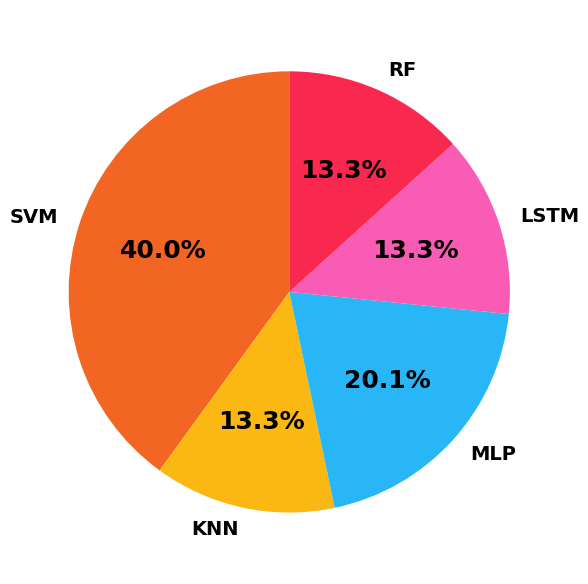

In [ ]:
import matplotlib.pyplot as plt

labels = ['SVM', 'KNN', 'MLP', 'LSTM', 'RF']
sizes = [40, 13.3, 20.1, 13.3, 13.3]
colors = ['#f26522', '#fbb813', '#29b6f6', '#f85cb4', '#f9284e']

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 18, 'weight': 'bold', 'color': 'black'}
)

# הדגשה לשמות המודלים
for text in texts:
    text.set_fontweight('bold')
    text.set_fontsize(14)

plt.axis('equal')  # שומר על עיגול מושלם
plt.tight_layout()  # מצמצם את הרווחים הלבנים
plt.show()

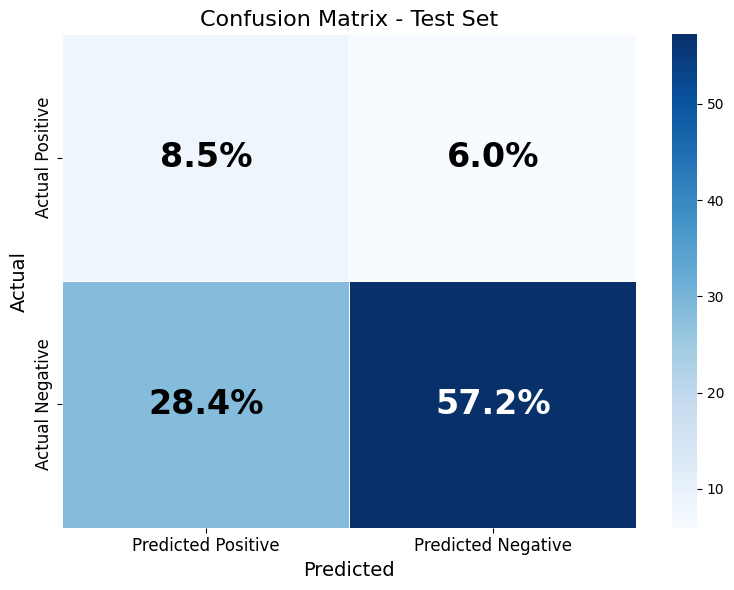

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# נתוני ה-confusion matrix
conf_matrix = np.array([[17, 12],
                        [57, 115]])

# חישוב אחוזים מתוך הסכום הכולל
conf_percent = conf_matrix / conf_matrix.sum() * 100

# יצירת heatmap
plt.figure(figsize=(8, 6))
ax = sns.heatmap(conf_percent, annot=True, fmt=".1f", cmap="Blues",
                 annot_kws={"size": 24, "weight": "bold"},
                 cbar=True, linewidths=0.5, linecolor='white')

# התאמה של צבע טקסט
for text in ax.texts:
    val = float(text.get_text())
    text.set_text(f"{val:.1f}%")
    text.set_color("white" if val > 50 else "black")

# תוויות צירים
ax.set_xticklabels(['Predicted Positive', 'Predicted Negative'], fontsize=12)
ax.set_yticklabels(['Actual Positive', 'Actual Negative'], fontsize=12)

ax.set_xlabel('Predicted', fontsize=14)
ax.set_ylabel('Actual', fontsize=14)
plt.title('Confusion Matrix - Test Set', fontsize=16)
plt.tight_layout()
plt.show()

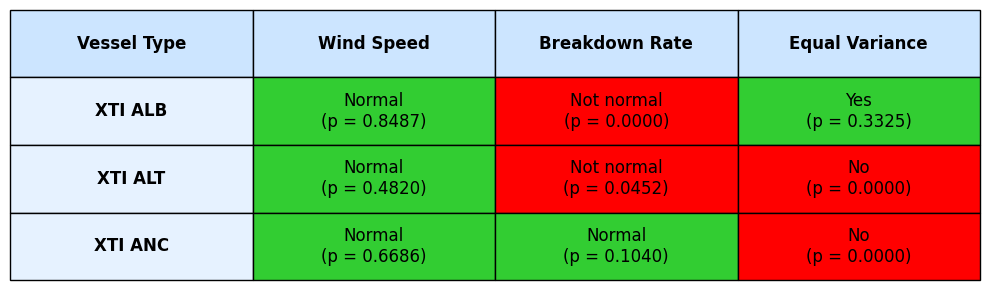

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.table import Table

# הגדרת הנתונים
vessels = ["XTI ALB", "XTI ALT", "XTI ANC"]
wind_speed = ["Normal\n(p = 0.8487)", "Normal\n(p = 0.4820)", "Normal\n(p = 0.6686)"]
breakdown_rate = ["Not normal\n(p = 0.0000)", "Not normal\n(p = 0.0452)", "Normal\n(p = 0.1040)"]
equal_variance = ["Yes\n(p = 0.3325)", "No\n(p = 0.0000)", "No\n(p = 0.0000)"]

# צבעים לתאים
wind_colors = ["limegreen", "limegreen", "limegreen"]
breakdown_colors = ["red", "red", "limegreen"]
variance_colors = ["limegreen", "red", "red"]

# יצירת הפלט
fig, ax = plt.subplots(figsize=(10, 3))
ax.set_axis_off()
tbl = Table(ax, bbox=[0, 0, 1, 1])

# מידות הטבלה
n_rows, n_cols = 4, 4
widths = [0.25, 0.25, 0.25, 0.25]
heights = [0.25] * n_rows

# כותרות
headers = ["Vessel Type", "Wind Speed", "Breakdown Rate", "Equal Variance"]
for col, header in enumerate(headers):
    cell = tbl.add_cell(0, col, widths[col], heights[0], text=header, loc='center', facecolor='#cce5ff')
    cell.get_text().set_weight('bold')
    cell.get_text().set_fontsize(14)

# הוספת נתונים לשורות
for i in range(len(vessels)):
    # Vessel Type
    cell = tbl.add_cell(i+1, 0, widths[0], heights[1], text=vessels[i], loc='center', facecolor='#e6f2ff')
    cell.get_text().set_weight('bold')
    cell.get_text().set_fontsize(13)

    # Wind Speed
    cell = tbl.add_cell(i+1, 1, widths[1], heights[1], text=wind_speed[i], loc='center', facecolor=wind_colors[i])
    cell.get_text().set_fontsize(13)

    # Breakdown Rate
    cell = tbl.add_cell(i+1, 2, widths[2], heights[1], text=breakdown_rate[i], loc='center', facecolor=breakdown_colors[i])
    cell.get_text().set_fontsize(13)

    # Equal Variance
    cell = tbl.add_cell(i+1, 3, widths[3], heights[1], text=equal_variance[i], loc='center', facecolor=variance_colors[i])
    cell.get_text().set_fontsize(13)

# הצגת הטבלה
ax.add_table(tbl)
plt.tight_layout()
plt.show()

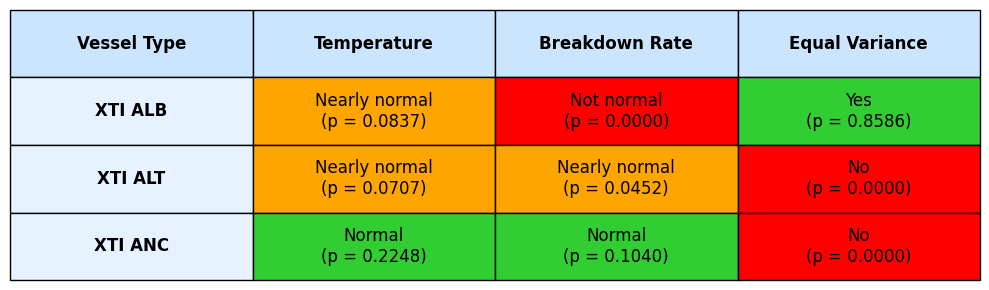

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.table import Table

# נתונים
vessels = ["XTI ALB", "XTI ALT", "XTI ANC"]
temperature = ["Nearly normal\n(p = 0.0837)", "Nearly normal\n(p = 0.0707)", "Normal\n(p = 0.2248)"]
breakdown = ["Not normal\n(p = 0.0000)", "Nearly normal\n(p = 0.0452)", "Normal\n(p = 0.1040)"]
variance = ["Yes\n(p = 0.8586)", "No\n(p = 0.0000)", "No\n(p = 0.0000)"]

temperature_colors = ["orange", "orange", "limegreen"]
breakdown_colors = ["red", "orange", "limegreen"]
variance_colors = ["limegreen", "red", "red"]

# ציור
fig, ax = plt.subplots(figsize=(10, 3))
ax.set_axis_off()
tbl = Table(ax, bbox=[0, 0, 1, 1])

# גודל תאים
n_rows, n_cols = 4, 4
widths = [0.25] * n_cols
heights = [0.25] * n_rows

# כותרות
headers = ["Vessel Type", "Temperature", "Breakdown Rate", "Equal Variance"]
for col, header in enumerate(headers):
    cell = tbl.add_cell(0, col, widths[col], heights[0], text=header, loc='center', facecolor='#cce5ff')
    cell.get_text().set_weight('bold')
    cell.get_text().set_fontsize(14)

# שורות מידע
for i in range(len(vessels)):
    cell = tbl.add_cell(i+1, 0, widths[0], heights[1], text=vessels[i], loc='center', facecolor='#e6f2ff')
    cell.get_text().set_weight('bold')
    cell.get_text().set_fontsize(13)

    cell = tbl.add_cell(i+1, 1, widths[1], heights[1], text=temperature[i], loc='center', facecolor=temperature_colors[i])
    cell.get_text().set_fontsize(13)

    cell = tbl.add_cell(i+1, 2, widths[2], heights[1], text=breakdown[i], loc='center', facecolor=breakdown_colors[i])
    cell.get_text().set_fontsize(13)

    cell = tbl.add_cell(i+1, 3, widths[3], heights[1], text=variance[i], loc='center', facecolor=variance_colors[i])
    cell.get_text().set_fontsize(13)

# הצגת הטבלה
ax.add_table(tbl)
plt.tight_layout()
plt.show()

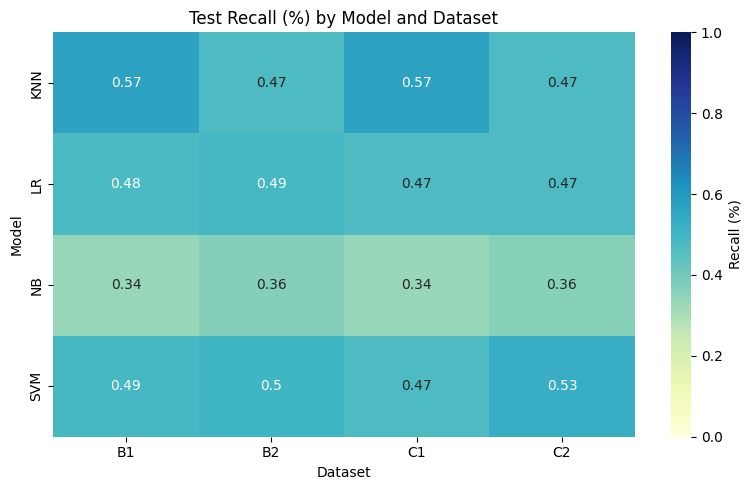

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# נתוני הריקול
data = {
    "Model": ["NB"] * 4 + ["LR"] * 4 + ["KNN"] * 4 + ["SVM"] * 4,
    "Dataset": ["B1", "B2", "C1", "C2"] * 4,
    "Test Recall": [
        0.335, 0.364, 0.335, 0.363,
        0.477, 0.490, 0.469, 0.473,
        0.568, 0.474, 0.568, 0.474,
        0.491, 0.502, 0.473, 0.530
    ]
}

# יצירת DataFrame
df = pd.DataFrame(data)

# המרה לטבלת pivot
pivot_df = df.pivot(index="Model", columns="Dataset", values="Test Recall")

# ציור heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_df, annot=True, cmap="YlGnBu", vmin=0, vmax=1, cbar_kws={'label': 'Recall (%)'})
plt.title("Test Recall (%) by Model and Dataset")
plt.ylabel("Model")
plt.xlabel("Dataset")
plt.tight_layout()
plt.show()
